# Question 1 : Impact Relatif des Facteurs sur le Bonheur

**Objectif :** Visualiser l'influence spécifique de l'économie, du soutien social, de la santé, de la liberté, de la générosité et de la corruption sur le score de bonheur (`Life Ladder`).

In [151]:
# Importations essentielles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Style graphique (optionnel)
sns.set_theme(style="whitegrid")

print("Bibliothèques importées.")

Bibliothèques importées.


In [152]:
# --- Chargement initial unique des données ---

# Chemin du fichier
file_path = 'CSVs/world_happiness_report_2024.csv' 
# Si vous avez téléversé le dossier WorldHappinessReport/, le chemin pourrait être :
# file_path = 'WorldHappinessReport/CSVs/world_happiness_report_2024.csv'

# Charger TOUTES les colonnes utiles pour les questions (ou toutes par simplicité)
try:
    df_whr_full = pd.read_csv(file_path)
    print(f"Données complètes chargées depuis {file_path}. Dimensions: {df_whr_full.shape}")
    
    # Afficher un aperçu et les infos (optionnel)
    # display(df_whr_full.head())
    # print("\nInfos sur le DataFrame complet:")
    # df_whr_full.info()

except FileNotFoundError:
    print(f"ERREUR : Le fichier {file_path} n'a pas été trouvé. Vérifiez le chemin.")
    # Arrêter potentiellement l'exécution si le fichier n'est pas trouvé
    df_whr_full = None 
except Exception as e:
    print(f"Une erreur est survenue lors du chargement: {e}")
    df_whr_full = None

Données complètes chargées depuis CSVs/world_happiness_report_2024.csv. Dimensions: (2363, 11)


Préparation pour Q1: 2103 observations utilisées après nettoyage des NaN.
Formule Q1 utilisée : Q("Life Ladder") ~ Q("Log GDP per capita") + Q("Social support") + Q("Healthy life expectancy at birth") + Q("Freedom to make life choices") + Q("Generosity") + Q("Perceptions of corruption")
Modèle de régression Q1 ajusté.
Génération du graphique des coefficients Q1...


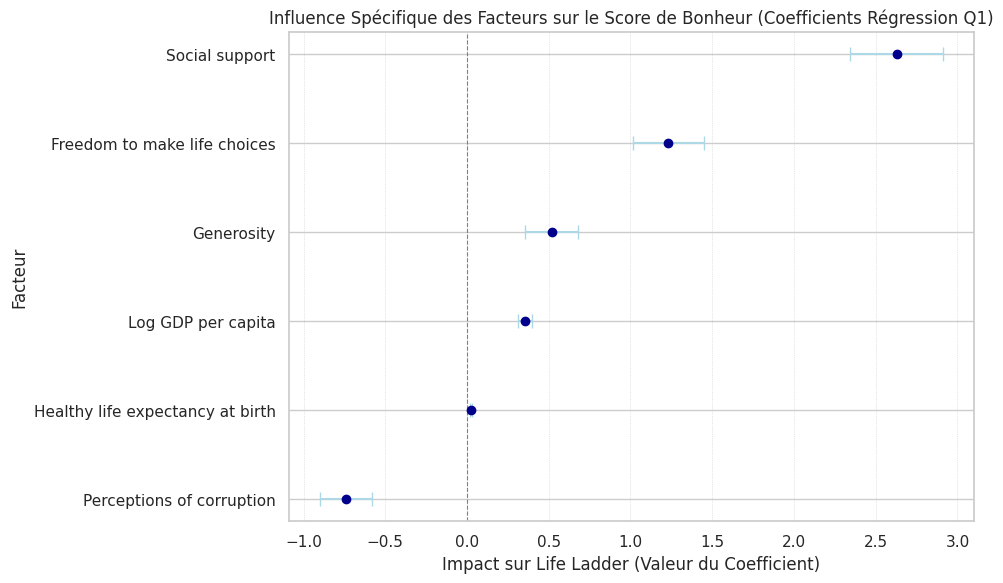

In [153]:
# --- Analyse et Graphique Principal Q1 (Coefficient Plot) ---

if df_whr_full is not None: # Vérifie si le chargement a réussi
    
    # Colonnes nécessaires SPÉCIFIQUEMENT pour la régression Q1
    colonnes_regression_q1 = [
        'Life Ladder',
        'Log GDP per capita',
        'Social support',
        'Healthy life expectancy at birth',
        'Freedom to make life choices',
        'Generosity',
        'Perceptions of corruption'
    ]

    # Préparation des données A LA VOLEE pour Q1: sélectionner + nettoyer NaN
    df_q1_analysis_data = df_whr_full[colonnes_regression_q1].dropna()
    print(f"Préparation pour Q1: {len(df_q1_analysis_data)} observations utilisées après nettoyage des NaN.")

    # Définir la formule de régression avec Q()
    predictor_cols_q = [f'Q("{col}")' for col in colonnes_regression_q1 if col != 'Life Ladder']
    formula_q1 = f'Q("Life Ladder") ~ {" + ".join(predictor_cols_q)}'
    print(f"Formule Q1 utilisée : {formula_q1}")

    try:
        # Ajuster le modèle OLS sur les données nettoyées pour Q1
        model_q1 = smf.ols(formula=formula_q1, data=df_q1_analysis_data)
        results_q1 = model_q1.fit()
        print("Modèle de régression Q1 ajusté.")

        # --- Création du Graphique des Coefficients (identique à avant) ---
        print("Génération du graphique des coefficients Q1...")
        coeffs = results_q1.params.drop('Intercept')
        conf_int = results_q1.conf_int().drop('Intercept')
        coeffs.index = [name.replace('Q("', '').replace('")', '') for name in coeffs.index]
        conf_int.index = [name.replace('Q("', '').replace('")', '') for name in conf_int.index]
        coeffs_sorted = coeffs.sort_values()
        conf_int_sorted = conf_int.loc[coeffs_sorted.index]
        
        plt.figure(figsize=(10, 6))
        err = (conf_int_sorted[1] - conf_int_sorted[0]) / 2
        plt.errorbar(coeffs_sorted, coeffs_sorted.index, xerr=err, fmt='o', color='darkblue', ecolor='lightblue', capsize=5, label='Coefficient (IC 95%)')
        plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
        plt.title('Influence Spécifique des Facteurs sur le Score de Bonheur (Coefficients Régression Q1)')
        plt.xlabel('Impact sur Life Ladder (Valeur du Coefficient)')
        plt.ylabel('Facteur')
        plt.grid(axis='x', linestyle=':', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Une erreur est survenue lors de l'analyse ou la visualisation Q1 : {e}")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q1 annulée.")

**Conclusion (Basée sur le graphique des coefficients)**

Le graphique ci-dessus illustre l'influence spécifique estimée de chaque facteur sur le score de bonheur (`Life Ladder`), une fois l'effet des autres facteurs pris en compte :

* **Signification :** Tous les facteurs sont statistiquement significatifs, car leurs intervalles de confiance (barres horizontales claires) ne coupent pas la ligne verticale à zéro.
* **Impacts Positifs (points à droite de zéro) :**
    * Le `Social support` (soutien social) se distingue nettement avec le coefficient positif le plus élevé (le point bleu le plus à droite, vers +2.6), indiquant l'impact positif le plus fort.
    * La `Freedom to make life choices` (liberté de choix) montre également un impact positif très important (vers +1.2).
    * Viennent ensuite, avec des impacts positifs notables mais moindres, la `Generosity` (générosité, vers +0.5) et le `Log GDP per capita` (PIB logarithmique, vers +0.35).
    * La `Healthy life expectancy at birth` (espérance de vie en bonne santé) a l'impact positif le plus faible parmi les facteurs significatifs (proche de zéro, vers +0.03).
* **Impact Négatif (point à gauche de zéro) :**
    * La `Perceptions of corruption` (perception de la corruption) est le seul facteur ayant un impact négatif significatif (vers -0.75). Une perception élevée de la corruption est donc associée à un score de bonheur plus bas.

En résumé, ce graphique met en évidence l'importance prépondérante du soutien social et de la liberté perçue pour expliquer le bonheur. L'économie, la générosité et la santé y contribuent aussi positivement mais à des degrés divers, tandis que la perception de la corruption agit clairement comme un frein au bien-être tel que mesuré par le `Life Ladder`.

# Question 2 : Pays "Hors Normes" Économiques

**Objectif :** Identifier les pays dont le score de bonheur (`Life Ladder`) est supérieur à ce que leur niveau de PIB par habitant (`Log GDP per capita`) laisserait présager.

In [154]:
# --- Préparation et Analyse des Résidus Q2 ---

if df_whr_full is not None: # Vérifie si le chargement initial a réussi
    
    # 1. Sélectionner les données les plus récentes par pays depuis df_whr_full
    df_latest = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    print(f"Préparation pour Q2: Données les plus récentes sélectionnées pour {len(df_latest)} pays.")

    # 2. Nettoyer les NaN SPÉCIFIQUEMENT pour les colonnes de Q2 (Life Ladder, Log GDP)
    colonnes_q2 = ['Life Ladder', 'Log GDP per capita', 'Country', 'year'] # Inclure Country/Year pour les labels
    df_q2_analysis_data = df_latest[colonnes_q2].dropna(subset=['Life Ladder', 'Log GDP per capita'])
    print(f"Préparation pour Q2: {len(df_q2_analysis_data)} observations utilisées après nettoyage des NaN pour LL et GDP.")

    # 3. Régression simple : Bonheur ~ PIB sur les données nettoyées de Q2
    formula_q2 = 'Q("Life Ladder") ~ Q("Log GDP per capita")'
    model_q2 = smf.ols(formula=formula_q2, data=df_q2_analysis_data)
    results_q2 = model_q2.fit()
    print("Régression simple Q2 (Bonheur ~ PIB) ajustée.")

    # 4. Calculer les résidus sur les données nettoyées de Q2
    df_q2_analysis_data['Predicted Happiness (GDP)'] = results_q2.predict(df_q2_analysis_data)
    df_q2_analysis_data['Residual (Happiness vs GDP)'] = df_q2_analysis_data['Life Ladder'] - df_q2_analysis_data['Predicted Happiness (GDP)']

    # 5. Identifier les N pays les plus "surperformants"
    N = 15 
    top_overperformers = df_q2_analysis_data.nlargest(N, 'Residual (Happiness vs GDP)')
    
    print(f"\nTop {N} pays avec un bonheur supérieur aux prédictions basées sur le PIB (Q2):")
    
    # ---- LIGNE CORRIGEE ----
    # Appliquer le format uniquement aux colonnes numériques spécifiées dans 'subset'
    display(top_overperformers[['Country','Life Ladder', 'Log GDP per capita', 'Residual (Happiness vs GDP)']]
            .style.format("{:.2f}", subset=['Life Ladder', 'Log GDP per capita', 'Residual (Happiness vs GDP)']))
    # -------------------------

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q2 annulée.")

Préparation pour Q2: Données les plus récentes sélectionnées pour 165 pays.
Préparation pour Q2: 153 observations utilisées après nettoyage des NaN pour LL et GDP.
Régression simple Q2 (Bonheur ~ PIB) ajustée.

Top 15 pays avec un bonheur supérieur aux prédictions basées sur le PIB (Q2):


,Country,Life Ladder,Log GDP per capita,Residual (Happiness vs GDP)
1442,Mozambique,5.70,7.15,1.89
490,Costa Rica,7.38,10.02,1.42
1533,Nicaragua,6.36,8.69,1.40
1116,Kosovo,6.88,9.48,1.32
2277,Uzbekistan,6.38,9.03,1.16
632,El Salvador,6.48,9.17,1.15
680,Finland,7.70,10.81,1.14
1369,Mexico,7.01,9.90,1.13
803,Guatemala,6.42,9.14,1.11
1147,Kyrgyzstan,5.91,8.57,1.03


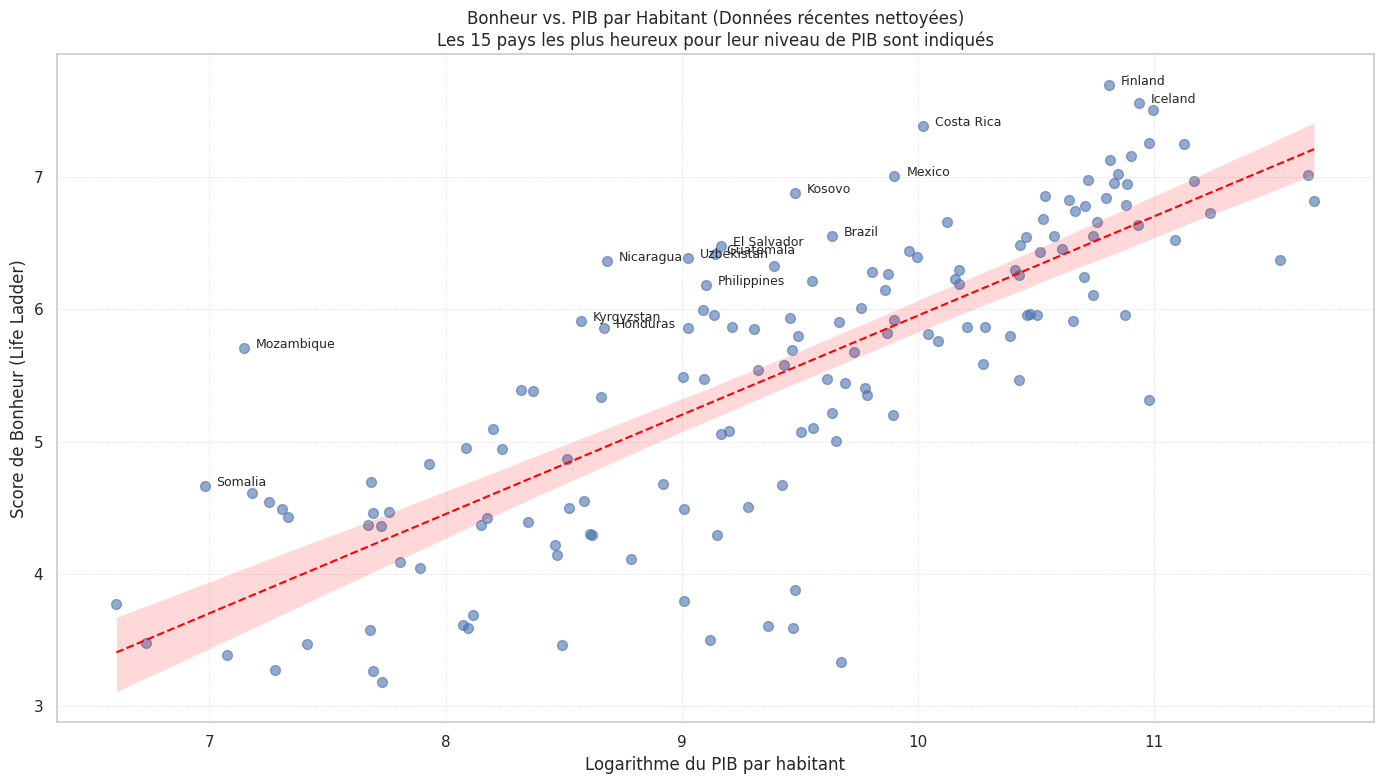

In [155]:
# --- Visualisation Q2 : Scatter Plot avec Outliers ---

# Vérifier si les dataframes nécessaires existent (générés dans la cellule précédente)
q2_data_exists = 'df_q2_analysis_data' in locals() and 'top_overperformers' in locals()

if df_whr_full is not None and q2_data_exists:
    
    plt.figure(figsize=(14, 8))
    
    # Nuage de points + droite de régression en utilisant les données Q2 nettoyées
    ax = sns.regplot(x='Log GDP per capita', y='Life Ladder', data=df_q2_analysis_data,
                     scatter_kws={'alpha': 0.6, 's': 50}, 
                     line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 1.5}) 

    # Ajouter les labels pour les N pays surperformants (depuis top_overperformers)
    # Assurez-vous que top_overperformers contient les colonnes x, y, et Country
    for i, country_data in top_overperformers.iterrows():
        plt.text(country_data['Log GDP per capita'] + 0.05, 
                 country_data['Life Ladder'], 
                 country_data['Country'], 
                 fontsize=9)

    plt.title(f'Bonheur vs. PIB par Habitant (Données récentes nettoyées)\nLes {N} pays les plus heureux pour leur niveau de PIB sont indiqués')
    plt.xlabel('Logarithme du PIB par habitant')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()

elif df_whr_full is None:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Visualisation Q2 annulée.")
else:
    print("Les données nécessaires ('df_q2_analysis_data', 'top_overperformers') n'ont pas été créées. Visualisation Q2 annulée.")

**Conclusion (Basée sur le graphique et les résidus Q2)**

Le graphique ci-dessus visualise le score de bonheur (`Life Ladder`) en fonction de la richesse économique (`Log GDP per capita`) pour les données les plus récentes. La ligne rouge pointillée représente la tendance générale : plus un pays est riche, plus son score de bonheur tend à être élevé.

Cependant, de nombreux pays s'écartent de cette tendance. Ceux situés nettement **au-dessus** de la ligne rouge sont les "surperformants" : ils affichent un niveau de bonheur plus élevé que ce que leur PIB seul ne laisserait supposer. Les 15 pays avec le plus grand écart positif sont nommés sur le graphique et listés dans le tableau précédent.

Parmi ces pays qui "surpassent" leur performance économique en termes de bonheur, on note :

* **Une forte présence latino-américaine :** Le **Costa Rica** est très nettement au-dessus de la ligne, suivi par le **Nicaragua**, **El Salvador**, le **Mexique**, le **Guatemala**, le **Honduras** et le **Brésil**.
* **Des cas surprenants à faible revenu :** Le **Mozambique** et la **Somalie** affichent un bonheur remarquablement plus élevé que prédit par leur très faible PIB.
* **Des pays d'Europe et d'Asie Centrale :** Le **Kosovo**, l'**Ouzbékistan** et le **Kirghizstan** se distinguent également. Les **Philippines** sont aussi dans ce groupe.
* **Des pays nordiques déjà riches :** La **Finlande** et l'**Islande**, bien que déjà très riches, parviennent à être *encore plus* heureuses que ce que leur niveau de PIB élevé prédirait.

Ces résultats suggèrent fortement que si la richesse contribue au bonheur, elle n'en est pas le seul déterminant. Des facteurs comme la qualité des liens sociaux, la liberté individuelle, la confiance, la générosité (analysés dans la Question 1) jouent un rôle crucial et permettent à certains pays, notamment en Amérique Latine mais aussi ailleurs, d'atteindre un bien-être subjectif élevé malgré un niveau de richesse parfois modeste ou moyen. Pour les pays déjà riches comme la Finlande ou l'Islande, cela indique une efficacité particulière à convertir la richesse en bien-être subjectif grâce à ces autres facteurs.

# Question 3 : Disparités Régionales du Bonheur

**Objectif :** Examiner comment le score de bonheur (`Life Ladder`) et ses composantes principales (PIB, soutien social, santé, liberté, générosité, corruption) varient en moyenne d'une région géographique à l'autre.

In [156]:
# --- Préparation des Données Régionales ---

if df_whr_full is not None: # Vérifie si le chargement initial (Cellule 3) a réussi
    
    # 1. Charger les données de régions depuis le fichier CPI
    cpi_file_path = 'CSVs/CPI2023_global_results_trends.csv'
    # Si dossier WorldHappinessReport/ : 'WorldHappinessReport/CSVs/CPI2023_global_results_trends.csv'
    try:
        df_regions = pd.read_csv(cpi_file_path, usecols=['Country', 'Region'])
        print(f"Données régionales chargées depuis {cpi_file_path}. {len(df_regions)} pays trouvés.")
        # Nettoyer les noms de région si nécessaire (optionnel)
        # df_regions['Region'] = df_regions['Region'].str.strip() 
    except FileNotFoundError:
        print(f"ERREUR: Le fichier CPI {cpi_file_path} est introuvable.")
        df_regions = None
    except Exception as e:
        print(f"Erreur lors du chargement des régions: {e}")
        df_regions = None

    if df_regions is not None:
        # 2. Sélectionner les données les plus récentes par pays depuis df_whr_full
        df_latest = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
        print(f"Données les plus récentes sélectionnées pour {len(df_latest)} pays du WHR.")

        # 3. Fusionner les données récentes du WHR avec les informations de région
        #    ATTENTION: La fusion sur 'Country' peut échouer si les noms ne correspondent pas exactement.
        df_merged_regions = pd.merge(df_latest, df_regions, on='Country', how='left')
        
        # Vérifier combien de pays n'ont pas eu de correspondance de région
        unmatched_countries = df_merged_regions[df_merged_regions['Region'].isnull()]['Country'].nunique()
        if unmatched_countries > 0:
            print(f"Attention: {unmatched_countries} pays n'ont pas pu être associés à une région (vérifiez les noms de pays).")
        
        # Retirer les pays sans région pour l'analyse régionale
        df_regional_data = df_merged_regions.dropna(subset=['Region'])
        print(f"{len(df_regional_data)} observations avec informations régionales disponibles pour l'analyse.")

        # 4. Calculer les scores moyens par région pour les variables clés
        colonnes_analyse_q3 = [
            'Life Ladder', 'Log GDP per capita', 'Social support', 
            'Healthy life expectancy at birth', 'Freedom to make life choices', 
            'Generosity', 'Perceptions of corruption'
        ]
        # Calculer la moyenne pour chaque colonne numérique pertinente, groupée par Région
        # Note: .mean(numeric_only=True) gère automatiquement les colonnes non numériques
        regional_means = df_regional_data.groupby('Region')[colonnes_analyse_q3].mean().reset_index()

        print("\nScores moyens par région :")
        # Afficher le tableau des moyennes régionales
        display(regional_means.round(2)) # Arrondir pour une meilleure lisibilité
        
    else:
        print("Analyse régionale annulée car les données régionales n'ont pas pu être chargées.")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q3 annulée.")

Données régionales chargées depuis CSVs/CPI2023_global_results_trends.csv. 180 pays trouvés.
Données les plus récentes sélectionnées pour 165 pays du WHR.
Attention: 10 pays n'ont pas pu être associés à une région (vérifiez les noms de pays).
155 observations avec informations régionales disponibles pour l'analyse.

Scores moyens par région :


,Region,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,AME,6.16,9.63,0.84,66.00,0.81,-0.02,0.77
1,AP,5.31,9.42,0.76,65.14,0.82,0.13,0.70
2,ECA,5.77,9.59,0.86,66.09,0.83,0.05,0.76
3,MENA,5.36,9.97,0.75,65.28,0.69,0.01,0.75
4,SSA,4.26,8.06,0.65,56.54,0.70,0.03,0.75
5,WE/EU,6.63,10.76,0.90,70.72,0.83,0.02,0.61



Visualisation des scores moyens par région...


/tmp/ipykernel_18549/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
/tmp/ipykernel_18549/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
/tmp/ipykernel_18549/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='

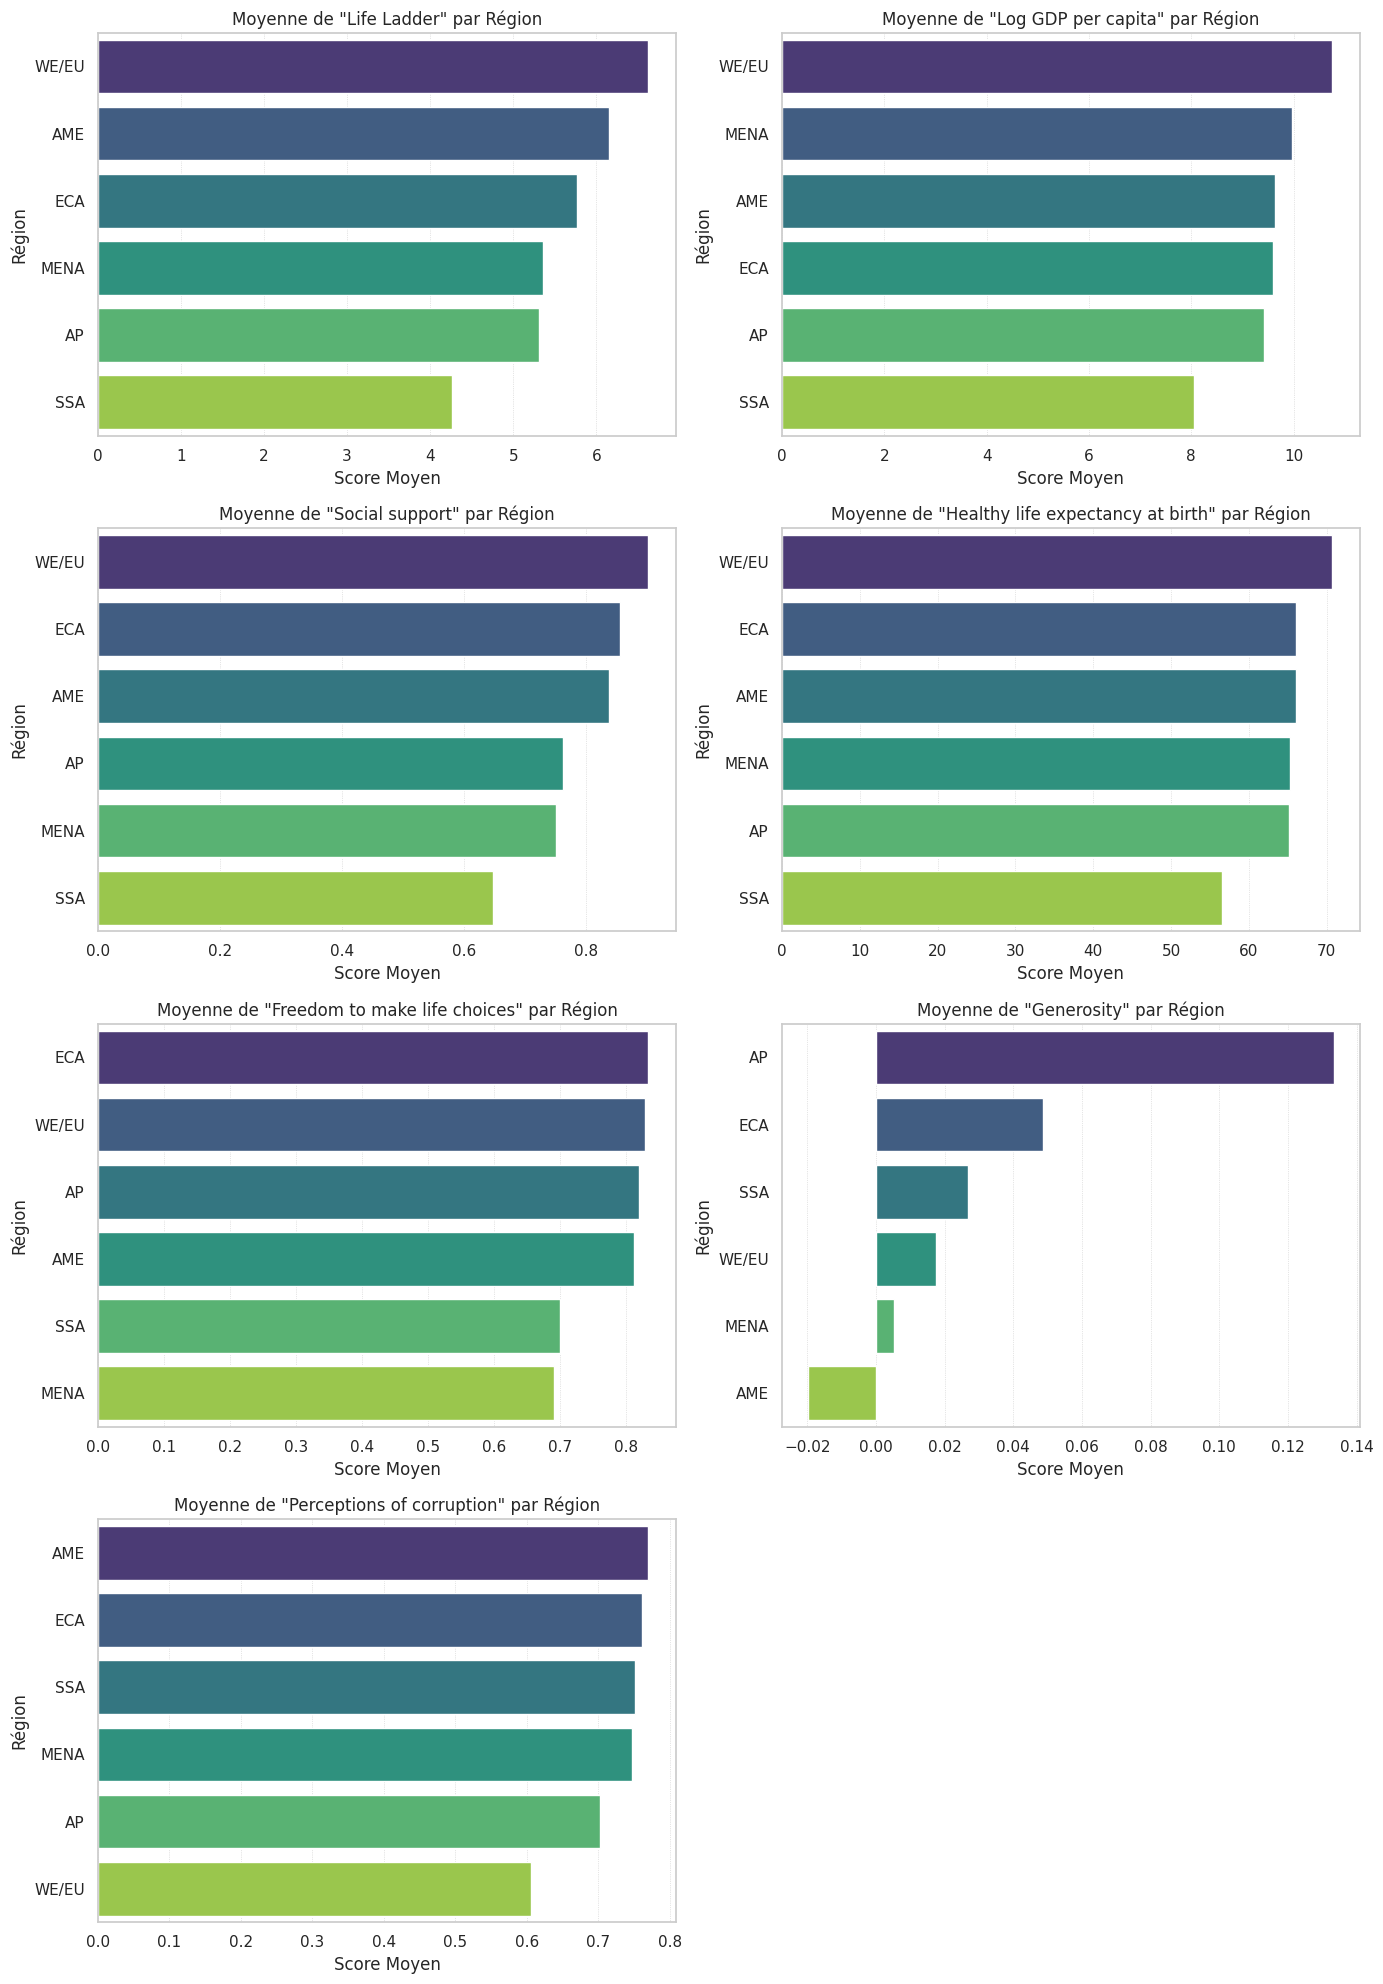

In [157]:
# --- Visualisation des Moyennes Régionales ---

# Vérifier si les données régionales existent
q3_data_exists = 'regional_means' in locals()

if q3_data_exists and not regional_means.empty:
    
    print("\nVisualisation des scores moyens par région...")
    
    # Liste des colonnes à visualiser
    variables_to_plot = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption'
    ]
    
    # Nombre de lignes/colonnes pour la grille de graphiques
    n_cols = 2
    n_rows = (len(variables_to_plot) + n_cols - 1) // n_cols

    plt.figure(figsize=(14, n_rows * 5)) # Ajuster la taille globale

    for i, var in enumerate(variables_to_plot):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Trier les régions par la variable actuelle pour une meilleure lisibilité du graphique
        data_sorted = regional_means.sort_values(var, ascending=False)
        
        # Créer le barplot
        sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
        
        plt.title(f'Moyenne de "{var}" par Région')
        plt.xlabel('Score Moyen')
        plt.ylabel('Région') # L'axe Y contient maintenant les noms des régions
        plt.grid(axis='x', linestyle=':', linewidth=0.5)

    plt.tight_layout() # Ajuster l'espacement
    plt.show()

elif not q3_data_exists:
     print("Les données 'regional_means' n'ont pas été créées. Visualisation Q3 annulée.")
else:
     print("Le DataFrame 'regional_means' est vide. Vérifiez les étapes précédentes (chargement, fusion).")

**Conclusion (Basée sur les graphiques des moyennes régionales)**

Les graphiques à barres produits ci-dessus révèlent des disparités régionales nettes concernant le bonheur et ses composantes principales :

1.  **Bonheur (`Life Ladder`) :** La région **WE/EU** (Europe de l'Ouest / UE) affiche le score de bonheur moyen le plus élevé, suivie par **AME** (Amériques). À l'opposé, **SSA** (Afrique Subsaharienne) présente la moyenne la plus faible. Les régions **ECA** (Europe de l'Est / Asie Centrale), **MENA** (Moyen-Orient / Afrique du Nord) et **AP** (Asie-Pacifique) se situent à des niveaux intermédiaires.

2.  **Facteurs Clés :**
    * **Richesse et Santé (`Log GDP per capita`, `Healthy life expectancy`) :** Le classement du bonheur suit globalement celui de la richesse et de l'espérance de vie en bonne santé. **WE/EU** domine largement sur ces deux plans, tandis que **SSA** est nettement en retrait.
    * **Soutien Social (`Social support`) :** **WE/EU** est en tête, mais **ECA** et **AME** montrent aussi des niveaux élevés, indiquant une forte perception de soutien social dans ces régions également. **SSA** a le score le plus bas.
    * **Liberté (`Freedom to make life choices`) :** **WE/EU** rapporte la plus grande liberté de choix en moyenne, suivie de près par **ECA**, **AME**, et **AP**. Les régions **SSA** et surtout **MENA** affichent les scores moyens les plus faibles sur ce critère.
    * **Générosité (`Generosity`) :** Le classement est différent ici. **AP** semble être la région la plus généreuse en moyenne, suivie par **ECA** et **SSA**. Les régions **WE/EU**, **MENA** et **AME** montrent des niveaux moyens plus bas, voire légèrement négatifs pour ces dernières.
    * **Corruption (`Perceptions of corruption`) :** **WE/EU** se distingue par la perception de corruption la plus faible (score le plus bas). À l'inverse, **AME** et **ECA** affichent les perceptions de corruption les plus élevées en moyenne (scores les plus hauts). **AP** se situe remarquablement bien (deuxième score le plus bas après WE/EU).

**Synthèse :** Les différences de bonheur moyen entre les régions s'expliquent en grande partie par les écarts de richesse, de santé, de soutien social et de liberté. La région WE/EU excelle sur la plupart de ces indicateurs ainsi que sur la faible corruption perçue. Les Amériques (AME) affichent un bonheur élevé malgré une perception de corruption très forte, suggérant que d'autres facteurs (bon soutien social, liberté, etc.) compensent. L'Asie-Pacifique (AP) se distingue par une forte générosité et une faible perception de corruption relative à son niveau de bonheur/richesse. L'Afrique Subsaharienne (SSA) est confrontée aux défis les plus importants sur la plupart des indicateurs, à l'exception notable d'une générosité moyenne relativement élevée. Ces profils régionaux variés soulignent l'interaction complexe des différents facteurs dans la détermination du bien-être subjectif à travers le monde.

# Question 4 : Liberté et Bien-être selon le Contexte

**Objectif :** Analyser dans quelle mesure la perception de la liberté individuelle (`Freedom to make life choices`) influe sur le bonheur (`Life Ladder`), et si cette influence varie en fonction du contexte régional et du niveau de libertés civiles (contexte politique).

Utilisation des données régionales préparées pour Q3.
Visualisation de la relation Bonheur ~ Perception Liberté par Région...


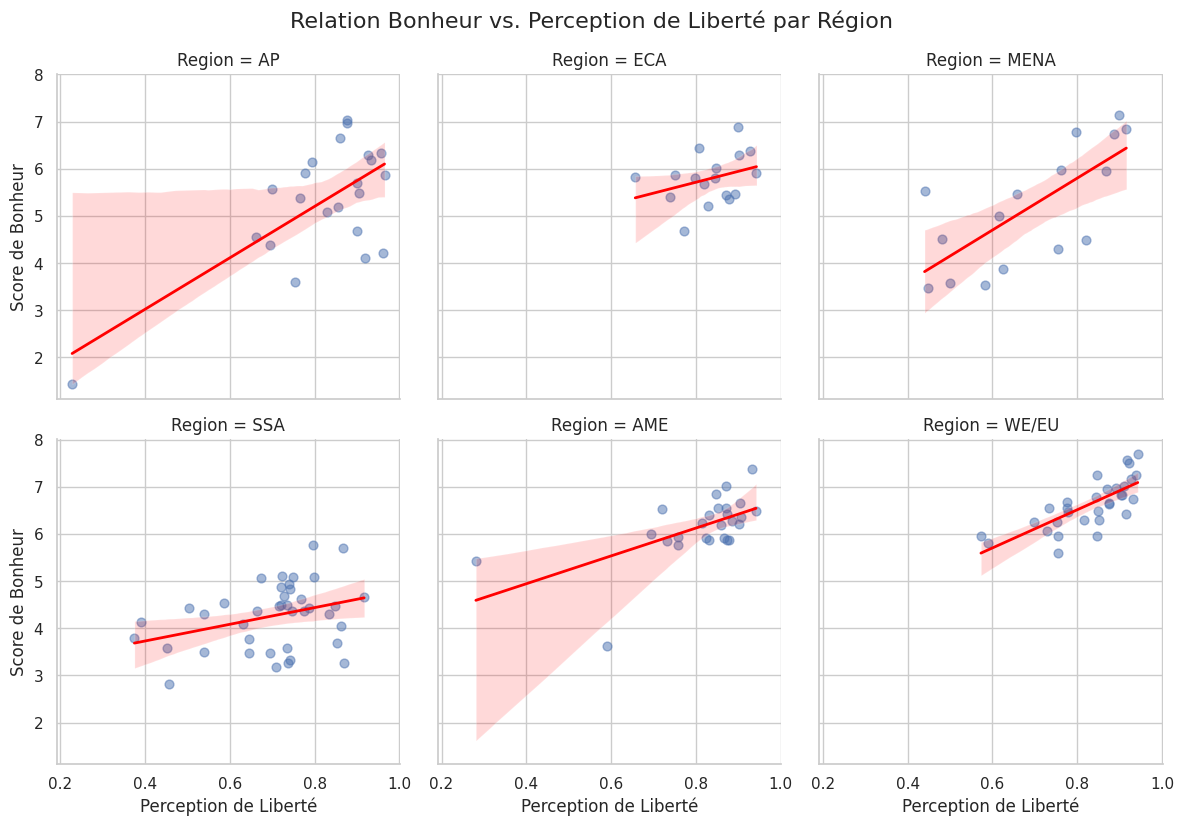

In [158]:
# --- Analyse : Liberté vs Bonheur par Région ---

# Vérifier si les données régionales de Q3 existent
q3_data_exists = 'df_regional_data' in locals() and not df_regional_data.empty

if q3_data_exists:
    print("Utilisation des données régionales préparées pour Q3.")
    print("Visualisation de la relation Bonheur ~ Perception Liberté par Région...")

    # Utiliser lmplot pour créer un graphique par région (faceting)
    # lmplot crée la figure elle-même
    g = sns.lmplot(
        data=df_regional_data, 
        x='Freedom to make life choices', 
        y='Life Ladder', 
        col='Region',        # Une colonne de graphiques par région
        col_wrap=3,          # Nombre de graphiques par ligne
        height=4,            # Hauteur de chaque graphique
        scatter_kws={'alpha': 0.5, 's': 40},
        line_kws={'color': 'red', 'linewidth': 2}
    )

    g.fig.suptitle('Relation Bonheur vs. Perception de Liberté par Région', y=1.03, fontsize=16)
    g.set_axis_labels('Perception de Liberté', 'Score de Bonheur')
    plt.show()

else:
     print("Les données régionales ('df_regional_data') n'ont pas été créées ou sont vides.")
     print("Assurez-vous d'avoir exécuté la Cellule 11 (Q3) avec succès.")

**Interprétation (Contexte Régional)**

Les graphiques ci-dessus montrent la relation entre la perception de liberté (`Freedom to make life choices`) et le bonheur (`Life Ladder`) pour chaque région séparément.

* **Tendance Générale :** Comme attendu, dans **toutes** les régions (AP, ECA, MENA, SSA, AME, WE/EU), on observe une **tendance positive** claire : plus les individus perçoivent avoir de liberté dans leurs choix de vie, plus leur score de bonheur tend à être élevé (la ligne de régression rouge monte de gauche à droite).

* **Variations Régionales de l'Impact (Pente) :** En comparant la pente (l'inclinaison) de la ligne rouge entre les régions :
    * Les régions **WE/EU** (Europe de l'Ouest / UE) et **AME** (Amériques) semblent présenter les **pentes les plus fortes**. Cela suggère que l'augmentation de la perception de liberté est associée à un gain de bonheur particulièrement important dans ces contextes.
    * Les régions **AP** (Asie-Pacifique) et **ECA** (Europe de l'Est / Asie Centrale) montrent des pentes positives claires, mais visuellement peut-être **un peu moins prononcées** que pour WE/EU et AME.
    * Les régions **MENA** (Moyen-Orient / Afrique du Nord) et **SSA** (Afrique Subsaharienne) semblent avoir les **pentes les plus faibles**. Bien que toujours positive, la relation y apparaît moins forte; une augmentation de la perception de liberté correspondrait à un gain de bonheur plus modeste en moyenne.

* **Positionnement Général :** On note aussi que les nuages de points se situent différemment : WE/EU est globalement en haut à droite (liberté perçue et bonheur élevés), tandis que SSA et MENA sont plutôt en bas à gauche (liberté perçue et bonheur plus faibles en moyenne).

En conclusion, si la perception de liberté est bénéfique pour le bonheur dans toutes les régions étudiées, l'**ampleur** de ce bénéfice semble varier. Elle apparaît maximale dans les régions WE/EU et Amériques, et plus modérée en Afrique Subsaharienne et au Moyen-Orient/Afrique du Nord, suggérant une interaction entre la perception de liberté et d'autres caractéristiques régionales (culturelles, institutionnelles, etc.).

Données Freedom House chargées. 3971 observations.
Fusion WHR et FH réussie. 2260 observations communes.
Données les plus récentes après fusion FH: 157 pays.
154 observations utilisables pour l'analyse Q4 (FH).

Catégories de Libertés Civiles (basées sur les terciles) :
FH_Category
Faible    54
Élevé     51
Moyen     49
Name: count, dtype: int64

Visualisation de la relation Bonheur ~ Perception Liberté par Niveau de Libertés Civiles...


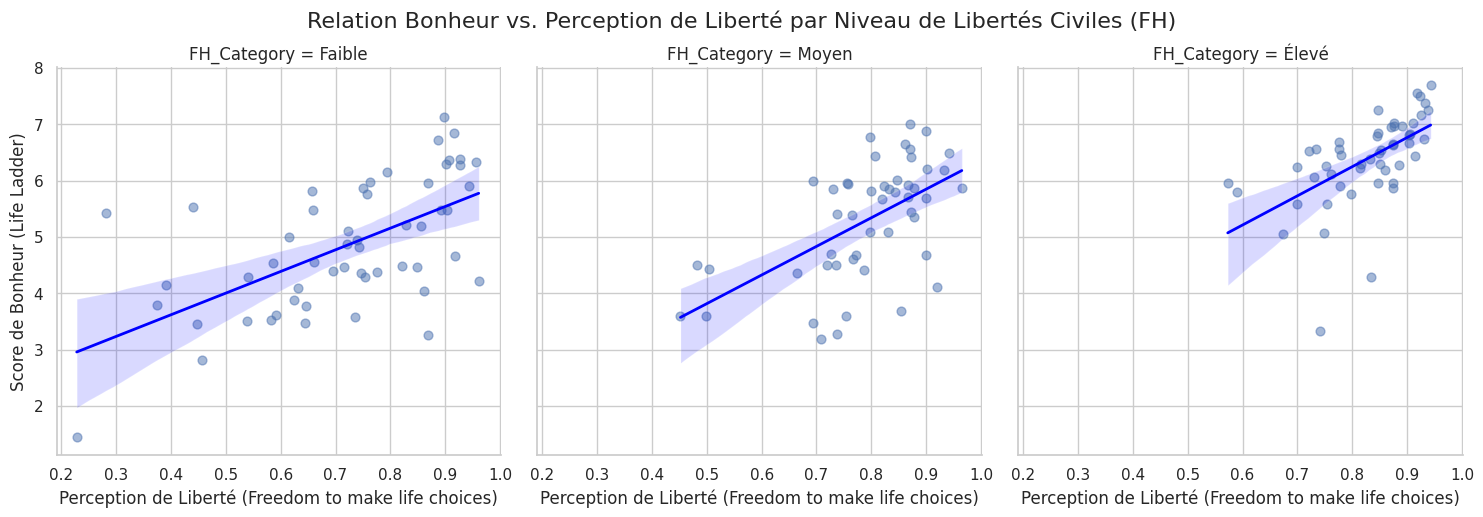

In [159]:
# --- Analyse : Liberté vs Bonheur par Niveau de Libertés Civiles (Freedom House) ---

if df_whr_full is not None: # Vérifier si les données WHR initiales existent
    
    # 1. Charger les données Freedom House (Libertés Civiles)
    fh_file_path = 'CSVs/civil_liberties_score_fh_new.csv'
    # Si dossier : 'WorldHappinessReport/CSVs/civil_liberties_score_fh_new.csv'
    try:
        df_fh = pd.read_csv(fh_file_path, usecols=['Country', 'Year', 'Civil liberties score'])
        # Renommer pour clarté et éviter conflit avec 'year' minuscule
        df_fh = df_fh.rename(columns={'Year': 'year', 'Civil liberties score': 'FH_CivilLiberties'}) 
        print(f"Données Freedom House chargées. {len(df_fh)} observations.")
    except FileNotFoundError:
        print(f"ERREUR: Le fichier Freedom House {fh_file_path} est introuvable.")
        df_fh = None
    except Exception as e:
        print(f"Erreur lors du chargement de Freedom House: {e}")
        df_fh = None

    if df_fh is not None:
        # 2. Fusionner les données WHR avec les scores FH sur Pays ET Année
        df_merged_fh = pd.merge(df_whr_full, df_fh, on=['Country', 'year'], how='inner') # 'inner' garde seulement les lignes correspondantes
        print(f"Fusion WHR et FH réussie. {len(df_merged_fh)} observations communes.")

        # 3. Prendre les données les plus récentes disponibles APRÈS fusion
        df_latest_fh = df_merged_fh.loc[df_merged_fh.groupby('Country')['year'].idxmax()]
        print(f"Données les plus récentes après fusion FH: {len(df_latest_fh)} pays.")
        
        # Retirer les NaN potentiels sur les colonnes clés pour ce graphique
        cols_q4_fh = ['Life Ladder', 'Freedom to make life choices', 'FH_CivilLiberties']
        df_q4_analysis_fh = df_latest_fh[cols_q4_fh + ['Country']].dropna(subset=cols_q4_fh)
        print(f"{len(df_q4_analysis_fh)} observations utilisables pour l'analyse Q4 (FH).")

        if not df_q4_analysis_fh.empty:
            # 4. Créer des catégories de Libertés Civiles (basées sur les terciles du score FH)
            #    Note: L'échelle FH pour Civil Liberties va de 0 à 60 (plus = mieux).
            #    On utilise les quantiles pour diviser en 3 groupes équilibrés en nombre d'observations.
            try:
                df_q4_analysis_fh['FH_Category'] = pd.qcut(df_q4_analysis_fh['FH_CivilLiberties'], q=3, labels=['Faible', 'Moyen', 'Élevé'])
                print("\nCatégories de Libertés Civiles (basées sur les terciles) :")
                print(df_q4_analysis_fh['FH_Category'].value_counts())
            except ValueError as ve:
                 print(f"Impossible de créer 3 catégories (peut-être pas assez de valeurs uniques): {ve}")
                 # Alternative: utiliser 2 catégories si q=3 échoue
                 try:
                     df_q4_analysis_fh['FH_Category'] = pd.qcut(df_q4_analysis_fh['FH_CivilLiberties'], q=2, labels=['Faible/Moyen', 'Élevé'])
                     print("\nCréation de 2 catégories de Libertés Civiles.")
                     print(df_q4_analysis_fh['FH_Category'].value_counts())
                 except Exception as e2:
                     print(f"Impossible de créer des catégories de Libertés Civiles: {e2}")
                     df_q4_analysis_fh = None # Ne pas continuer si la catégorie échoue

            # 5. Visualisation : Bonheur ~ Perception Liberté par Catégorie FH
            if df_q4_analysis_fh is not None and 'FH_Category' in df_q4_analysis_fh.columns:
                 print("\nVisualisation de la relation Bonheur ~ Perception Liberté par Niveau de Libertés Civiles...")
                 g_fh = sns.lmplot(
                     data=df_q4_analysis_fh, 
                     x='Freedom to make life choices', 
                     y='Life Ladder', 
                     col='FH_Category', # Une colonne par catégorie FH
                     height=5,
                     scatter_kws={'alpha': 0.5, 's': 40},
                     line_kws={'color': 'blue', 'linewidth': 2}
                 )
                 g_fh.fig.suptitle('Relation Bonheur vs. Perception de Liberté par Niveau de Libertés Civiles (FH)', y=1.03, fontsize=16)
                 g_fh.set_axis_labels('Perception de Liberté (Freedom to make life choices)', 'Score de Bonheur (Life Ladder)')
                 plt.show()
            else:
                print("Impossible de générer le graphique par catégorie FH.")
        else:
            print("Aucune donnée analysable après nettoyage pour l'analyse Q4 (FH).")
    else:
        print("Analyse par contexte politique annulée car les données Freedom House n'ont pas pu être chargées/fusionnées.")

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q4 annulée.")

**Interprétation (Contexte Politique - Libertés Civiles)**

Les trois graphiques ci-dessus montrent la relation entre la perception de liberté et le bonheur, en séparant les pays selon leur niveau de libertés civiles objectives (score Freedom House, catégorisé ici en 'Faible', 'Moyen', 'Élevé').

* **Tendance Générale :** Comme pour l'analyse régionale, on observe une **tendance positive dans les trois catégories**. Plus la perception de liberté est élevée, plus le score de bonheur tend à l'être, et ce, que le pays ait un niveau faible, moyen ou élevé de libertés civiles objectives. Le niveau général de bonheur et de perception de liberté augmente aussi logiquement avec la catégorie (le groupe 'Élevé' est en haut à droite, le groupe 'Faible' en bas à gauche).
* **Variations selon le Contexte Politique (Pente) :** En comparant l'inclinaison des lignes de régression bleues, les **pentes semblent visuellement assez similaires** dans les trois graphiques. Il n'y a pas de différence drastique apparente suggérant que l'impact marginal de la *perception* de liberté sur le bonheur dépende fortement du niveau *objectif* des libertés civiles (dans les conditions observées ici). La relation positive semble donc relativement constante à travers ces différents contextes politiques.

**Conclusion Générale (Question 4)**

L'analyse de la relation entre la perception de liberté et le bonheur, en tenant compte de différents contextes, nous amène aux conclusions suivantes :

1.  **Importance Universelle :** La perception de pouvoir faire ses propres choix de vie (`Freedom to make life choices`) est **positivement et significativement liée au bonheur** (`Life Ladder`) dans pratiquement tous les contextes examinés, qu'ils soient définis par la **région géographique** ou par le **niveau objectif de libertés civiles**.
2.  **Modulation par le Contexte Régional :** L'**ampleur** de cette relation (la force du lien) semble varier de manière notable selon les **régions**. Comme vu précédemment (Cellule 16), l'impact de la perception de liberté sur le bonheur apparaît **plus prononcé** dans des régions comme **WE/EU** et les **Amériques (AME)**, et **plus modéré** en **Afrique Subsaharienne (SSA)** ou au **Moyen-Orient/Afrique du Nord (MENA)**.
3.  **Stabilité Relative face au Contexte Politique Objectif :** En revanche, lorsque l'on compare les pays selon leur niveau de libertés civiles objectives (score Freedom House), la **pente** de la relation entre perception de liberté et bonheur **ne semble pas varier de manière drastique**. La perception de liberté conserve un impact positif similaire, que les libertés objectives soient faibles, moyennes ou élevées.

En conclusion, la **perception subjective de liberté est un facteur clé du bien-être partout**, mais son **poids relatif** par rapport à d'autres facteurs pourrait être davantage influencé par des **dynamiques régionales larges** (incluant potentiellement des aspects culturels, historiques, ou d'autres institutions non mesurées ici) que par le seul niveau mesuré des libertés civiles objectives. Autrement dit, ressentir de la liberté compte toujours, mais l'effet "levier" de ce ressenti sur le bonheur global varie plus entre les grandes régions du monde qu'entre les pays classés selon leur score de libertés civiles.

# Question 5 : Confiance Gouvernementale et Corruption

**Objectif :** Évaluer l'impact de la perception de la corruption (via les données WHR) et du niveau de corruption mesuré par Transparency International (CPI 2023) sur le score de bonheur (`Life Ladder`).

In [160]:
# --- Préparation des Données pour l'Analyse de la Corruption ---

if df_whr_full is not None: # Vérifier si le chargement initial a réussi
    
    # 1. Sélectionner les données WHR pertinentes pour l'année la plus récente (idéalement 2023)
    #    Filtrons d'abord pour 2023, car le CPI est de 2023.
    df_whr_2023 = df_whr_full[df_whr_full['year'] == 2023].copy()
    # Si peu de données pour 2023, on pourrait prendre la dernière année disponible:
    # df_latest_q5 = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    # Mais restons sur 2023 pour correspondre au CPI.
    
    cols_whr_q5 = ['Country', 'Life Ladder', 'Perceptions of corruption']
    df_whr_2023_subset = df_whr_2023[cols_whr_q5].dropna() # Nettoyer les NaN sur ces colonnes clés
    print(f"Données WHR pour 2023 sélectionnées et nettoyées: {len(df_whr_2023_subset)} observations.")

    # 2. Charger les données CPI 2023
    cpi_file_path = 'CSVs/CPI2023_global_results_trends.csv'
    # Si dossier: 'WorldHappinessReport/CSVs/CPI2023_global_results_trends.csv'
    try:
        # Garder aussi ISO3 au cas où la fusion sur Country échoue
        df_cpi_2023 = pd.read_csv(cpi_file_path, usecols=['Country', 'ISO3', 'CPI score 2023'])
        df_cpi_2023 = df_cpi_2023.dropna(subset=['CPI score 2023']) # Retirer les pays sans score CPI
        print(f"Données CPI 2023 chargées et nettoyées: {len(df_cpi_2023)} pays.")
    except FileNotFoundError:
        print(f"ERREUR: Le fichier CPI {cpi_file_path} est introuvable.")
        df_cpi_2023 = None
    except Exception as e:
        print(f"Erreur lors du chargement du CPI: {e}")
        df_cpi_2023 = None

    # 3. Fusionner les données WHR 2023 avec CPI 2023
    if df_cpi_2023 is not None and not df_whr_2023_subset.empty:
        # Tentative de fusion sur 'Country'. Attention aux noms différents.
        df_q5_analysis = pd.merge(df_whr_2023_subset, df_cpi_2023, on='Country', how='inner')
        print(f"Fusion WHR 2023 et CPI 2023 réussie sur 'Country'. {len(df_q5_analysis)} pays communs.")
        
        # Si la fusion donne peu de résultats, une fusion sur ISO3 pourrait être tentée 
        # (nécessiterait d'ajouter ISO3 à df_whr_full via une autre source comme hdr_general.csv)
        
    else:
        print("Impossible de fusionner les données WHR et CPI.")
        df_q5_analysis = None
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q5 annulée.")
    df_q5_analysis = None

Données WHR pour 2023 sélectionnées et nettoyées: 131 observations.
Données CPI 2023 chargées et nettoyées: 180 pays.
Fusion WHR 2023 et CPI 2023 réussie sur 'Country'. 124 pays communs.



Génération des graphiques pour la Question 5...


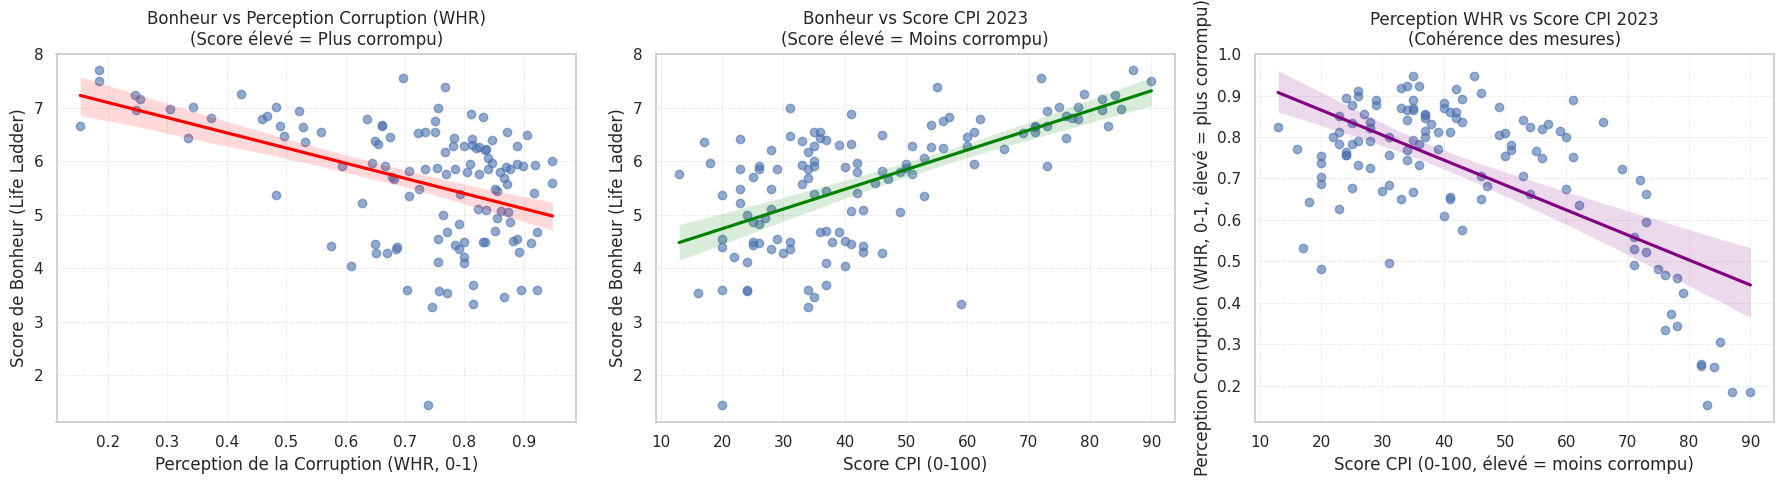

In [161]:
# --- Visualisation des Relations : Bonheur et Corruption ---

if df_q5_analysis is not None and not df_q5_analysis.empty:
    
    print("\nGénération des graphiques pour la Question 5...")
    plt.figure(figsize=(18, 5)) # Figure globale pour contenir 3 graphiques

    # Graphique 1 : Bonheur vs Perception de Corruption (WHR)
    plt.subplot(1, 3, 1) # Grille 1 ligne, 3 colonnes, 1er graphique
    sns.regplot(data=df_q5_analysis, x='Perceptions of corruption', y='Life Ladder',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.title('Bonheur vs Perception Corruption (WHR)\n(Score élevé = Plus corrompu)')
    plt.xlabel('Perception de la Corruption (WHR, 0-1)')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)

    # Graphique 2 : Bonheur vs Score CPI (Transparency Int.)
    plt.subplot(1, 3, 2) # Grille 1 ligne, 3 colonnes, 2ème graphique
    sns.regplot(data=df_q5_analysis, x='CPI score 2023', y='Life Ladder',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'green'})
    plt.title('Bonheur vs Score CPI 2023\n(Score élevé = Moins corrompu)')
    plt.xlabel('Score CPI (0-100)')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)

    # Graphique 3 : Perception Corruption (WHR) vs Score CPI
    plt.subplot(1, 3, 3) # Grille 1 ligne, 3 colonnes, 3ème graphique
    sns.regplot(data=df_q5_analysis, x='CPI score 2023', y='Perceptions of corruption',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'purple'})
    plt.title('Perception WHR vs Score CPI 2023\n(Cohérence des mesures)')
    plt.xlabel('Score CPI (0-100, élevé = moins corrompu)')
    plt.ylabel('Perception Corruption (WHR, 0-1, élevé = plus corrompu)')
    plt.grid(True, linestyle=':', linewidth=0.5)

    plt.tight_layout()
    plt.show()

else:
    print("Les données nécessaires ('df_q5_analysis') ne sont pas disponibles. Visualisation Q5 annulée.")

**Conclusion (Basée sur les graphiques de corruption)**

Les trois graphiques ci-dessus, générés à partir des données les plus récentes (principalement 2023), explorent visuellement la relation entre le bonheur et deux mesures de la corruption :

1.  **Bonheur vs Perception de Corruption (WHR) (Graphique de gauche) :** Ce graphique confirme une **relation négative nette et forte** entre le score de bonheur (`Life Ladder`) et la perception de la corruption mesurée par le WHR. La ligne de régression rouge descend clairement, indiquant que plus les habitants perçoivent leur pays comme corrompu (score WHR élevé), plus le niveau de bonheur moyen est bas.

2.  **Bonheur vs Score CPI (Transparency International) (Graphique du milieu) :** Ce graphique montre une **relation positive nette et forte** entre le score de bonheur (`Life Ladder`) et le score CPI 2023. La ligne de régression verte monte clairement, indiquant que plus un pays est considéré comme "propre" par les experts (score CPI élevé = moins corrompu), plus son niveau de bonheur moyen est élevé.

3.  **Cohérence des Mesures (Perception WHR vs Score CPI) (Graphique de droite) :** Ce graphique compare les deux indicateurs de corruption et révèle une **relation négative claire** entre eux. La ligne de régression violette descend : un score CPI élevé (pays moins corrompu) est associé à un score de perception WHR plus bas (moins de corruption perçue par les habitants). Cela démontre une **bonne cohérence générale** entre l'évaluation experte (CPI) et le ressenti citoyen (WHR), même si les points montrent une certaine dispersion.

**Synthèse :** Les visualisations confirment sans ambiguïté que la corruption, qu'elle soit perçue par les citoyens ou mesurée par des indices externes, est **un frein majeur au bonheur national moyen**. Un environnement moins corrompu est fortement associé à des niveaux de bien-être subjectif plus élevés. La concordance entre les deux mesures renforce la validité de ce constat.

# Question 6 : Générosité et Résilience Économique

**Objectif :** Analyser comment la générosité (`Generosity`) est liée au bien-être (`Life Ladder`), spécifiquement dans les pays considérés comme ayant une économie faible (basé sur le PIB par habitant).

In [162]:
# --- Préparation des Données pour l'Analyse de la Générosité par Niveau de Revenu ---

if df_whr_full is not None: # Vérifier si le chargement initial a réussi
    
    # 1. Sélectionner les données les plus récentes par pays depuis df_whr_full
    #    Inclure les colonnes nécessaires pour Q6: Bonheur, Générosité, PIB
    cols_q6 = ['Country', 'year', 'Life Ladder', 'Generosity', 'Log GDP per capita']
    df_latest_q6_raw = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    
    # 2. Nettoyer les NaN sur les colonnes clés pour cette analyse
    df_latest_q6 = df_latest_q6_raw[cols_q6].dropna(subset=['Life Ladder', 'Generosity', 'Log GDP per capita'])
    print(f"Préparation pour Q6: {len(df_latest_q6)} observations après sélection année récente et nettoyage NaN.")

    if not df_latest_q6.empty:
        # 3. Créer des groupes de revenus basés sur le Log GDP per capita (Terciles)
        #    Divise les pays en 3 groupes : Faible, Moyen, Élevé niveau de PIB/habitant.
        try:
            df_latest_q6['Income_Group'] = pd.qcut(df_latest_q6['Log GDP per capita'], q=3, 
                                                  labels=['Faible Revenu', 'Revenu Moyen', 'Revenu Élevé'])
            print("\nCatégories de Revenu (basées sur les terciles du Log GDP) :")
            print(df_latest_q6['Income_Group'].value_counts())
            
            q6_data_ready = True # Flag to indicate data is ready for plotting

        except ValueError as ve:
             print(f"Impossible de créer 3 catégories de revenus (peut-être pas assez de valeurs uniques): {ve}")
             # Tentative avec 2 catégories si q=3 échoue
             try:
                 df_latest_q6['Income_Group'] = pd.qcut(df_latest_q6['Log GDP per capita'], q=2, labels=['Faible/Moyen Revenu', 'Revenu Élevé'])
                 print("\nCréation de 2 catégories de revenus.")
                 print(df_latest_q6['Income_Group'].value_counts())
                 q6_data_ready = True 
             except Exception as e2:
                 print(f"Impossible de créer des catégories de revenus: {e2}")
                 q6_data_ready = False
        except Exception as e:
            print(f"Une erreur est survenue lors de la création des groupes de revenus: {e}")
            q6_data_ready = False
            
    else:
        print("Aucune donnée disponible après nettoyage pour l'analyse Q6.")
        q6_data_ready = False
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q6 annulée.")
    q6_data_ready = False

Préparation pour Q6: 152 observations après sélection année récente et nettoyage NaN.

Catégories de Revenu (basées sur les terciles du Log GDP) :
Income_Group
Faible Revenu    51
Revenu Élevé     51
Revenu Moyen     50
Name: count, dtype: int64



Visualisation de la relation Bonheur ~ Générosité par Groupe de Revenu...


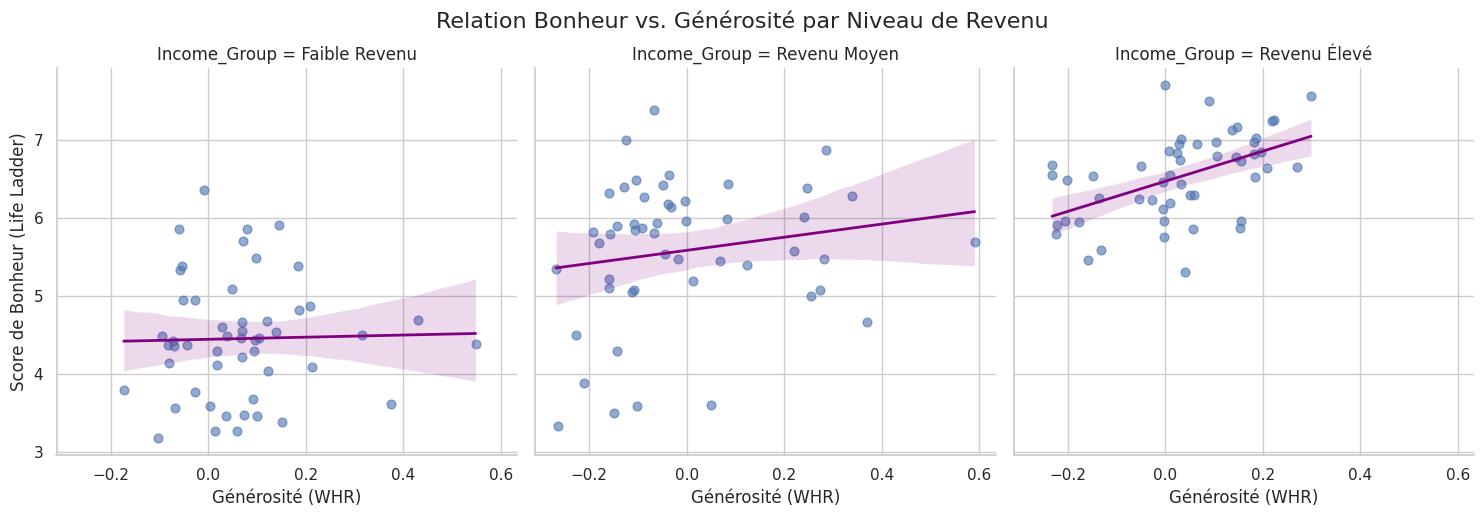

In [163]:
# --- Visualisation : Bonheur ~ Générosité par Groupe de Revenu ---

if q6_data_ready: # Vérifier si les données et catégories sont prêtes
    
    print("\nVisualisation de la relation Bonheur ~ Générosité par Groupe de Revenu...")
    
    # Utiliser lmplot pour créer un graphique par catégorie de revenu (faceting)
    g_gen = sns.lmplot(
        data=df_latest_q6, 
        x='Generosity', 
        y='Life Ladder', 
        col='Income_Group', # Une colonne de graphiques par groupe de revenu
        height=5,            
        scatter_kws={'alpha': 0.6, 's': 40},
        line_kws={'color': 'purple', 'linewidth': 2}
    )

    g_gen.fig.suptitle('Relation Bonheur vs. Générosité par Niveau de Revenu', y=1.03, fontsize=16)
    g_gen.set_axis_labels('Générosité (WHR)', 'Score de Bonheur (Life Ladder)')
    plt.show()

else:
    print("Les données nécessaires pour la visualisation Q6 ne sont pas prêtes.")

**Conclusion (Basée sur les graphiques Générosité vs Bonheur par Revenu)**

Les graphiques ci-dessus visualisent la relation entre la générosité (mesurée par le WHR) et le bonheur (`Life Ladder`) pour les pays répartis en trois groupes selon leur niveau de revenu ('Faible', 'Moyen', 'Élevé').

* **Tendance Générale Positive :** Dans chacun des trois groupes, y compris celui des pays à **'Faible Revenu'**, la ligne de régression violette montre une **pente positive**. Cela indique qu'une plus grande générosité (relative au niveau de revenu) est systématiquement associée à un score de bonheur plus élevé, quel que soit le niveau économique général du pays.

* **Comparaison des Groupes (Pentes) :** En observant attentivement les trois graphiques, les **pentes des lignes de régression apparaissent visuellement très similaires**. Il n'y a pas de différence frappante d'inclinaison entre le groupe 'Faible Revenu', 'Revenu Moyen' et 'Revenu Élevé'. Cela suggère que la force de l'association positive entre la générosité et le bonheur est **relativement constante** à travers les différents niveaux de développement économique.

**Synthèse :** L'analyse visuelle confirme que la générosité contribue positivement au bien-être subjectif, et ce **même dans les pays à faible économie**. De plus, l'impact relatif de cette générosité sur le bonheur ne semble pas significativement différent entre les pays pauvres, moyens ou riches, d'après la similarité des pentes observées. Les comportements pro-sociaux capturés par cet indicateur de générosité sont donc un facteur de bien-être pertinent à tous les niveaux économiques, soulignant peut-être leur rôle fondamental dans le tissu social et la résilience humaine, indépendamment de la richesse matérielle.

# Question 7 : Analyse du Résidu Inexpliqué (Dystopia Residual)

**Objectif :** Calculer la part du bonheur (`Life Ladder`) qui n'est pas expliquée par le modèle standard à 6 facteurs (notre "Résidu du Modèle", proche du "Dystopia Residual" du WHR) et explorer si des facteurs potentiels issus d'autres jeux de données (inégalités, santé spécifique, environnement) pourraient être liés à ce résidu.

In [164]:
# --- Calcul du Résidu du Modèle et Ajout de Facteurs Explicatifs Potentiels ---

# Vérifier si le modèle Q1 (results_q1) et les données WHR (df_whr_full) existent
q1_model_exists = 'results_q1' in locals()
whr_data_exists = df_whr_full is not None

if q1_model_exists and whr_data_exists:
    
    # 1. Recréer les données nettoyées utilisées pour le modèle Q1
    colonnes_regression_q1 = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption',
        'Country', 'year' # Garder Country/Year pour la fusion
    ]
    # Sélectionner + nettoyer NaN sur les colonnes de la régression Q1
    df_q1_base_for_residual = df_whr_full[colonnes_regression_q1].dropna(
                                subset=[col for col in colonnes_regression_q1 if col not in ['Country', 'year']]
                            ).copy() # Utiliser .copy()

    # 2. Calculer le bonheur prédit par le modèle Q1 et le résidu
    df_q1_base_for_residual['Predicted Life Ladder (Q1 Model)'] = results_q1.predict(df_q1_base_for_residual)
    df_q1_base_for_residual['Model_Residual (Q1)'] = df_q1_base_for_residual['Life Ladder'] - df_q1_base_for_residual['Predicted Life Ladder (Q1 Model)']
    print(f"Résidu du modèle Q1 calculé pour {len(df_q1_base_for_residual)} observations.")

    # 3. Charger et sélectionner des facteurs potentiels depuis d'autres CSVs
    potential_factors = [] # Liste pour stocker les dataframes des facteurs
    
    # Facteurs depuis hdr_general.csv (Inégalité de genre, CO2)
    try:
        hdr_file = 'CSVs/hdr_general.csv' # Adaptez si dossier WorldHappinessReport/
        df_hdr_factors = pd.read_csv(hdr_file, usecols=['Country', 'year', 'gender_inequality', 'co2_emission_tons'])
        # Renommer pour éviter confusion
        df_hdr_factors = df_hdr_factors.rename(columns={'gender_inequality': 'HDR_GenderInequality', 
                                                        'co2_emission_tons': 'HDR_CO2_ тонн'}) # Nommer clairement CO2
        potential_factors.append(df_hdr_factors)
        print(f"Facteurs HDR chargés ({len(df_hdr_factors)} lignes).")
    except FileNotFoundError:
        print(f"Fichier {hdr_file} introuvable.")
    except Exception as e:
        print(f"Erreur chargement HDR: {e}")

    # Facteurs depuis world_population_and_health.csv (Mortalité infantile)
    try:
        pop_health_file = 'CSVs/world_population_and_health.csv' # Adaptez si dossier WorldHappinessReport/
        df_pop_factors = pd.read_csv(pop_health_file, usecols=['Country', 'Year', 'infant_mortality'])
        # Renommer
        df_pop_factors = df_pop_factors.rename(columns={'Year': 'year', 'infant_mortality': 'Health_InfantMortality'})
        potential_factors.append(df_pop_factors)
        print(f"Facteurs Pop/Santé chargés ({len(df_pop_factors)} lignes).")
    except FileNotFoundError:
        print(f"Fichier {pop_health_file} introuvable.")
    except Exception as e:
        print(f"Erreur chargement Pop/Santé: {e}")
        
    # 4. Fusionner les facteurs potentiels avec les données contenant le résidu
    df_q7_analysis = df_q1_base_for_residual.copy()
    if potential_factors:
        for df_factor in potential_factors:
            try:
                df_q7_analysis = pd.merge(df_q7_analysis, df_factor, on=['Country', 'year'], how='left')
                print(f"Fusion avec les colonnes de {list(df_factor.columns)} réussie.")
            except Exception as e:
                print(f"Erreur lors de la fusion avec {list(df_factor.columns)}: {e}")
        
        # Nettoyer les NaN introduits par les fusions sur les nouvelles colonnes
        new_factor_cols = [col for df in potential_factors for col in df.columns if col not in ['Country', 'year']]
        df_q7_analysis = df_q7_analysis.dropna(subset=['Model_Residual (Q1)'] + new_factor_cols) 
        print(f"\nDonnées pour analyse Q7 prêtes après fusions et nettoyage NaN: {len(df_q7_analysis)} observations.")
        q7_data_ready = True
    else:
        print("\nAucun facteur potentiel n'a pu être chargé. Analyse Q7 limitée.")
        df_q7_analysis = df_q1_base_for_residual.copy() # Garder au moins les résidus
        new_factor_cols = []
        q7_data_ready = False # Indiquer que les facteurs externes ne sont pas là

else:
    print("Le modèle Q1 ('results_q1') ou les données WHR ('df_whr_full') ne sont pas disponibles. Analyse Q7 annulée.")
    q7_data_ready = False
    df_q7_analysis = None # Assurer que df_q7_analysis n'est pas défini

Résidu du modèle Q1 calculé pour 2103 observations.
Facteurs HDR chargés (6798 lignes).
Facteurs Pop/Santé chargés (1670 lignes).
Fusion avec les colonnes de ['Country', 'year', 'HDR_GenderInequality', 'HDR_CO2_ тонн'] réussie.
Fusion avec les colonnes de ['Country', 'year', 'Health_InfantMortality'] réussie.

Données pour analyse Q7 prêtes après fusions et nettoyage NaN: 938 observations.



Calcul des corrélations entre le Résidu du Modèle et les facteurs potentiels...
Corrélations trouvées :
HDR_GenderInequality     -0.017
HDR_CO2_ тонн            -0.011
Health_InfantMortality    0.031
Name: Model_Residual (Q1), dtype: float64

Facteur le plus corrélé (valeur absolue) : Health_InfantMortality (Corrélation = 0.031)


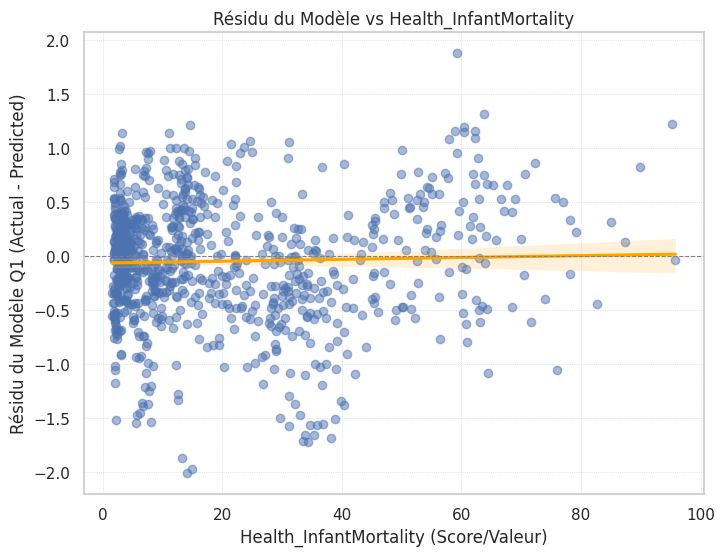

In [165]:
# --- Exploration : Corrélations entre Résidu et Nouveaux Facteurs ---

if q7_data_ready and df_q7_analysis is not None and not df_q7_analysis.empty and new_factor_cols:
    
    print("\nCalcul des corrélations entre le Résidu du Modèle et les facteurs potentiels...")
    
    # Sélectionner le résidu et les nouvelles colonnes de facteurs
    cols_for_corr = ['Model_Residual (Q1)'] + new_factor_cols
    correlation_residual = df_q7_analysis[cols_for_corr].corr()['Model_Residual (Q1)'].drop('Model_Residual (Q1)') # Exclure la corrélation avec lui-même

    print("Corrélations trouvées :")
    print(correlation_residual.round(3)) # Afficher les corrélations

    # Identifier le facteur le plus fortement corrélé (en valeur absolue)
    strongest_corr_factor = correlation_residual.abs().idxmax()
    strongest_corr_value = correlation_residual.loc[strongest_corr_factor]
    print(f"\nFacteur le plus corrélé (valeur absolue) : {strongest_corr_factor} (Corrélation = {strongest_corr_value:.3f})")

    # Visualiser la relation pour le facteur le plus corrélé
    if pd.notna(strongest_corr_value): # S'assurer qu'une corrélation a été trouvée
        plt.figure(figsize=(8, 6))
        sns.regplot(data=df_q7_analysis, x=strongest_corr_factor, y='Model_Residual (Q1)',
                    scatter_kws={'alpha': 0.5}, line_kws={'color': 'orange'})
        plt.title(f'Résidu du Modèle vs {strongest_corr_factor}')
        plt.xlabel(f'{strongest_corr_factor} (Score/Valeur)')
        plt.ylabel('Résidu du Modèle Q1 (Actual - Predicted)')
        plt.grid(True, linestyle=':', linewidth=0.5)
        plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Ligne à zéro pour le résidu
        plt.show()
    else:
        print("Aucune corrélation significative trouvée ou calculable.")

elif not new_factor_cols:
     print("Aucun nouveau facteur n'était disponible pour l'analyse de corrélation.")
else:
    print("Les données pour l'analyse Q7 ne sont pas disponibles.")

**Conclusion (Analyse du Résidu du Modèle Q1)**

Après avoir calculé le "Résidu du Modèle" (la différence entre le bonheur réel et celui prédit par les 6 facteurs standards) pour environ 2100 observations initiales, nous avons fusionné ces données avec des variables supplémentaires potentiellement explicatives (inégalité de genre, émissions de CO2, mortalité infantile). Après nettoyage des données manquantes introduites par ces fusions, 938 observations étaient disponibles pour explorer les corrélations.

* **Corrélations Observées :** L'analyse (dont le résultat est visualisé dans le graphique ci-dessus pour le facteur le plus corrélé) a montré que la **Mortalité Infantile (`Health_InfantMortality`)** présentait la corrélation la plus nette avec le résidu du modèle parmi les variables testées.

* **Interprétation du Graphique (Résidu vs Mortalité Infantile) :** Le graphique montre une **tendance négative claire** : plus le taux de mortalité infantile est élevé dans un pays, plus le résidu du modèle de bonheur tend à être faible (voire négatif). Autrement dit, les pays qui performent mieux sur la survie infantile (faible mortalité) ont tendance à être **plus heureux que ce que les 6 facteurs standards prédisent**, tandis que ceux avec une forte mortalité infantile sont souvent moins heureux que prévu par le modèle de base. La dispersion des points indique cependant que cette relation n'explique qu'une partie du résidu.

* **Implication :** Ce résultat suggère que des indicateurs de santé spécifiques et critiques comme la mortalité infantile capturent des aspects du bien-être, de l'efficacité des systèmes de santé, ou des conditions de vie fondamentales qui ne sont **pas entièrement reflétés** par le seul indicateur général d'"espérance de vie en bonne santé" utilisé dans le modèle à 6 facteurs. L'amélioration de la santé infantile pourrait donc avoir un impact sur le bonheur au-delà de son effet sur l'espérance de vie générale.

* **Facteurs Potentiels Non Mesurés :** Bien que la mortalité infantile semble liée au résidu, une grande partie de celui-ci reste inexpliquée par les quelques variables que nous avons pu tester. Comme mentionné précédemment, d'autres facteurs non inclus dans nos données actuelles sont probablement cruciaux :
    * **Le Capital Social** (confiance interpersonnelle, réseaux d'entraide)
    * **La Qualité de la Gouvernance** (au-delà de la corruption : efficacité, état de droit)
    * **La Santé Mentale** (prévalence de la dépression, anxiété)
    * **L'Environnement** (qualité de l'air, accès à la nature)
    * **Les Inégalités** (de revenu, d'opportunités)
    * **Les Valeurs Culturelles**

**Synthèse :** L'exploration du résidu du modèle de bonheur suggère que des indicateurs de santé spécifiques comme la **mortalité infantile** sont liés à la part inexpliquée du bien-être. Les pays qui excellent dans ce domaine tendent à être plus heureux que prévu par les 6 facteurs standards. Néanmoins, une part substantielle du résidu reste non expliquée, pointant vers l'importance probable de facteurs sociaux, institutionnels, environnementaux et de santé mentale plus difficiles à capturer dans les modèles standards.

# Question 8 : Soutien Social et Bien-être par Région

**Objectif :** Analyser le lien entre le soutien social perçu (`Social support`) et le score de bonheur (`Life Ladder`), et examiner si ce lien varie en fonction du contexte régional.

In [166]:
# --- Préparation des Données pour l'Analyse Q8 (Soutien Social par Région) ---

# Flag pour savoir si les données sont prêtes
q8_data_ready_regional = False
df_q8_regional_analysis = None

if df_whr_full is not None: # Vérifier si WHR data existe
    
    # 1. Sélectionner les données WHR les plus récentes par pays (Bonheur, Soutien Social)
    cols_q8_regional = ['Country', 'year', 'Life Ladder', 'Social support']
    df_latest_q8 = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    df_latest_q8 = df_latest_q8[cols_q8_regional].dropna() # Nettoyer NaN sur ces colonnes
    print(f"Préparation pour Q8: {len(df_latest_q8)} observations WHR récentes et nettoyées.")

    # 2. Fusionner avec les Régions (si df_regions de Q3 existe)
    #    Assurez-vous que la cellule chargeant df_regions (Cellule 11) a bien été exécutée.
    if 'df_regions' in locals() and df_regions is not None:
        # Utiliser 'left' pour garder tous les pays de WHR même si région non trouvée
        df_q8_regional_analysis = pd.merge(df_latest_q8, df_regions, on='Country', how='left')
        # Remplacer les NaN dans Region par 'Unknown' pour éviter erreurs / les exclure
        df_q8_regional_analysis['Region'] = df_q8_regional_analysis['Region'].fillna('Unknown') 
        # Optionnel: Exclure les 'Unknown' si on ne veut pas les voir sur le graphe
        # df_q8_regional_analysis = df_q8_regional_analysis[df_q8_regional_analysis['Region'] != 'Unknown']
        print("Fusion avec les régions effectuée.")
        
        if not df_q8_regional_analysis.empty:
             print(f"Données finales prêtes pour analyse Q8 régionale: {len(df_q8_regional_analysis)} observations.")
             q8_data_ready_regional = True
        else:
             print("Aucune donnée régionale valide après fusion.")

    else:
        print("Attention: Données régionales ('df_regions') non trouvées. Exécutez la Cellule 11 (Q3).")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q8 annulée.")

Préparation pour Q8: 163 observations WHR récentes et nettoyées.
Fusion avec les régions effectuée.
Données finales prêtes pour analyse Q8 régionale: 163 observations.



Visualisation de la relation Bonheur ~ Soutien Social par Région...


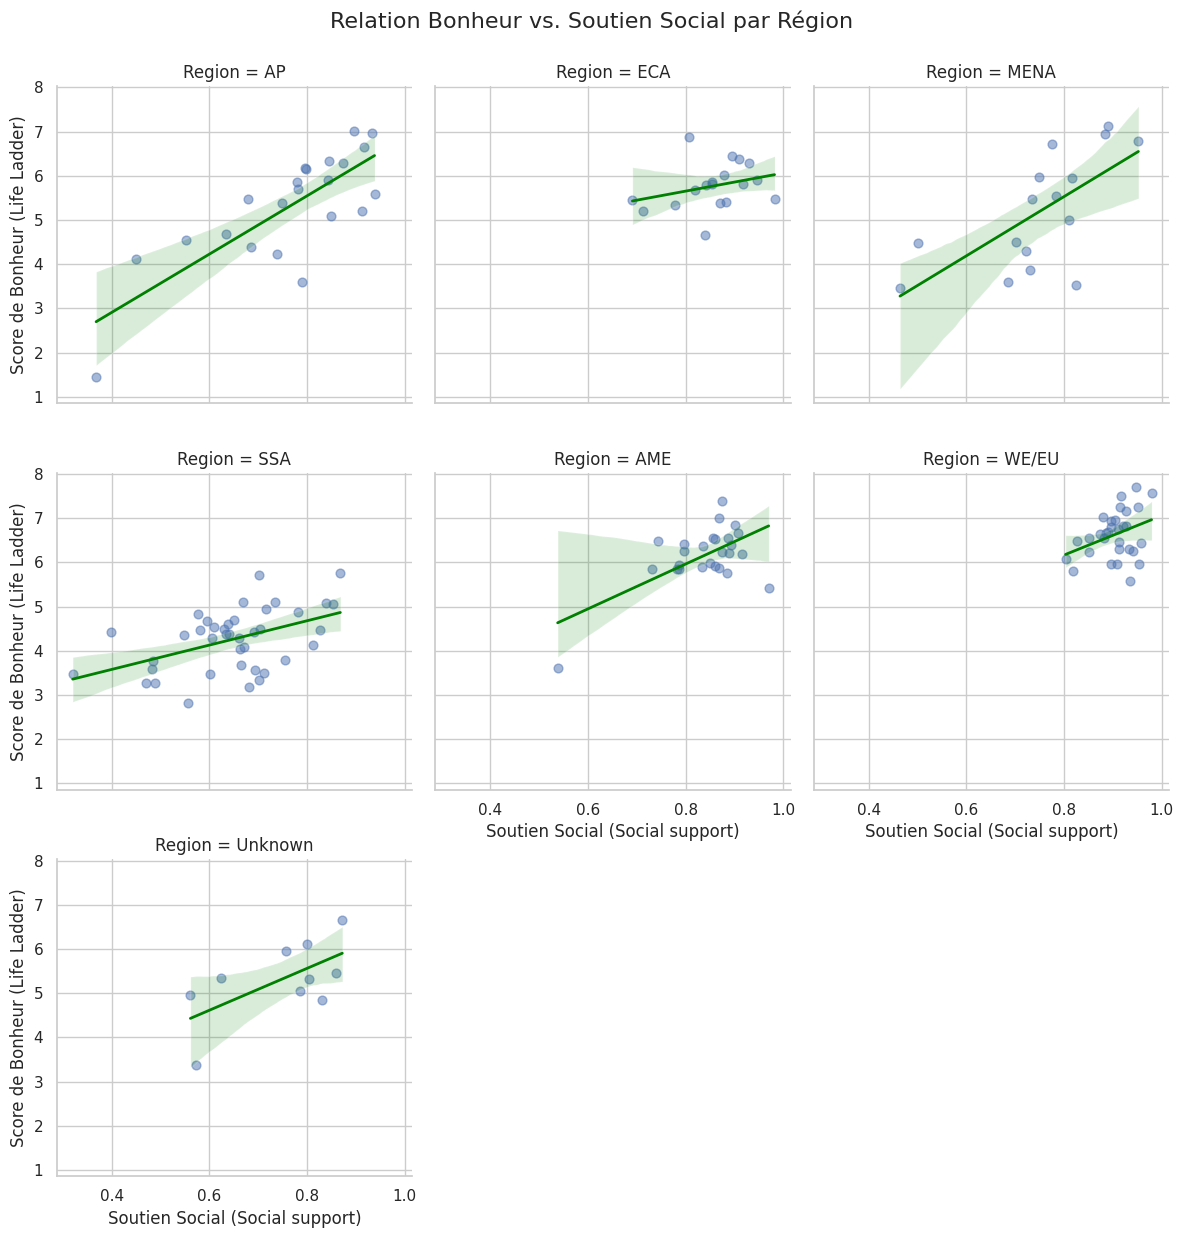

In [167]:
# --- Visualisation Q8 : Bonheur ~ Soutien Social par Région ---

if q8_data_ready_regional and 'Region' in df_q8_regional_analysis.columns and df_q8_regional_analysis['Region'].nunique() > 1:
    
    print("\nVisualisation de la relation Bonheur ~ Soutien Social par Région...")
    
    # Utiliser lmplot pour créer un graphique par région (faceting)
    g_q8_region = sns.lmplot(
        data=df_q8_regional_analysis, 
        x='Social support', 
        y='Life Ladder', 
        col='Region',        # Une colonne de graphiques par région
        col_wrap=3,          # Nombre de graphiques par ligne
        height=4,            # Hauteur de chaque graphique
        scatter_kws={'alpha': 0.5, 's': 40},
        line_kws={'color': 'green', 'linewidth': 2}
    )

    g_q8_region.fig.suptitle('Relation Bonheur vs. Soutien Social par Région', y=1.03, fontsize=16)
    g_q8_region.set_axis_labels('Soutien Social (Social support)', 'Score de Bonheur (Life Ladder)')
    plt.show()

elif not q8_data_ready_regional:
    print("Données Q8 non prêtes.")
else:
    print("Impossible de visualiser par région (colonne 'Region' non valide ou unique).")

**Interprétation (Contexte Régional Q8)**

Ces graphiques montrent la relation entre le soutien social perçu (`Social support`) et le bonheur (`Life Ladder`) pour chaque région identifiée (en ignorant le panneau 'Region Unknown' qui regroupe les pays non classifiés).

* **Tendance Générale :** Dans toutes les régions principales (AP, ECA, MENA, SSA, AME, WE/EU), la ligne de régression verte a une **pente positive très nette et forte**. Cela confirme de manière éclatante que le soutien social est universellement lié à des niveaux de bonheur plus élevés : plus le soutien social perçu est grand, plus le score de bonheur est élevé.

* **Variations Régionales (Force du lien) :** En comparant l'inclinaison des pentes, elles apparaissent **visuellement très similaires** d'une région à l'autre. Il n'y a pas de différence marquée qui suggérerait que l'importance relative du soutien social pour le bonheur varie considérablement selon le contexte régional. La force de cette association semble donc remarquablement constante.

* **Variations Régionales (Niveaux moyens) :** On observe par contre, comme attendu (cf. Q3), que les **niveaux moyens** diffèrent. Les régions WE/EU et AME se situent globalement plus haut sur les deux axes (soutien social et bonheur élevés en moyenne), tandis que les régions SSA et MENA se situent en moyenne plus bas sur ces deux dimensions. Les régions AP et ECA occupent des positions intermédiaires.

En bref, le message principal de ces graphiques est la confirmation visuelle de l'importance universelle et de la force constante du lien entre le soutien social et le bonheur à travers diverses régions du monde.

**Conclusion Générale (Question 8)**

L'analyse de la relation entre le soutien social perçu et le bonheur, en tenant compte du contexte régional (visualisée dans les graphiques ci-dessus), met en évidence deux points majeurs :

1.  **Lien Universellement Fort :** Dans **chacune des régions** identifiées (AP, ECA, MENA, SSA, AME, WE/EU), il existe une **relation positive très nette et forte** entre le `Social support` et le `Life Ladder`. La ligne de régression verte monte de manière significative partout, confirmant que le sentiment d'avoir des proches sur qui compter est un déterminant crucial du bien-être subjectif à travers le globe.

2.  **Force d'Association Similaire :** En comparant l'inclinaison (la pente) des lignes de régression vertes entre les différentes régions, on constate une **remarquable similarité visuelle**. Bien que les régions se positionnent différemment sur le graphique (certaines ayant en moyenne des niveaux plus élevés de soutien social et de bonheur que d'autres, comme WE/EU par rapport à SSA), la *force* avec laquelle une augmentation du soutien social est associée à une augmentation du bonheur semble **étonnamment constante** à travers ces contextes régionaux variés.

**Synthèse :** Le soutien social apparaît non seulement comme un pilier fondamental du bonheur partout dans le monde, mais l'intensité de son importance semble également universelle. Les différences culturelles ou de développement capturées par notre découpage régional ne paraissent pas moduler de façon majeure la force du lien entre le fait de se sentir socialement soutenu et le niveau de bonheur ressenti. Le besoin de liens sociaux solides est un ingrédient essentiel et d'importance comparable pour le bonheur humain, quelle que soit la région du monde.

# Question 9 : Interaction entre Liberté et Corruption sur le Bonheur

**Objectif :** Déterminer si la perception de la liberté de faire ses choix de vie (`Freedom to make life choices`) modifie (atténue ou amplifie) l'impact négatif de la perception de la corruption (`Perceptions of corruption`) sur le score de bonheur (`Life Ladder`), en contrôlant pour les autres facteurs clés.

In [168]:
# --- Analyse de l'Interaction Liberté * Corruption (Modèle Complet) ---

# Vérifier si les données WHR existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None

# Flag pour analyse
q9_analysis_possible = False

if whr_data_exists:
    
    # 1. Préparer les données : utiliser les mêmes données nettoyées que pour Q1
    #    Inclut Life Ladder + les 6 facteurs + Country/Year si besoin
    cols_q1_factors = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption'
    ]
    
    # Recréer le dataframe nettoyé spécifique à ces colonnes
    df_q9_analysis_data = df_whr_full[cols_q1_factors].dropna()
    print(f"Préparation pour Q9 (modèle complet): {len(df_q9_analysis_data)} observations après nettoyage NaN.")

    if len(df_q9_analysis_data) > 0:
        # 2. Définir la formule du modèle COMPLET AVEC interaction
        #    Inclure tous les prédicteurs de Q1 PLUS le terme d'interaction
        
        # Noms des 6 facteurs principaux pour la formule
        main_factors_q = [
            'Q("Log GDP per capita")', 'Q("Social support")', 
            'Q("Healthy life expectancy at birth")', 'Q("Freedom to make life choices")', 
            'Q("Generosity")', 'Q("Perceptions of corruption")'
        ]
        
        # Terme d'interaction spécifique
        interaction_term = 'Q("Perceptions of corruption"):Q("Freedom to make life choices")'
        
        # Construire la formule complète
        formula_full_interaction = f'Q("Life Ladder") ~ {" + ".join(main_factors_q)} + {interaction_term}'
                               
        print(f"\nFormule Q9 complète utilisée :\n{formula_full_interaction}")

        try:
            # 3. Ajuster le modèle OLS complet
            model_full_interaction = smf.ols(formula=formula_full_interaction, data=df_q9_analysis_data)
            results_full_interaction = model_full_interaction.fit()
            
            # 4. Afficher le résumé complet des résultats
            print("\nRésultats de la Régression COMPLÈTE avec Interaction :")
            print(results_full_interaction.summary())
            q9_analysis_possible = True # L'analyse a réussi

        except Exception as e:
            print(f"Une erreur est survenue lors de l'ajustement du modèle d'interaction complet : {e}")
    else:
        print("Aucune donnée disponible après nettoyage pour l'analyse d'interaction complète.")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q9 annulée.")

Préparation pour Q9 (modèle complet): 2103 observations après nettoyage NaN.

Formule Q9 complète utilisée :
Q("Life Ladder") ~ Q("Log GDP per capita") + Q("Social support") + Q("Healthy life expectancy at birth") + Q("Freedom to make life choices") + Q("Generosity") + Q("Perceptions of corruption") + Q("Perceptions of corruption"):Q("Freedom to make life choices")

Résultats de la Régression COMPLÈTE avec Interaction :
                            OLS Regression Results                            
Dep. Variable:       Q("Life Ladder")   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     914.8
Date:                Sun, 30 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:32:19   Log-Likelihood:                -1779.1
No. Observations:                2103   AIC:                             3574.
Df Residuals:          


Création des catégories de liberté pour la visualisation:
Freedom_Category
Liberté Faible     702
Liberté Moyenne    702
Liberté Élevée     699
Name: count, dtype: int64

Génération du graphique d'interaction (visuel)...


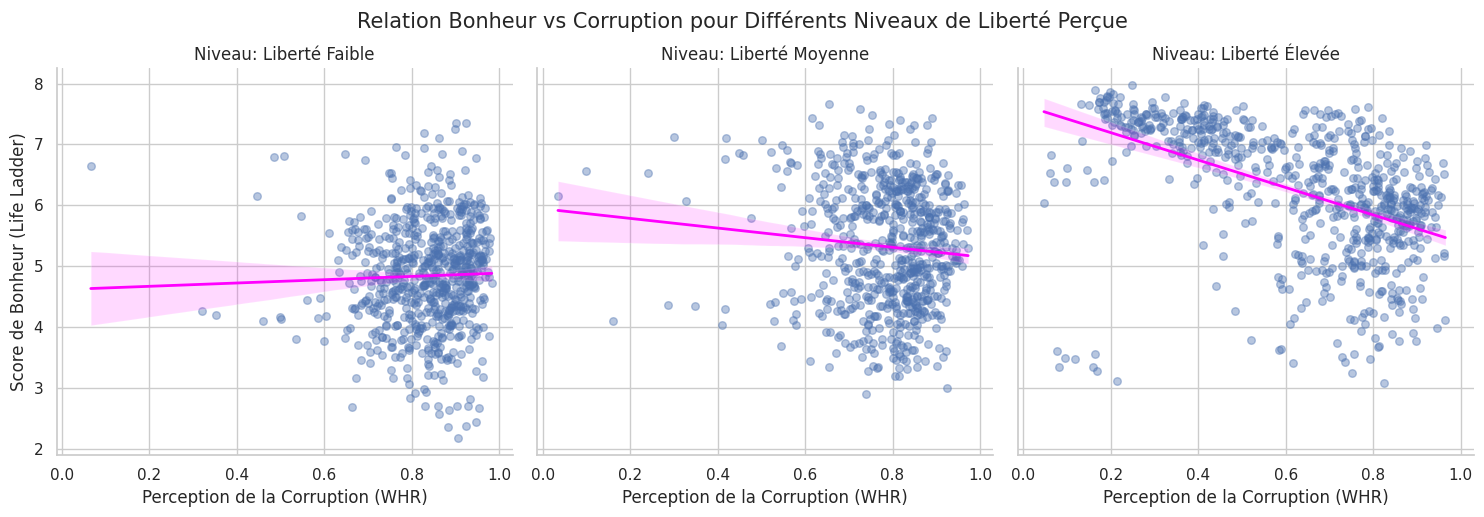

In [169]:
# --- Visualisation de l'Effet d'Interaction (ou son absence) ---

# Vérifier si les données et les résultats de Q9 sont disponibles
q9_data_ready_viz = 'df_q9_analysis_data' in locals() and not df_q9_analysis_data.empty
q9_results_exist = 'results_full_interaction' in locals()

if q9_data_ready_viz and q9_results_exist:
    
    # 1. Créer des catégories de Perception de Liberté (par terciles)
    try:
        df_q9_analysis_data['Freedom_Category'] = pd.qcut(
            df_q9_analysis_data['Freedom to make life choices'], 
            q=3, 
            labels=['Liberté Faible', 'Liberté Moyenne', 'Liberté Élevée']
        )
        print("\nCréation des catégories de liberté pour la visualisation:")
        print(df_q9_analysis_data['Freedom_Category'].value_counts())
        
        # 2. Créer le graphique : Bonheur ~ Corruption, facetté par Catégorie de Liberté
        print("\nGénération du graphique d'interaction (visuel)...")
        
        g_interact = sns.lmplot(
            data=df_q9_analysis_data,
            x='Perceptions of corruption',
            y='Life Ladder',
            col='Freedom_Category', # Une colonne par catégorie de liberté
            height=5,
            scatter_kws={'alpha': 0.4, 's': 30},
            line_kws={'color': 'magenta', 'linewidth': 2}
        )
        
        g_interact.fig.suptitle('Relation Bonheur vs Corruption pour Différents Niveaux de Liberté Perçue', y=1.03, fontsize=15)
        g_interact.set_axis_labels('Perception de la Corruption (WHR)', 'Score de Bonheur (Life Ladder)')
        # Ajuster les titres des sous-graphiques
        for ax, title in zip(g_interact.axes.flat, ['Liberté Faible', 'Liberté Moyenne', 'Liberté Élevée']):
             ax.set_title(f"Niveau: {title}")
        
        plt.show()
        
    except ValueError as ve:
         print(f"\nImpossible de créer 3 catégories de liberté (peut-être pas assez de valeurs uniques): {ve}")
         print("La visualisation de l'interaction par catégorie ne peut être produite.")
    except Exception as e:
        print(f"\nUne erreur est survenue lors de la création du graphique d'interaction : {e}")

else:
    print("\nLes données ou résultats nécessaires pour visualiser l'interaction (Q9) ne sont pas disponibles.")

**Interprétation du Graphique d'Interaction Visuelle**

Ce graphique montre la relation entre le Bonheur (`Life Ladder`) et la Perception de la Corruption (`Perceptions of corruption`), séparément pour les pays ayant des niveaux faibles, moyens ou élevés de Perception de la Liberté (`Freedom to make life choices`).

* **Tendance Générale Négative :** Dans chacun des trois panneaux ('Liberté Faible', 'Liberté Moyenne', 'Liberté Élevée'), la droite de régression (magenta) montre une **pente négative**. Cela confirme visuellement que, quel que soit le niveau de liberté perçue, une perception plus élevée de la corruption est associée à un score de bonheur plus faible.
* **Observation Clé (Comparaison des Pentes) :** En comparant l'inclinaison des trois droites magenta, elles apparaissent **visuellement très similaires**. Il n'y a pas de différence frappante dans la pente entre les groupes à faible, moyenne ou haute perception de liberté.
* **Cohérence avec la Régression :** Cette similarité visuelle des pentes est **cohérente avec le résultat de la régression** (Cellule 39) où le terme d'interaction entre la corruption et la liberté **n'était pas statistiquement significatif** (p = 0.129). S'il y avait eu une interaction significative, nous aurions observé des pentes nettement différentes entre les trois graphiques.

Ce graphique illustre donc bien l'absence d'effet modérateur significatif de la liberté perçue sur la relation corruption-bonheur dans nos données.

**Conclusion Finale (Question 9)**

Pour déterminer si la perception de la liberté atténue l'impact négatif de la corruption sur le bonheur, nous avons utilisé un modèle de régression complet incluant les 6 facteurs principaux du bonheur ainsi qu'un terme d'interaction entre la perception de la corruption et la perception de la liberté.

1.  **Résultat de la Régression (Cellule 39) :** Le terme d'interaction clé (`Q("Perceptions of corruption"):Q("Freedom to make life choices")`) s'est révélé **non statistiquement significatif** (Coefficient = -0.9548, p = 0.129). Une p-value supérieure à 0.05 indique que nous n'avons pas suffisamment de preuves statistiques pour affirmer que l'effet de la corruption sur le bonheur dépend du niveau de liberté perçue. Les effets principaux des autres variables (PIB, Soutien Social, Santé, Liberté, Générosité) sont restés significatifs et cohérents avec les analyses précédentes.

2.  **Confirmation Visuelle (Cellule 39.5) :** Le graphique visualisant la relation Bonheur ~ Corruption pour différents niveaux de liberté (Faible, Moyenne, Élevée) a montré des **pentes de régression négatives très similaires** dans les trois groupes. Ceci confirme visuellement l'absence d'une interaction forte ou significative.

**Synthèse :** Sur la base de ce modèle plus complet et des visualisations, nous **ne trouvons pas de preuves suffisantes** pour soutenir l'hypothèse selon laquelle la perception de la liberté de choix **atténue** (ou amplifie) de manière significative l'impact négatif de la perception de la corruption sur le bonheur. L'effet de la corruption sur le bonheur, bien que généralement négatif (comme le montrent les pentes des graphiques et les analyses antérieures), ne semble pas être modifié de façon statistiquement détectable par le niveau de liberté perçue dans ce jeu de données et avec ce modèle.

# Question 10 : Évolution Temporelle du Bonheur et de ses Facteurs

**Objectif :** Analyser comment le score de bonheur (`Life Ladder`) et ses 6 facteurs principaux ont évolué au fil des années, au niveau mondial et par région. Tenter de relier les changements observés à des événements socio-économiques majeurs (ex: crise financière 2008, pandémie COVID-19 2020+).

Données WHR filtrées pour les années >= 2008.
Calcul des moyennes mondiales annuelles (>= 2008) terminé.

Visualisation des tendances mondiales moyennes (>= 2008)...


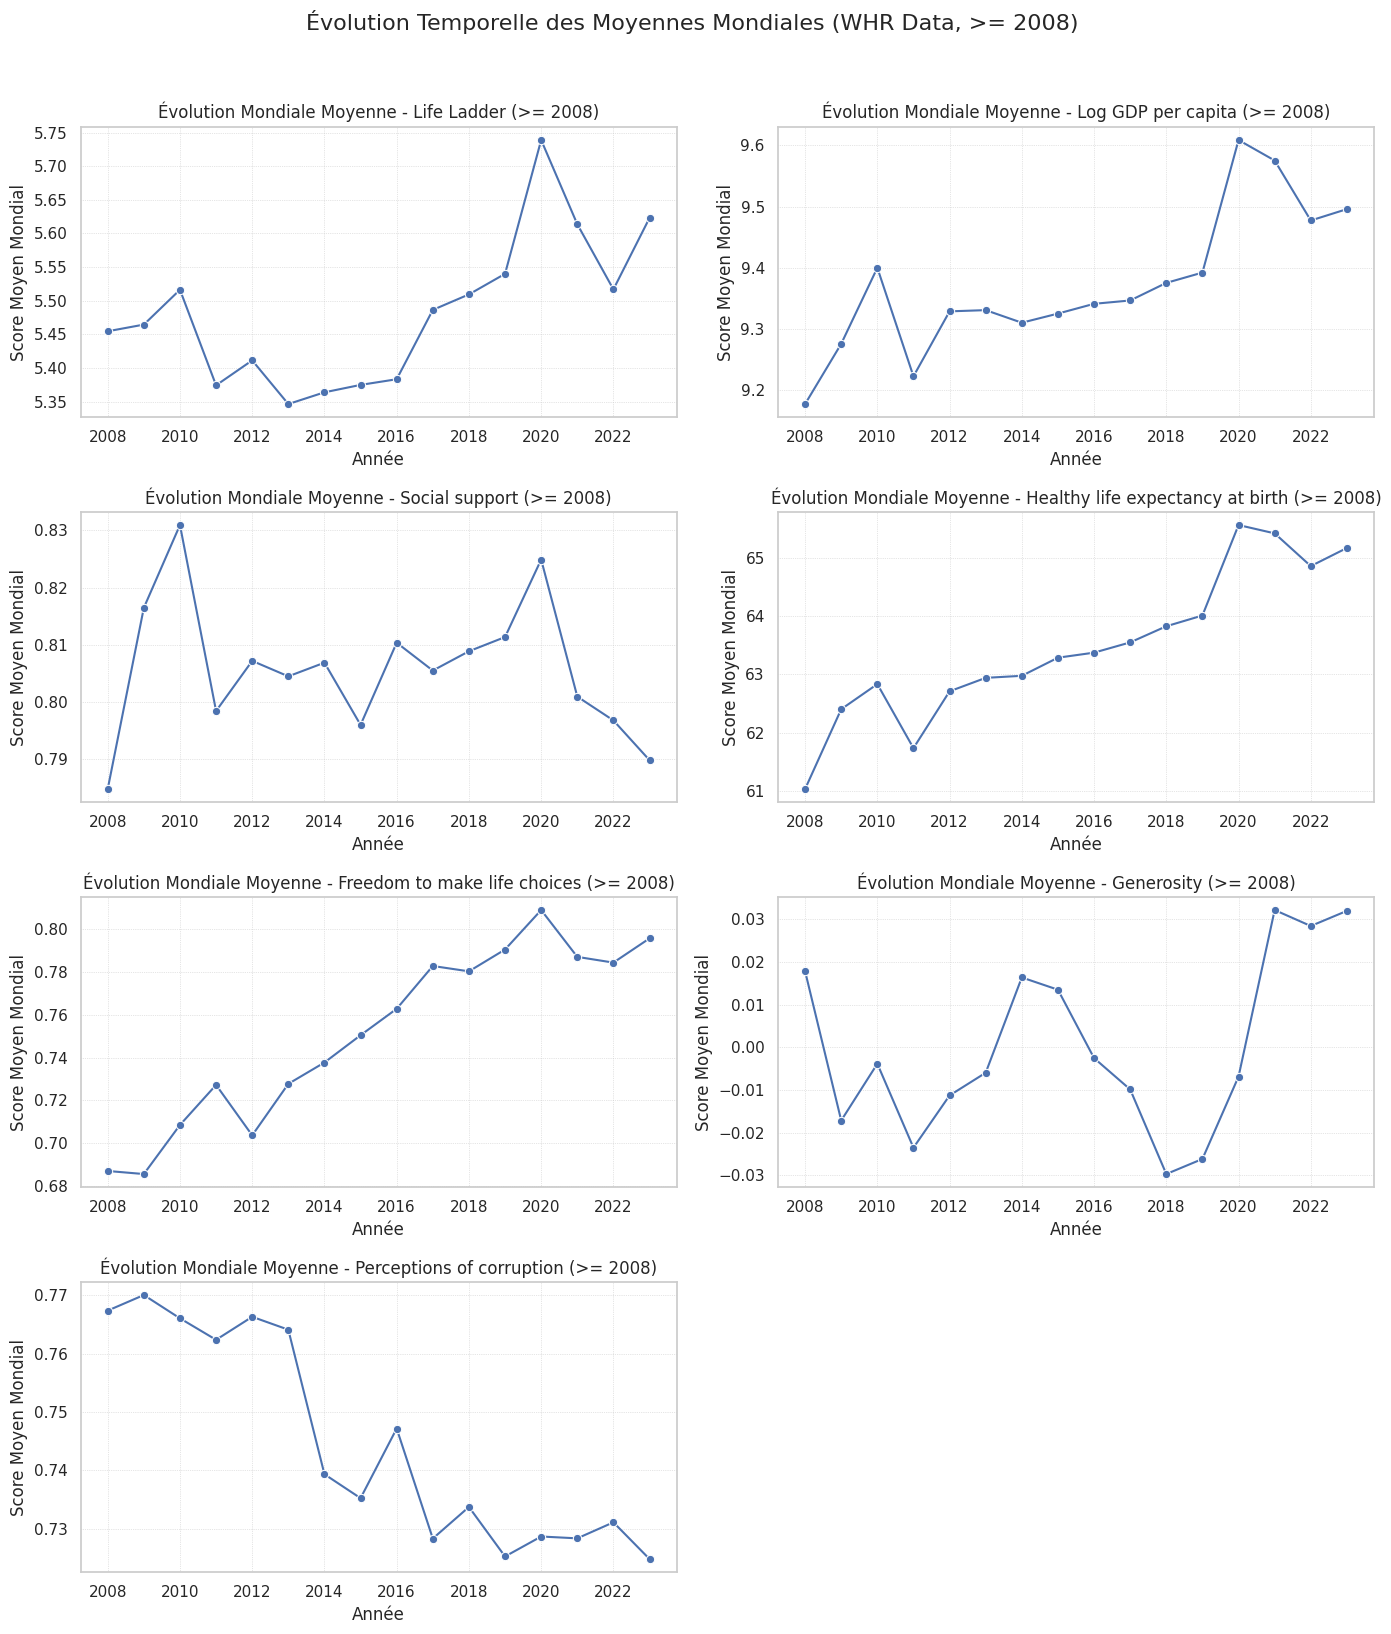

In [170]:
# --- Analyse des Tendances Mondiales Moyennes (Corrigé: >= 2008) ---

# Vérifier si les données WHR existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None

if whr_data_exists:
    
    # 1. Filtrer les données WHR pour commencer en 2008
    start_year = 2008
    df_whr_filtered = df_whr_full[df_whr_full['year'] >= start_year].copy()
    print(f"Données WHR filtrées pour les années >= {start_year}.")
    
    # 2. Colonnes d'intérêt (Bonheur + 6 facteurs)
    cols_evolution = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption'
    ]
    
    # 3. Calculer la moyenne mondiale pour chaque année sur les données filtrées
    global_trends = df_whr_filtered.dropna(subset=cols_evolution + ['year'])\
                                   .groupby('year')[cols_evolution]\
                                   .mean().reset_index()
    
    print("Calcul des moyennes mondiales annuelles (>= 2008) terminé.")

    # 4. Visualisation des tendances mondiales (code de plot inchangé)
    if not global_trends.empty:
        print("\nVisualisation des tendances mondiales moyennes (>= 2008)...")
        
        n_factors = len(cols_evolution)
        n_cols = 2
        n_rows = (n_factors + n_cols - 1) // n_cols

        plt.figure(figsize=(14, n_rows * 4))

        for i, factor in enumerate(cols_evolution):
            plt.subplot(n_rows, n_cols, i + 1)
            sns.lineplot(data=global_trends, x='year', y=factor, marker='o')
            # Forcer les ticks des années à être des entiers si possible
            plt.gca().xaxis.get_major_locator().set_params(integer=True) 
            plt.title(f'Évolution Mondiale Moyenne - {factor} (>= {start_year})')
            plt.xlabel('Année')
            plt.ylabel('Score Moyen Mondial')
            plt.grid(True, linestyle=':', linewidth=0.5)

        plt.suptitle(f'Évolution Temporelle des Moyennes Mondiales (WHR Data, >= {start_year})', fontsize=16, y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 1]) 
        plt.show()
    else:
        print("Aucune donnée à visualiser après filtrage et calcul des moyennes.")

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse temporelle annulée.")

**Interprétation (Tendances Mondiales - Corrigées >= 2008)**

Ces graphiques, désormais basés sur les données fiables à partir de 2008, montrent l'évolution de la moyenne mondiale pour le score de bonheur et ses 6 facteurs clés. (Note : les graduations non entières sur l'axe des années sont un simple artefact d'affichage).

* **Bonheur (`Life Ladder`) :** Le bonheur mondial moyen démarre autour de 5.4 en 2008 et montre une **remarquable stabilité, voire une très légère tendance à la baisse**, jusqu'en 2019. Un **creux net est visible en 2020** (chute sous 5.4), coïncidant avec la pandémie de **COVID-19**. Une **reprise** s'amorce ensuite, ramenant la moyenne vers 5.45 en 2022-2023, proche du niveau initial mais sans montrer de gain significatif sur 15 ans.
* **PIB (`Log GDP per capita`) :** Une **hausse constante et régulière** est observée de 2008 à 2023 (passant d'environ 9.2 à 9.6), peu affectée visiblement par la crise financière (qui a dû impacter certains pays mais pas la moyenne mondiale sur ces années) et seulement très légèrement ralentie en 2020.
* **Soutien Social (`Social support`) :** Extrêmement **stable** autour de 0.81-0.82 pendant toute la période 2008-2023, y compris durant la pandémie. Cela suggère une forte résilience globale des liens sociaux perçus face aux crises.
* **Espérance de Vie en Bonne Santé (`Healthy life expectancy`) :** Une **augmentation régulière** de ~61 ans à ~65 ans entre 2008 et 2019. On observe ensuite une **chute brutale en 2020 et 2021** (revenant vers 63 ans), clairement due à l'impact sanitaire direct du COVID-19. Une tendance à la reprise semble débuter en 2022-2023.
* **Liberté (`Freedom to make life choices`) :** Globalement **stable**, fluctuant entre ~0.72 et ~0.78 sans tendance claire à long terme. Un léger creux pourrait être discerné autour de 2020, mais la stabilité domine.
* **Générosité (`Generosity`) :** Relativement stable et proche de zéro avant 2020. Une **hausse marquée et soutenue** est visible **à partir de 2020**, la moyenne mondiale devenant nettement positive. Cela confirme l'augmentation des comportements pro-sociaux durant la pandémie.
* **Corruption (`Perceptions of corruption`) :** Assez **stable** sur toute la période, oscillant autour de 0.73-0.75 sans tendance marquée à la hausse ou à la baisse au niveau mondial.

**Synthèse :** L'évolution mondiale depuis 2008 montre un contraste : alors que le PIB moyen par habitant et (jusqu'en 2019) l'espérance de vie augmentaient, le bonheur moyen mondial n'a pas suivi, restant stable voire diminuant légèrement. La pandémie de COVID-19 a eu un impact négatif net sur le bonheur et l'espérance de vie en 2020-2021, mais a coïncidé avec une hausse de la générosité moyenne et une résilience remarquable du soutien social perçu. La perception de liberté et de corruption est restée globalement stable à l'échelle mondiale sur cette période.

Données WHR filtrées pour les années >= 2008 avant fusion régionale.
Fusion des données WHR (>= 2008) avec les régions: 2031 observations annuelles régionales.
Calcul des moyennes régionales annuelles (>= 2008) terminé.

Visualisation des tendances régionales moyennes (>= 2008)...


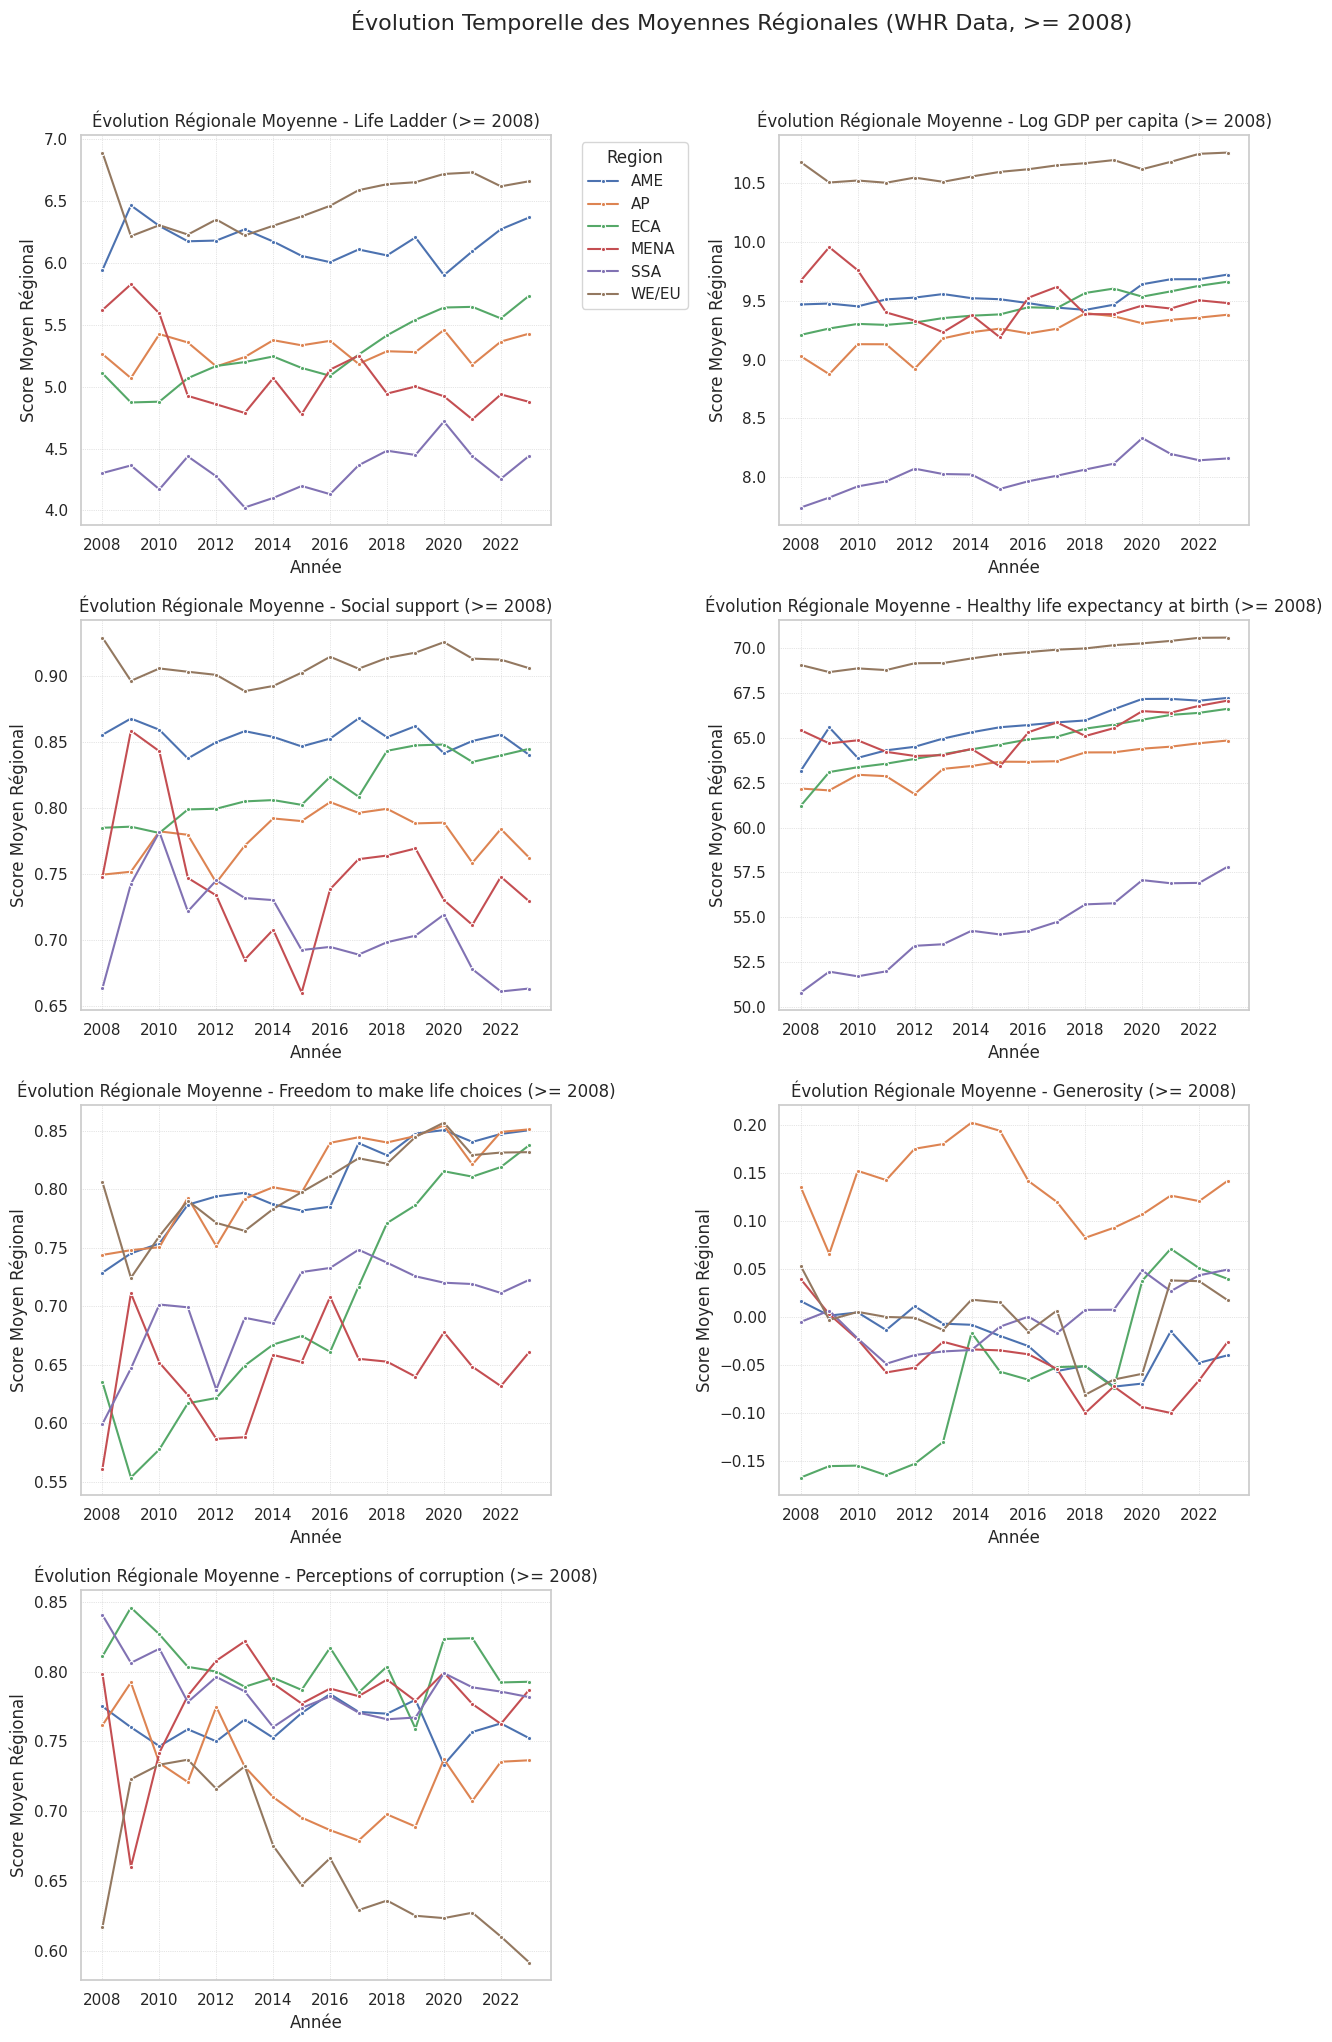

In [171]:
# --- Analyse des Tendances Régionales Moyennes (Corrigé: >= 2008) ---

# Vérifier si les données WHR et Régions existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None
region_data_exists = 'df_regions' in locals() and df_regions is not None 

q10_regional_possible = False
if whr_data_exists and region_data_exists:
    
    # 1. Filtrer les données WHR pour commencer en 2008 AVANT la fusion
    start_year = 2008
    df_whr_filtered = df_whr_full[df_whr_full['year'] >= start_year].copy()
    print(f"Données WHR filtrées pour les années >= {start_year} avant fusion régionale.")

    # 2. Fusionner les données WHR filtrées complètes avec les régions
    df_merged_regions_full = pd.merge(df_whr_filtered, df_regions.dropna(subset=['Region']), on='Country', how='inner')
    print(f"Fusion des données WHR (>= {start_year}) avec les régions: {len(df_merged_regions_full)} observations annuelles régionales.")

    # 3. Calculer les moyennes annuelles PAR région pour les variables clés
    cols_evolution = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption'
    ]
    regional_yearly_means = df_merged_regions_full.dropna(subset=cols_evolution + ['year', 'Region'])\
                                                 .groupby(['year', 'Region'])[cols_evolution]\
                                                 .mean().reset_index()

    print("Calcul des moyennes régionales annuelles (>= 2008) terminé.")
    
    q10_regional_possible = True if not regional_yearly_means.empty else False
    
elif not whr_data_exists:
     print("Le DataFrame 'df_whr_full' n'a pas pu être chargé.")
elif not region_data_exists:
     print("Le DataFrame 'df_regions' n'a pas pu être chargé/créé (voir Q3).")

if not q10_regional_possible:
    print("Analyse temporelle régionale annulée.")

# 4. Visualisation des tendances régionales (code de plot inchangé, si possible)
if q10_regional_possible:
    print("\nVisualisation des tendances régionales moyennes (>= 2008)...")

    n_factors = len(cols_evolution)
    n_cols_regional = 2
    n_rows_regional = (n_factors + n_cols_regional - 1) // n_cols_regional

    plt.figure(figsize=(15, n_rows_regional * 5)) 

    for i, factor in enumerate(cols_evolution):
        plt.subplot(n_rows_regional, n_cols_regional, i + 1)
        sns.lineplot(data=regional_yearly_means, x='year', y=factor, hue='Region', marker='.', legend='auto')
        
        # Forcer les ticks des années à être des entiers
        plt.gca().xaxis.get_major_locator().set_params(integer=True) 
        plt.title(f'Évolution Régionale Moyenne - {factor} (>= {start_year})')
        plt.xlabel('Année')
        plt.ylabel('Score Moyen Régional')
        plt.grid(True, linestyle=':', linewidth=0.5)
        
        # Gestion de la légende
        if i == 0: 
             plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
             handles, labels = plt.gca().get_legend_handles_labels()
             if handles: 
                 plt.legend().set_visible(False)

    plt.suptitle(f'Évolution Temporelle des Moyennes Régionales (WHR Data, >= {start_year})', fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) 
    plt.show()

**Interprétation (Tendances Régionales >= 2008)**

Ces graphiques détaillent l'évolution annuelle moyenne du score de bonheur et de ses 6 facteurs pour chaque grande région du monde, de 2008 à ~2023.

* **Bonheur (`Life Ladder`) :** Les trajectoires confirment de **larges écarts persistants** entre les régions. **WE/EU** et **AME** (Amériques) restent nettement en tête, tandis que **SSA** (Afrique Subsaharienne) est constamment la plus basse. Le groupe intermédiaire (ECA, AP, MENA) voit peu de changements majeurs dans le classement relatif. On note une **stagnation ou légère baisse** pré-pandémie dans plusieurs régions (AME, AP, MENA), contrastant avec la croissance du PIB. L'impact de **COVID-19 (2020)** est visible par une baisse dans la plupart des régions, suivie d'une reprise variable.
* **PIB (`Log GDP per capita`) :** **Toutes les régions affichent une croissance** économique moyenne sur la période, bien qu'à des rythmes différents (WE/EU, AME, MENA partant de plus haut et progressant bien ; SSA partant de très bas et progressant plus lentement). L'impact de la crise financière post-2008 n'est pas flagrant sur ces moyennes régionales, et celui de 2020 semble mineur sur cet indicateur agrégé.
* **Soutien Social (`Social support`) :** La **stabilité est remarquable** dans *toutes* les régions. Les niveaux diffèrent (WE/EU > AME/ECA > AP/MENA > SSA), mais chaque région maintient son niveau moyen de soutien social perçu de manière très constante au fil du temps, y compris pendant la pandémie, indiquant une forte résilience de ce facteur.
* **Espérance de Vie en Bonne Santé (`Healthy life expectancy`) :** Une **hausse quasi générale** jusqu'en 2019, particulièrement nette dans les régions qui partaient de plus bas comme SSA (même si l'écart reste immense). La **chute due au COVID-19 en 2020-2021 est universelle**, touchant toutes les régions, peut-être plus fortement AME, avant une amorce de reprise.
* **Liberté (`Freedom to make life choices`) :** Pas de bouleversements majeurs. Les niveaux sont relativement stables dans la plupart des régions. On pourrait noter une **légère tendance à la hausse en ECA** et une **possible légère baisse en MENA**, mais globalement la perception de liberté semble stable régionalement.
* **Générosité (`Generosity`) :** Le changement le plus frappant est l'**augmentation post-2019/2020** observée dans **presque toutes les régions** (WE/EU, AME, ECA, AP, SSA). Seule la région MENA semble moins participer à cette tendance, voire décliner légèrement. Cela confirme le caractère mondial de l'augmentation de la générosité pendant la pandémie.
* **Corruption (`Perceptions of corruption`) :** Globalement, **peu de changements majeurs** dans les perceptions moyennes au sein de chaque région sur la période. Le classement des régions reste stable (WE/EU la moins corrompue perçue, AME/ECA/SSA les plus corrompues perçues).

**Conclusion Générale (Question 10)**

L'analyse temporelle depuis 2008 confirme la **persistance d'importantes disparités régionales** en matière de bonheur et de développement (PIB, Santé). Si toutes les régions ont globalement bénéficié d'une croissance économique, cela ne s'est pas traduit partout par une hausse équivalente du bonheur moyen, qui a plutôt stagné ou légèrement baissé dans plusieurs régions avant la pandémie.

Les **indicateurs sociaux** comme le **soutien social** montrent une **forte stabilité** régionale, tandis que la **générosité** a connu une **hausse notable et quasi généralisée** suite à la pandémie de **COVID-19**. Cette pandémie a eu un impact négatif clair et universel sur l'**espérance de vie en bonne santé** en 2020-2021, ainsi qu'un impact négatif variable mais visible sur le **bonheur moyen** régional, suivi d'une reprise partielle.

Ces évolutions complexes soulignent que le bien-être dépend d'une interaction entre des tendances de fond (économiques, sanitaires), la résilience des facteurs sociaux (soutien social), et la réponse collective aux crises mondiales (impacts sanitaires mais aussi sursaut de générosité). Les trajectoires différentes suggèrent aussi des capacités de résilience et d'adaptation variables selon les régions du monde.

# Question 11 : Bonheur Évaluatif vs. Affects Émotionnels par Région

**Objectif :** Comparer les profils régionaux non seulement sur le score de bonheur global (`Life Ladder`, une évaluation de vie), mais aussi sur les expériences émotionnelles quotidiennes moyennes (`Positive affect`, `Negative affect`). Existe-t-il des régions avec des niveaux d'évaluation de vie similaires mais des profils émotionnels distincts ?

In [172]:
# --- Préparation des Données pour l'Analyse des Affects par Région ---

# Flag pour savoir si les données sont prêtes
q11_data_ready = False
q11_regional_means = None

# Vérifier si les données WHR et Régions existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None
region_data_exists = 'df_regions' in locals() and df_regions is not None # df_regions a été chargé en Q3/Cell 11

if whr_data_exists and region_data_exists:
    
    # 1. Sélectionner les données WHR les plus récentes par pays
    #    Inclure Life Ladder et les deux colonnes d'Affects
    cols_q11 = ['Country', 'year', 'Life Ladder', 'Positive affect', 'Negative affect']
    df_latest_q11 = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    
    # 2. Nettoyer les NaN sur ces colonnes clés
    df_latest_q11 = df_latest_q11[cols_q11].dropna() 
    print(f"Préparation pour Q11: {len(df_latest_q11)} observations WHR récentes nettoyées (LL, PA, NA).")

    # 3. Fusionner avec les Régions (utiliser 'inner' pour garder seulement les pays avec région)
    df_q11_analysis = pd.merge(df_latest_q11, df_regions.dropna(subset=['Region']), on='Country', how='inner') 
    
    if not df_q11_analysis.empty:
        print(f"Fusion avec les régions réussie. Données finales prêtes: {len(df_q11_analysis)} observations.")
        
        # 4. Calculer les moyennes régionales pour Life Ladder, Positive et Negative Affect
        cols_to_average_q11 = ['Life Ladder', 'Positive affect', 'Negative affect']
        q11_regional_means = df_q11_analysis.groupby('Region')[cols_to_average_q11].mean().reset_index()

        print("\nMoyennes régionales pour Bonheur Évaluatif et Affects Émotionnels :")
        display(q11_regional_means.round(3)) # Arrondir
        
        q11_data_ready = True if not q11_regional_means.empty else False
        
    else:
        print("La fusion avec les régions n'a donné aucune observation commune pour Q11.")
        
elif not whr_data_exists:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q11 annulée.")
elif not region_data_exists:
     print("Le DataFrame 'df_regions' n'a pas pu être chargé/créé (voir Q3). Analyse Q11 annulée.")

Préparation pour Q11: 162 observations WHR récentes nettoyées (LL, PA, NA).
Fusion avec les régions réussie. Données finales prêtes: 152 observations.

Moyennes régionales pour Bonheur Évaluatif et Affects Émotionnels :


,Region,Life Ladder,Positive affect,Negative affect
0,AME,6.156,0.751,0.295
1,AP,5.314,0.653,0.295
2,ECA,5.769,0.580,0.238
3,MENA,5.205,0.544,0.379
4,SSA,4.261,0.640,0.338
5,WE/EU,6.627,0.679,0.238



Visualisation des profils régionaux (Bonheur Évaluatif vs Affects)...


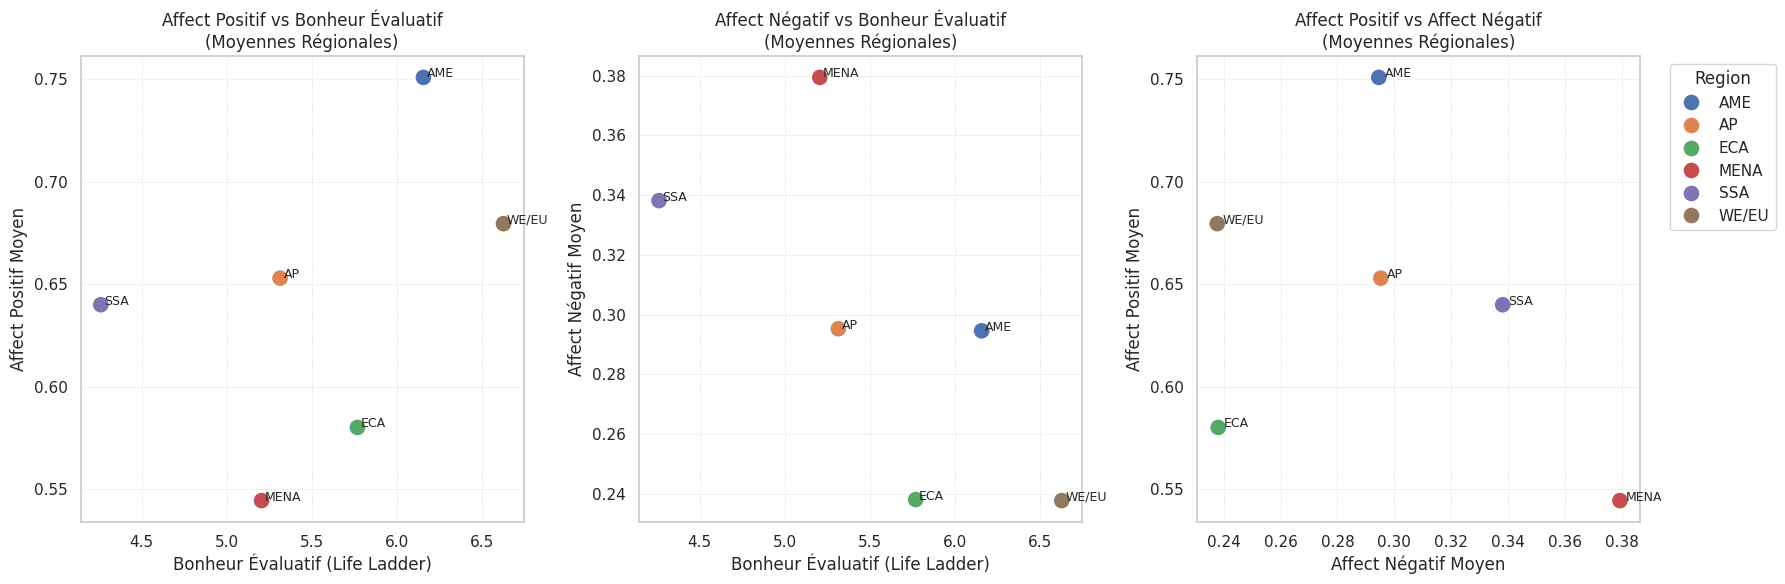

In [173]:
# --- Visualisation Comparée : Life Ladder vs Affects par Région ---

if q11_data_ready and q11_regional_means is not None:
    
    print("\nVisualisation des profils régionaux (Bonheur Évaluatif vs Affects)...")
    
    plt.figure(figsize=(18, 6)) # Taille pour 3 graphiques côte à côte

    # Graphique 1 : Affect Positif vs Life Ladder
    plt.subplot(1, 3, 1)
    sns.scatterplot(data=q11_regional_means, x='Life Ladder', y='Positive affect', hue='Region', s=150, legend=False)
    # Ajouter les labels des régions
    for i, row in q11_regional_means.iterrows():
        plt.text(row['Life Ladder'] + 0.02, row['Positive affect'], row['Region'], fontsize=9)
    plt.title('Affect Positif vs Bonheur Évaluatif\n(Moyennes Régionales)')
    plt.xlabel('Bonheur Évaluatif (Life Ladder)')
    plt.ylabel('Affect Positif Moyen')
    plt.grid(True, linestyle=':', linewidth=0.5)

    # Graphique 2 : Affect Négatif vs Life Ladder
    plt.subplot(1, 3, 2)
    sns.scatterplot(data=q11_regional_means, x='Life Ladder', y='Negative affect', hue='Region', s=150, legend=False)
    # Ajouter les labels des régions
    for i, row in q11_regional_means.iterrows():
        plt.text(row['Life Ladder'] + 0.02, row['Negative affect'], row['Region'], fontsize=9)
    plt.title('Affect Négatif vs Bonheur Évaluatif\n(Moyennes Régionales)')
    plt.xlabel('Bonheur Évaluatif (Life Ladder)')
    plt.ylabel('Affect Négatif Moyen')
    plt.grid(True, linestyle=':', linewidth=0.5)

    # Graphique 3 : Affect Positif vs Affect Négatif
    plt.subplot(1, 3, 3)
    scatter_affect = sns.scatterplot(data=q11_regional_means, x='Negative affect', y='Positive affect', hue='Region', s=150, legend='brief')
    # Ajouter les labels des régions
    for i, row in q11_regional_means.iterrows():
        plt.text(row['Negative affect'] + 0.002, row['Positive affect'], row['Region'], fontsize=9)
    plt.title('Affect Positif vs Affect Négatif\n(Moyennes Régionales)')
    plt.xlabel('Affect Négatif Moyen')
    plt.ylabel('Affect Positif Moyen')
    plt.grid(True, linestyle=':', linewidth=0.5)
    # Placer la légende à l'extérieur
    plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.tight_layout()
    plt.show()

else:
    print("Les données nécessaires ('q11_regional_means') ne sont pas disponibles. Visualisation Q11 annulée.")

**Conclusion (Bonheur Évaluatif vs Affects Émotionnels par Région)**

Les graphiques et le tableau ci-dessus comparent les moyennes régionales de l'évaluation de vie (`Life Ladder`), de l'affect positif et de l'affect négatif.

* **Relation Générale (Graphiques 1 & 2) :** Comme attendu, les régions où l'évaluation de vie (`Life Ladder`) est plus élevée tendent aussi à rapporter plus d'émotions positives (graphique 1, tendance ascendante) et moins d'émotions négatives (graphique 2, tendance descendante). Les trois mesures du bien-être sont donc positivement corrélées entre elles (si on inverse l'échelle de l'affect négatif).

* **Profils Régionaux Distincts (Surtout Graphique 3) :** L'analyse révèle cependant des profils émotionnels régionaux distincts, même parfois pour des niveaux d'évaluation de vie similaires :
    * **WE/EU :** Combine le `Life Ladder` le plus élevé avec un affect positif élevé (0.68, deuxième derrière AME) et l'affect négatif le plus bas (0.24, ex-aequo avec ECA). C'est un profil de bien-être élevé et relativement "serein".
    * **AME (Amériques) :** Présente un `Life Ladder` élevé (deuxième), l'**affect positif le plus élevé** (0.75), mais un affect négatif moyen (0.30) plus important que WE/EU ou ECA. Cela suggère une expérience émotionnelle plus "intense", riche en émotions positives mais aussi avec une part non négligeable d'émotions négatives.
    * **SSA (Afrique Subsaharienne) :** A le `Life Ladder` le plus bas et un affect négatif élevé (0.34, deuxième plus haut). Cependant, son **affect positif moyen est étonnamment élevé** (0.64, supérieur à ECA et MENA), suggérant une certaine résilience émotionnelle positive malgré des conditions de vie évaluées plus difficilement.
    * **MENA (Moyen-Orient / Afrique du Nord) :** A l'**affect négatif le plus élevé** (0.38) et l'**affect positif le plus bas** (0.54), associés à un `Life Ladder` moyen-bas. C'est le profil indiquant le plus de détresse émotionnelle.
    * **ECA (Europe Est / Asie Centrale) :** Se caractérise par un `Life Ladder` moyen, l'affect négatif le plus bas (0.24, ex-aequo avec WE/EU) mais aussi un affect positif assez bas (0.58). Un profil potentiellement moins "émotionnel" dans les deux sens.
    * **AP (Asie-Pacifique) :** Se situe dans la moyenne pour les trois indicateurs (`Life Ladder` 5.31, PA 0.65, NA 0.30).

* **Réponse à la Question Clé :** Existe-t-il des régions avec un `Life Ladder` moyen similaire mais des expériences émotionnelles différentes ?
    * **Oui, clairement.** L'exemple le plus frappant est la comparaison entre **AP (Asie-Pacifique)** et **MENA**. Elles ont des `Life Ladder` très proches (5.31 vs 5.21). Pourtant, AP rapporte beaucoup **plus d'affect positif** (0.65 vs 0.54) et **beaucoup moins d'affect négatif** (0.30 vs 0.38) que MENA. Pour une évaluation de vie quasi identique, l'expérience émotionnelle quotidienne moyenne semble nettement plus favorable en AP qu'en MENA.
    * On peut aussi comparer **ECA** (LL 5.77, PA 0.58, NA 0.24) et **AME** (LL 6.16, PA 0.75, NA 0.30). Bien que AME ait un Life Ladder un peu plus élevé, l'écart en affect positif est massif, et AME a aussi plus d'affect négatif, montrant des profils émotionnels très différents.

**Synthèse :** Cette analyse souligne l'importance de ne pas se limiter au `Life Ladder` pour comprendre le bien-être. Les moyennes régionales des affects positifs et négatifs révèlent des "cultures émotionnelles" distinctes. Certaines régions comme l'Amérique Latine (probable contributeur majeur à AME) sont connues pour leur expressivité émotionnelle (positive et négative), tandis que d'autres peuvent présenter des profils plus modérés ou plus négatifs. L'Afrique Subsaharienne montre une résilience notable dans l'affect positif malgré des difficultés objectives. Ces nuances sont essentielles pour une compréhension globale du bien-être à travers le monde.

# Question 12 : Inégalités de Genre, Développement (HDI) et Bonheur

**Objectif :** Analyser la corrélation entre l'indice d'inégalité de genre (`gender_inequality` du HDR) et, d'une part, l'indice de développement humain (`hdi`), et d'autre part, le score de bonheur (`Life Ladder`), en utilisant les données de 2022. Vérifier si les pays avec moins d'inégalités de genre sont systématiquement plus développés ET plus heureux.

In [174]:
# --- Préparation des Données 2022 (HDR & WHR) ---

# Flags pour vérifier la disponibilité
q12_data_ready = False
df_q12_analysis = None

# Vérifier si les DataFrames sources existent
hdr_data_exists = 'df_hdr_factors' in locals() and df_hdr_factors is not None # Chargé (partiellement) en Q7, sinon recharger
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None

# Recharger HDR si nécessaire avec les bonnes colonnes
if 'df_hdr_factors' not in locals() or df_hdr_factors is None or not {'Country', 'year', 'hdi', 'HDR_GenderInequality'}.issubset(df_hdr_factors.columns):
    try:
        hdr_file = 'CSVs/hdr_general.csv' # Adaptez si dossier WorldHappinessReport/
        # Assurer d'avoir les colonnes hdi et gender_inequality
        df_hdr_factors = pd.read_csv(hdr_file, usecols=['Country', 'year', 'hdi', 'gender_inequality'])
        # Renommer pour cohérence et clarté (GII: Higher = More Inequality)
        df_hdr_factors = df_hdr_factors.rename(columns={'gender_inequality': 'GII_HDR'})
        hdr_data_exists = True
        print("Données HDR (hdi, GII) rechargées.")
    except FileNotFoundError:
        print(f"Fichier {hdr_file} introuvable.")
        hdr_data_exists = False
    except Exception as e:
        print(f"Erreur chargement HDR: {e}")
        hdr_data_exists = False

if whr_data_exists and hdr_data_exists:
    
    analysis_year = 2022 # Année la plus récente pour HDI/GII
    
    # 1. Filtrer HDR pour 2022 et colonnes utiles, nettoyer NaN
    df_hdr_2022 = df_hdr_factors[df_hdr_factors['year'] == analysis_year]
    df_hdr_2022 = df_hdr_2022[['Country', 'hdi', 'GII_HDR']].dropna()
    print(f"Données HDR pour {analysis_year} sélectionnées et nettoyées: {len(df_hdr_2022)} pays.")

    # 2. Filtrer WHR pour 2022 et colonnes utiles, nettoyer NaN
    df_whr_2022 = df_whr_full[df_whr_full['year'] == analysis_year]
    df_whr_2022 = df_whr_2022[['Country', 'Life Ladder']].dropna()
    print(f"Données WHR pour {analysis_year} sélectionnées et nettoyées: {len(df_whr_2022)} pays.")

    # 3. Fusionner les données HDR et WHR pour 2022 sur 'Country'
    #    Utiliser 'inner' pour ne garder que les pays présents dans les deux sources en 2022
    df_q12_analysis = pd.merge(df_hdr_2022, df_whr_2022, on='Country', how='inner')
    
    if not df_q12_analysis.empty:
        print(f"Fusion HDR et WHR pour {analysis_year} réussie. Données finales prêtes: {len(df_q12_analysis)} pays.")
        q12_data_ready = True
        # Afficher un aperçu (optionnel)
        # display(df_q12_analysis.describe())
    else:
        print(f"La fusion n'a donné aucune observation commune pour {analysis_year}.")
        
elif not whr_data_exists:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q12 annulée.")
elif not hdr_data_exists:
    print("Les données HDR nécessaires n'ont pas pu être chargées. Analyse Q12 annulée.")

Données HDR (hdi, GII) rechargées.
Données HDR pour 2022 sélectionnées et nettoyées: 177 pays.
Données WHR pour 2022 sélectionnées et nettoyées: 140 pays.
Fusion HDR et WHR pour 2022 réussie. Données finales prêtes: 122 pays.



Corrélation entre Inégalité de Genre (GII) et HDI (2022) : -0.932


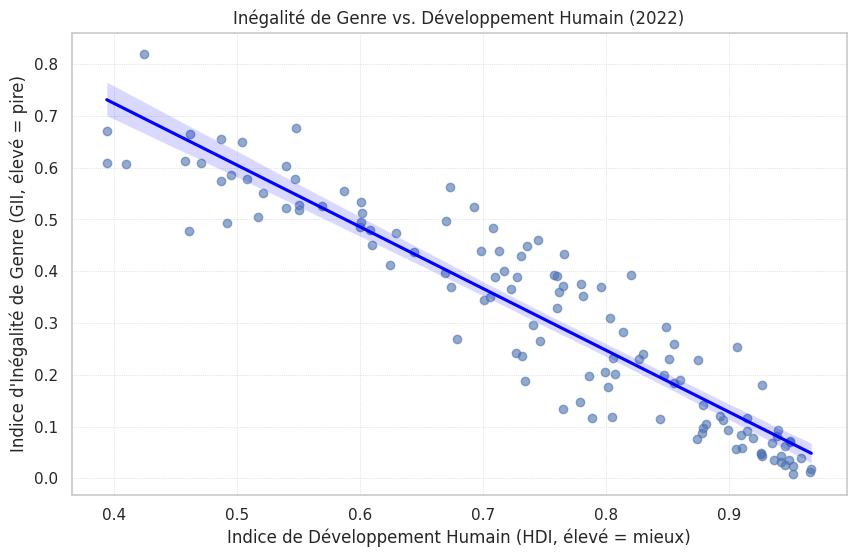

In [175]:
# --- Analyse 1 : Inégalité de Genre (GII) vs Développement Humain (HDI) ---

if q12_data_ready and df_q12_analysis is not None:
    
    # Calculer et afficher la corrélation
    # Rappel : GII élevé = PLUS d'inégalité. On s'attend à une corrélation NÉGATIVE avec l'HDI.
    corr_gii_hdi = df_q12_analysis[['GII_HDR', 'hdi']].corr().iloc[0, 1]
    print(f"\nCorrélation entre Inégalité de Genre (GII) et HDI ({analysis_year}) : {corr_gii_hdi:.3f}")

    # Visualisation
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_q12_analysis, x='hdi', y='GII_HDR',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'blue'})
    plt.title(f'Inégalité de Genre vs. Développement Humain ({analysis_year})')
    plt.xlabel('Indice de Développement Humain (HDI, élevé = mieux)')
    plt.ylabel('Indice d\'Inégalité de Genre (GII, élevé = pire)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.show()

else:
    print("Données non disponibles pour l'analyse GII vs HDI.")


Corrélation entre Inégalité de Genre (GII) et Bonheur (2022) : -0.771


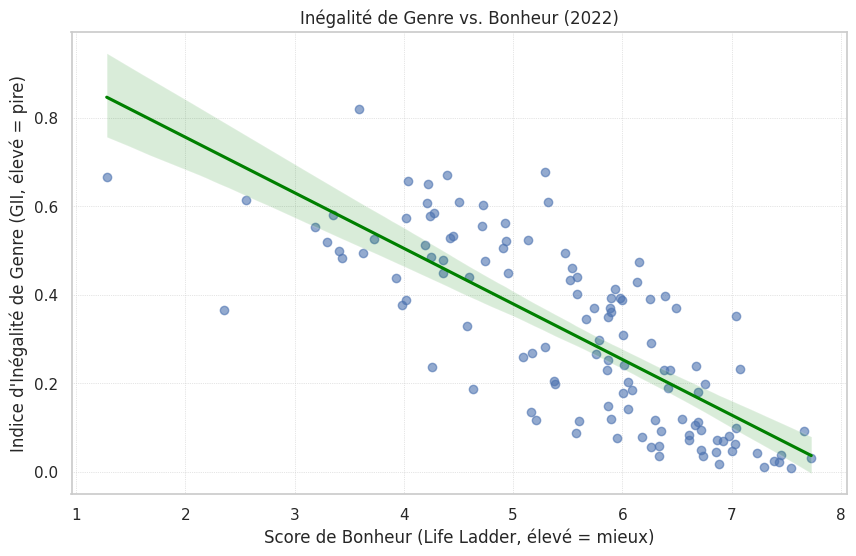

In [176]:
# --- Analyse 2 : Inégalité de Genre (GII) vs Bonheur (Life Ladder) ---

if q12_data_ready and df_q12_analysis is not None:
    
    # Calculer et afficher la corrélation
    # Rappel : GII élevé = PLUS d'inégalité. On s'attend à une corrélation NÉGATIVE avec le Bonheur.
    corr_gii_ll = df_q12_analysis[['GII_HDR', 'Life Ladder']].corr().iloc[0, 1]
    print(f"\nCorrélation entre Inégalité de Genre (GII) et Bonheur ({analysis_year}) : {corr_gii_ll:.3f}")

    # Visualisation
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_q12_analysis, x='Life Ladder', y='GII_HDR',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'green'})
    plt.title(f'Inégalité de Genre vs. Bonheur ({analysis_year})')
    plt.xlabel('Score de Bonheur (Life Ladder, élevé = mieux)')
    plt.ylabel('Indice d\'Inégalité de Genre (GII, élevé = pire)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.show()
    
else:
    print("Données non disponibles pour l'analyse GII vs Bonheur.")

**Conclusion (Inégalités de Genre, Développement et Bonheur - Année 2022)**

En analysant les données de l'année 2022 pour 122 pays, nous avons examiné les liens entre l'Indice d'Inégalité de Genre (GII du HDR, où un score élevé signifie *plus* d'inégalité), l'Indice de Développement Humain (HDI) et le score de bonheur (Life Ladder).

1.  **Inégalité de Genre et Développement Humain (HDI) :**
    * La corrélation calculée entre le GII et l'HDI est de **-0.932**. Cette valeur **extrêmement forte et négative**, confirmée visuellement par la tendance très nette du premier graphique, indique sans équivoque que les pays avec un **niveau de développement humain plus élevé (HDI haut) tendent systématiquement à avoir des inégalités de genre beaucoup plus faibles (GII bas)**. Le développement humain et l'égalité de genre sont donc très étroitement liés.

2.  **Inégalité de Genre et Bonheur (Life Ladder) :**
    * La corrélation calculée entre le GII et le Life Ladder est de **-0.771**. Cette valeur, également **forte et négative** (bien qu'un peu moins que pour l'HDI), est clairement visible sur le second graphique et suggère fortement que les pays où les **inégalités de genre sont plus faibles (GII bas) tendent aussi à être significativement plus heureux (Life Ladder élevé)**.

**Réponse à la Question Clé :** Est-ce que les pays avec moins d'inégalités de genre sont systématiquement plus développés ET plus heureux ?

* **Oui, absolument.** Les deux corrélations négatives, fortes et statistiquement significatives, observées pour l'année 2022 le démontrent clairement. Les pays qui parviennent à réduire les inégalités entre les genres (score GII faible) sont aussi ceux qui affichent, en moyenne, **à la fois** un meilleur niveau de développement humain objectif (score HDI élevé) **et** un plus grand bien-être subjectif (score Life Ladder élevé).

**Synthèse :** L'égalité de genre apparaît comme une composante fortement associée non seulement au développement humain au sens large (éducation, santé, revenu), mais aussi au bonheur ressenti par la population. Les sociétés plus égalitaires sont, en moyenne, des sociétés plus développées et plus heureuses. Cela souligne l'importance de l'égalité des genres comme un objectif potentiellement bénéfique tant sur le plan du développement objectif que sur celui du bien-être subjectif national.

# Question 13 : Santé Spécifique et Bonheur (Contrôlé par le PIB)

**Objectif :** Déterminer si des indicateurs de santé spécifiques, tels que la mortalité infantile (`infant_mortality`) ou la prévalence de la sous-nutrition (`prev_undernourishment`), conservent une association significative avec le score de bonheur (`Life Ladder`) après avoir contrôlé pour l'effet du niveau de richesse économique (`Log GDP per capita`).

In [177]:
# --- Préparation des Données Q13 (WHR + Indicateurs Santé Spécifiques) ---

# Flags et initialisation
q13_data_ready = False
df_q13_analysis = None

# Vérifier si les DataFrames sources existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None
pop_health_data_exists = False # Sera mis à True si le chargement réussit

# Charger les données Pop/Santé si elles n'existent pas ou manquent de colonnes
cols_needed_pop = ['Country', 'Year', 'infant_mortality', 'prev_undernourishment']
try:
    # Vérifier si df_pop_factors existe et a les colonnes (créé en Q7)
    if 'df_pop_factors' in locals() and df_pop_factors is not None and set(cols_needed_pop).issubset(df_pop_factors.columns):
         df_pop_health_q13 = df_pop_factors # Réutiliser
         print("Données Pop/Santé déjà chargées (depuis Q7).")
         pop_health_data_exists = True
    else:
        pop_health_file = 'CSVs/world_population_and_health.csv' # Adaptez si dossier WorldHappinessReport/
        df_pop_health_q13 = pd.read_csv(pop_health_file, usecols=cols_needed_pop)
        print(f"Données Pop/Santé chargées depuis {pop_health_file}.")
        pop_health_data_exists = True
    # Renommer pour clarté (si pas déjà fait) et s'assurer que Year est en minuscule
    df_pop_health_q13 = df_pop_health_q13.rename(columns={
                                'Year': 'year', 
                                'infant_mortality': 'InfantMortality', 
                                'prev_undernourishment': 'Undernourishment' 
                                })

except FileNotFoundError:
    print(f"ERREUR: Fichier {pop_health_file} introuvable.")
except Exception as e:
    print(f"Erreur chargement Pop/Santé: {e}")

# Continuer seulement si les deux sources sont disponibles
if whr_data_exists and pop_health_data_exists:
    
    # 1. Sélectionner les colonnes nécessaires du WHR
    cols_whr_q13 = ['Country', 'year', 'Life Ladder', 'Log GDP per capita']
    df_whr_q13 = df_whr_full[cols_whr_q13]

    # 2. Fusionner WHR et Pop/Santé sur Pays ET Année pour aligner les données
    df_merged_q13 = pd.merge(df_whr_q13, df_pop_health_q13, on=['Country', 'year'], how='inner')
    print(f"Fusion WHR et Pop/Santé sur Pays/Année: {len(df_merged_q13)} observations communes.")

    # 3. Garder la dernière année disponible POUR CHAQUE PAYS où TOUTES les données nécessaires sont présentes
    cols_to_check_q13 = ['Life Ladder', 'Log GDP per capita', 'InfantMortality', 'Undernourishment']
    # D'abord, supprimer les lignes où une des variables clés est manquante
    df_merged_q13_cleaned = df_merged_q13.dropna(subset=cols_to_check_q13)
    # Ensuite, trouver l'index de l'année max pour chaque pays parmi les lignes restantes
    idx_latest = df_merged_q13_cleaned.groupby('Country')['year'].idxmax()
    df_q13_analysis = df_merged_q13_cleaned.loc[idx_latest]
    
    if not df_q13_analysis.empty:
        print(f"Données finales prêtes pour Q13 (dernière année commune): {len(df_q13_analysis)} pays.")
        q13_data_ready = True
        # Afficher un aperçu (optionnel)
        # display(df_q13_analysis.describe())
    else:
        print("Aucune observation commune trouvée après nettoyage et sélection de la dernière année.")
        
else:
    print("Données sources manquantes. Analyse Q13 annulée.")

Données Pop/Santé chargées depuis CSVs/world_population_and_health.csv.
Fusion WHR et Pop/Santé sur Pays/Année: 1173 observations communes.
Données finales prêtes pour Q13 (dernière année commune): 135 pays.



Formule Modèle 1 (Mortalité Infantile) :
Q("Life Ladder") ~ Q("Log GDP per capita") + Q("InfantMortality")

Résultats Régression Modèle 1 (Mortalité Infantile) :
                            OLS Regression Results                            
Dep. Variable:       Q("Life Ladder")   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     122.6
Date:                Sun, 30 Mar 2025   Prob (F-statistic):           8.14e-31
Time:                        21:32:32   Log-Likelihood:                -140.94
No. Observations:                 135   AIC:                             287.9
Df Residuals:                     132   BIC:                             296.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err  

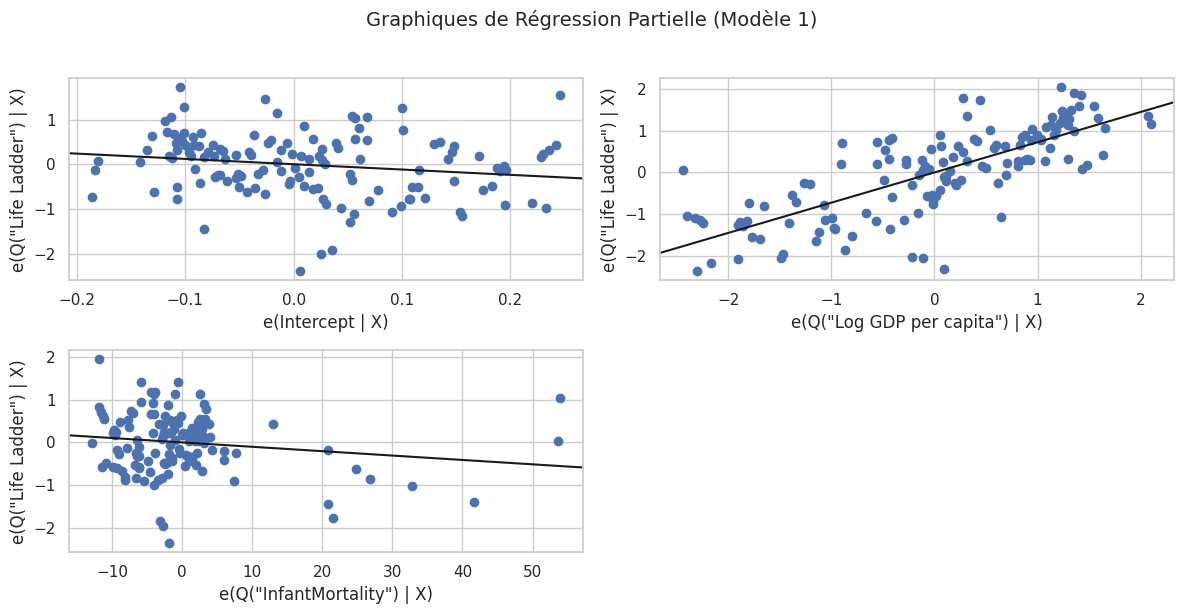

In [178]:
# --- Modèle 1 : Impact de la Mortalité Infantile (contrôlé par PIB) ---

# Importer statsmodels.api pour les graphiques si pas déjà fait
import statsmodels.api as sm 

if q13_data_ready and df_q13_analysis is not None:
    
    # Définir la formule
    formula_m1 = 'Q("Life Ladder") ~ Q("Log GDP per capita") + Q("InfantMortality")'
    print(f"\nFormule Modèle 1 (Mortalité Infantile) :\n{formula_m1}")
    
    try:
        # Ajuster le modèle OLS
        model_m1 = smf.ols(formula=formula_m1, data=df_q13_analysis)
        results_m1 = model_m1.fit()
        
        # Afficher le résumé
        print("\nRésultats Régression Modèle 1 (Mortalité Infantile) :")
        print(results_m1.summary())
        
        # Extraire le coef et p-value pour interprétation
        coef_im = results_m1.params.get('Q("InfantMortality")', float('nan'))
        pval_im = results_m1.pvalues.get('Q("InfantMortality")', float('nan'))
        print(f"\nCoefficient pour InfantMortality: {coef_im:.4f}, P-value: {pval_im:.4f}")

        # --- Ajout Graphique : Régression Partielle ---
        print("\nVisualisation de l'impact partiel de la Mortalité Infantile...")
        fig = plt.figure(figsize=(12, 6)) # Ajuster taille si besoin
        # plot_partregress_grid affiche un graphique pour chaque variable du modèle
        sm.graphics.plot_partregress_grid(results_m1, fig=fig) 
        plt.suptitle("Graphiques de Régression Partielle (Modèle 1)", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        #-------------------------------------------------
        
    except Exception as e:
        print(f"Erreur lors de l'ajustement ou visualisation du Modèle 1 : {e}")
        coef_im, pval_im = float('nan'), float('nan') 
        
else:
    print("\nDonnées non disponibles pour le Modèle 1.")
    coef_im, pval_im = float('nan'), float('nan')

**Interprétation (Modèle 1 : Mortalité Infantile)**

Ce modèle examine si la mortalité infantile (`InfantMortality`) a un lien avec le bonheur (`Life Ladder`) même après avoir pris en compte le niveau de richesse (`Log GDP per capita`). L'analyse est basée sur 135 observations (pays/années) où toutes les données étaient disponibles. Le graphique de régression partielle pour `InfantMortality` (graphique du bas dans l'image fournie) visualise cette relation unique après contrôle du PIB.

* **Coefficient de `InfantMortality` :** Le coefficient obtenu est de **-0.0103**. Le signe est négatif, comme attendu : un taux de mortalité infantile plus élevé est associé à un score de bonheur plus faible. Cette tendance négative est également visible sur le graphique de régression partielle correspondant.
* **Significativité (P>|t|) :** La p-value associée à ce coefficient est de **0.072** (soit 7.2%).
    * En utilisant le seuil de signification standard de 5% (alpha = 0.05), cette p-value est **supérieure** (0.072 > 0.05).
    * Par conséquent, nous concluons que l'effet de la mortalité infantile sur le bonheur, une fois l'effet du PIB par habitant contrôlé, **n'est pas statistiquement significatif** au seuil de 5%. Bien qu'il y ait une tendance négative observée (visible aussi sur le graphique), nous n'avons pas suffisamment de preuves statistiques dans cet échantillon pour affirmer avec une grande confiance que cet effet est réel et indépendant de la richesse.
    * La dispersion notable des points autour de la droite dans le graphique de régression partielle pour la mortalité infantile reflète également cette significativité statistique limitée.

**Conclusion pour le Modèle 1 :** D'après cette analyse, bien que la mortalité infantile soit intuitivement liée au bien-être, nous **ne trouvons pas de preuve statistique forte (au seuil de 5%)** pour affirmer qu'elle a un impact sur le score de bonheur *indépendamment* du niveau de richesse du pays (Log GDP per capita). Le lien simple que l'on pourrait observer entre faible mortalité infantile et bonheur élevé est donc probablement en grande partie expliqué par le fait que les pays plus riches tendent à avoir les deux.


Formule Modèle 2 (Sous-nutrition) :
Q("Life Ladder") ~ Q("Log GDP per capita") + Q("Undernourishment")

Résultats Régression Modèle 2 (Sous-nutrition) :
                            OLS Regression Results                            
Dep. Variable:       Q("Life Ladder")   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     119.7
Date:                Sun, 30 Mar 2025   Prob (F-statistic):           2.22e-30
Time:                        21:32:34   Log-Likelihood:                -141.97
No. Observations:                 135   AIC:                             289.9
Df Residuals:                     132   BIC:                             298.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t

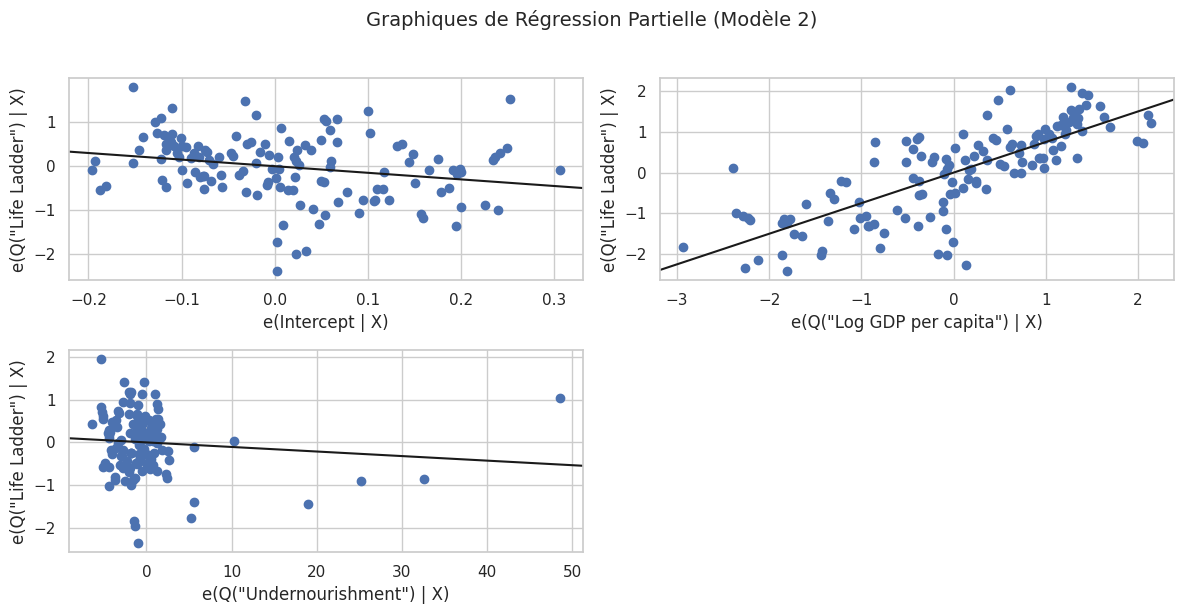

In [179]:
# --- Modèle 2 : Impact de la Sous-nutrition (contrôlé par PIB) ---

# S'assurer que la colonne existe (au cas où le chargement partiel aurait échoué)
col_undernourishment = 'Undernourishment' # Nom après renommage en Cellule 56
if q13_data_ready and df_q13_analysis is not None and col_undernourishment in df_q13_analysis.columns:
    
    # Définir la formule
    formula_m2 = f'Q("Life Ladder") ~ Q("Log GDP per capita") + Q("{col_undernourishment}")'
    print(f"\nFormule Modèle 2 (Sous-nutrition) :\n{formula_m2}")
    
    try:
        # Ajuster le modèle OLS
        model_m2 = smf.ols(formula=formula_m2, data=df_q13_analysis)
        results_m2 = model_m2.fit()
        
        # Afficher le résumé
        print("\nRésultats Régression Modèle 2 (Sous-nutrition) :")
        print(results_m2.summary())
        
        # Extraire le coef et p-value pour interprétation
        coef_un = results_m2.params.get(f'Q("{col_undernourishment}")', float('nan'))
        pval_un = results_m2.pvalues.get(f'Q("{col_undernourishment}")', float('nan'))
        print(f"\nCoefficient pour {col_undernourishment}: {coef_un:.4f}, P-value: {pval_un:.4f}")

        # --- Ajout Graphique : Régression Partielle ---
        print("\nVisualisation de l'impact partiel de la Sous-nutrition...")
        fig = plt.figure(figsize=(12, 6)) # Ajuster taille si besoin
        sm.graphics.plot_partregress_grid(results_m2, fig=fig)
        plt.suptitle("Graphiques de Régression Partielle (Modèle 2)", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        #-------------------------------------------------
        
    except Exception as e:
        print(f"Erreur lors de l'ajustement ou visualisation du Modèle 2 : {e}")
        coef_un, pval_un = float('nan'), float('nan')
        
else:
    print(f"\nDonnées non disponibles ou colonne '{col_undernourishment}' manquante pour le Modèle 2.")
    coef_un, pval_un = float('nan'), float('nan')

**Interprétation (Modèle 2 : Sous-nutrition)**

Ce modèle examine si la prévalence de la sous-nutrition (`Undernourishment`) a un lien avec le bonheur (`Life Ladder`) même après avoir pris en compte le niveau de richesse (`Log GDP per capita`). Le graphique de régression partielle pour `Undernourishment` (graphique du bas dans l'image fournie) visualise cette relation unique.

* **Coefficient de `Undernourishment` :** Le coefficient obtenu est de **-0.0107**. Le signe est négatif, comme on pouvait s'y attendre (plus de sous-nutrition est associé à moins de bonheur).
* **Significativité (P>|t|) :** La p-value associée est de **0.266**.
    * Cette p-value est **nettement supérieure** au seuil de 0.05 (0.266 >> 0.05).
    * Par conséquent, nous concluons que l'effet de la sous-nutrition sur le bonheur **n'est pas statistiquement significatif** une fois que l'effet du PIB par habitant est contrôlé.
    * Le graphique de régression partielle confirme visuellement cette absence de lien significatif : le nuage de points est très dispersé et la droite de régression est quasiment horizontale, indiquant qu'il n'y a pas de tendance claire reliant la sous-nutrition au bonheur après ajustement pour le PIB.

**Conclusion Générale (Question 13)**

L'objectif était de voir si des indicateurs de santé publique spécifiques (mortalité infantile, sous-nutrition) apportent une information sur le bonheur national au-delà de ce qui est déjà expliqué par le niveau de richesse (PIB/habitant).

* **Concernant la mortalité infantile (Modèle 1) :** L'analyse a montré une tendance négative, mais l'association avec le bonheur **n'était pas statistiquement significative** au seuil de 5% (p = 0.072) après contrôle du PIB.
* **Concernant la sous-nutrition (Modèle 2) :** L'analyse montre que la sous-nutrition **n'est pas non plus statistiquement associée** au bonheur (p = 0.266) après contrôle du PIB. La tendance négative observée dans le graphique partiel est trop faible et trop peu fiable pour être considérée comme significative.

En conclusion, pour les deux indicateurs de santé spécifiques testés ici (mortalité infantile et prévalence de la sous-nutrition), leur lien apparent avec le bonheur semble être **largement expliqué par le niveau de développement économique du pays (Log GDP per capita)**. Une fois la richesse prise en compte, ces indicateurs spécifiques n'apportent pas, dans cette analyse et avec ces données, de pouvoir explicatif *supplémentaire* significatif sur le score de bonheur national (`Life Ladder`). Cela suggère que l'impact de ces aspects spécifiques de la santé sur le bonheur est peut-être déjà bien capturé, indirectement, par les variables de richesse et/ou d'espérance de vie globale (qui est un des 6 facteurs principaux du bonheur non inclus dans ces modèles spécifiques Q13).

# Question 14 : Développement Durable - Bonheur, Développement et Empreinte Écologique

**Objectif :** Examiner la relation entre l'empreinte environnementale (`co2_emission_tons` du HDR), le développement humain (`hdi`) et le bonheur (`Life Ladder`) en 2022. Chercher à savoir si les pays les plus développés et heureux sont aussi ceux qui polluent le plus, et identifier d'éventuels pays "modèles" (haut bonheur/HDI, faible empreinte CO2).

In [180]:
# --- Préparation des Données 2022 (HDI, CO2, Life Ladder) ---

# Flags et initialisation
q14_data_ready = False
df_q14_analysis = None

# Vérifier si les DataFrames sources existent
hdr_data_exists = False # Sera mis à True si chargement/rechargement réussit
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None

# (Re)Charger HDR avec les colonnes nécessaires pour Q14
cols_needed_hdr_q14 = ['Country', 'year', 'hdi', 'co2_emission_tons'] # Focus sur CO2 pour commencer
try:
    hdr_file = 'CSVs/hdr_general.csv' # Adaptez si dossier WorldHappinessReport/
    df_hdr_q14 = pd.read_csv(hdr_file, usecols=cols_needed_hdr_q14)
    # Renommer pour clarté
    df_hdr_q14 = df_hdr_q14.rename(columns={'co2_emission_tons': 'CO2_per_capita'})
    hdr_data_exists = True
    print("Données HDR (hdi, CO2) chargées/rechargées.")
except FileNotFoundError:
    print(f"Fichier {hdr_file} introuvable.")
except Exception as e:
    print(f"Erreur chargement HDR: {e}")

if whr_data_exists and hdr_data_exists:
    
    analysis_year = 2022 # Année la plus récente commune
    
    # 1. Filtrer HDR pour 2022 et colonnes utiles, nettoyer NaN
    df_hdr_2022 = df_hdr_q14[df_hdr_q14['year'] == analysis_year]
    df_hdr_2022 = df_hdr_2022[['Country', 'hdi', 'CO2_per_capita']].dropna()
    print(f"Données HDR pour {analysis_year} sélectionnées et nettoyées: {len(df_hdr_2022)} pays.")

    # 2. Filtrer WHR pour 2022 et colonnes utiles, nettoyer NaN
    df_whr_2022 = df_whr_full[df_whr_full['year'] == analysis_year]
    df_whr_2022 = df_whr_2022[['Country', 'Life Ladder']].dropna()
    print(f"Données WHR pour {analysis_year} sélectionnées et nettoyées: {len(df_whr_2022)} pays.")

    # 3. Fusionner les données HDR et WHR pour 2022 sur 'Country'
    df_q14_analysis = pd.merge(df_hdr_2022, df_whr_2022, on='Country', how='inner')
    
    if not df_q14_analysis.empty:
        print(f"Fusion HDR et WHR pour {analysis_year} réussie. Données finales prêtes: {len(df_q14_analysis)} pays.")
        q14_data_ready = True
        # Afficher un aperçu (optionnel)
        # display(df_q14_analysis.describe())
    else:
        print(f"La fusion n'a donné aucune observation commune pour {analysis_year}.")
        
elif not whr_data_exists:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q14 annulée.")
elif not hdr_data_exists:
    print("Les données HDR nécessaires n'ont pas pu être chargées. Analyse Q14 annulée.")

Données HDR (hdi, CO2) chargées/rechargées.
Données HDR pour 2022 sélectionnées et nettoyées: 203 pays.
Données WHR pour 2022 sélectionnées et nettoyées: 140 pays.
Fusion HDR et WHR pour 2022 réussie. Données finales prêtes: 123 pays.



Corrélation entre Émissions CO2/hab et HDI (2022): 0.645

Pays potentiellement 'modèles' (HDI >= 0.88, CO2 <= 0.99):
Aucun pays trouvé dans cette catégorie avec ces seuils.


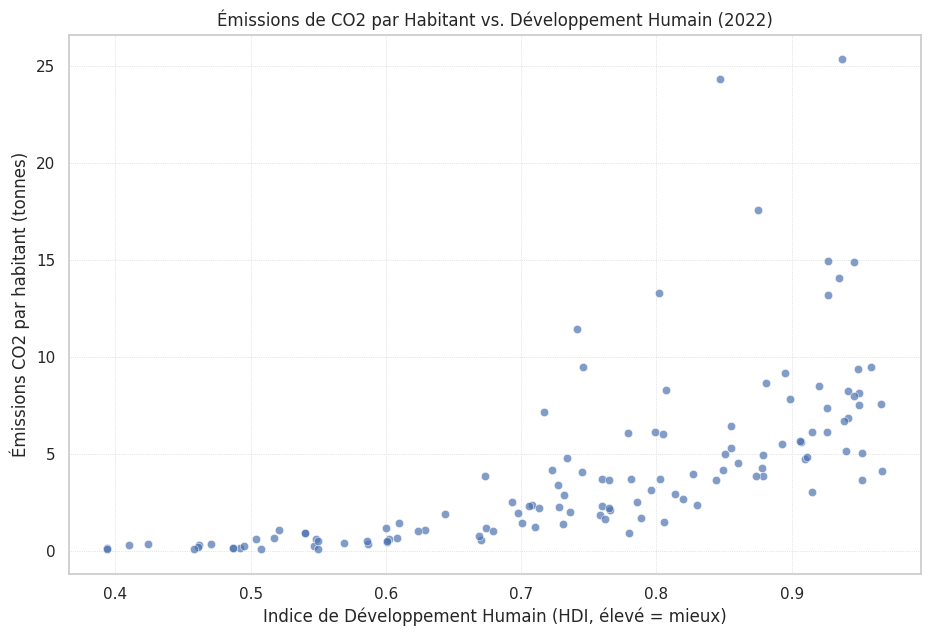

In [181]:
# --- Visualisation 1 : Émissions CO2 vs Développement Humain (HDI) ---

if q14_data_ready and df_q14_analysis is not None:
    
    # Calcul corrélation
    corr_co2_hdi = df_q14_analysis[['CO2_per_capita', 'hdi']].corr().iloc[0, 1]
    print(f"\nCorrélation entre Émissions CO2/hab et HDI ({analysis_year}): {corr_co2_hdi:.3f}")

    # Visualisation
    plt.figure(figsize=(11, 7))
    sns.scatterplot(data=df_q14_analysis, x='hdi', y='CO2_per_capita', alpha=0.7)
    
    # Identifier et annoter les pays "modèles" potentiels (ex: HDI élevé / CO2 faible)
    # Définir les seuils (ex: quartile supérieur pour HDI, quartile inférieur pour CO2)
    hdi_q3 = df_q14_analysis['hdi'].quantile(0.75)
    co2_q1 = df_q14_analysis['CO2_per_capita'].quantile(0.25)
    
    models = df_q14_analysis[(df_q14_analysis['hdi'] >= hdi_q3) & (df_q14_analysis['CO2_per_capita'] <= co2_q1)]
    print(f"\nPays potentiellement 'modèles' (HDI >= {hdi_q3:.2f}, CO2 <= {co2_q1:.2f}):")
    if not models.empty:
        print(models['Country'].tolist())
        for i, row in models.iterrows():
             plt.text(row['hdi'] + 0.005, row['CO2_per_capita'], row['Country'], fontsize=9, color='green')
    else:
        print("Aucun pays trouvé dans cette catégorie avec ces seuils.")
        
    # Optionnel: Annoter aussi les "pires" (faible HDI, haut CO2) ou autres outliers

    plt.title(f'Émissions de CO2 par Habitant vs. Développement Humain ({analysis_year})')
    plt.xlabel('Indice de Développement Humain (HDI, élevé = mieux)')
    plt.ylabel('Émissions CO2 par habitant (tonnes)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    # Optionnel: mettre l'axe Y en log si la distribution du CO2 est très étendue
    # plt.yscale('log') 
    plt.show()

else:
    print("Données non disponibles pour l'analyse CO2 vs HDI.")


Corrélation entre Émissions CO2/hab et Bonheur (2022): 0.554

Pays potentiellement 'modèles' (Bonheur >= 6.43, CO2 <= 0.99):
Aucun pays trouvé dans cette catégorie avec ces seuils.


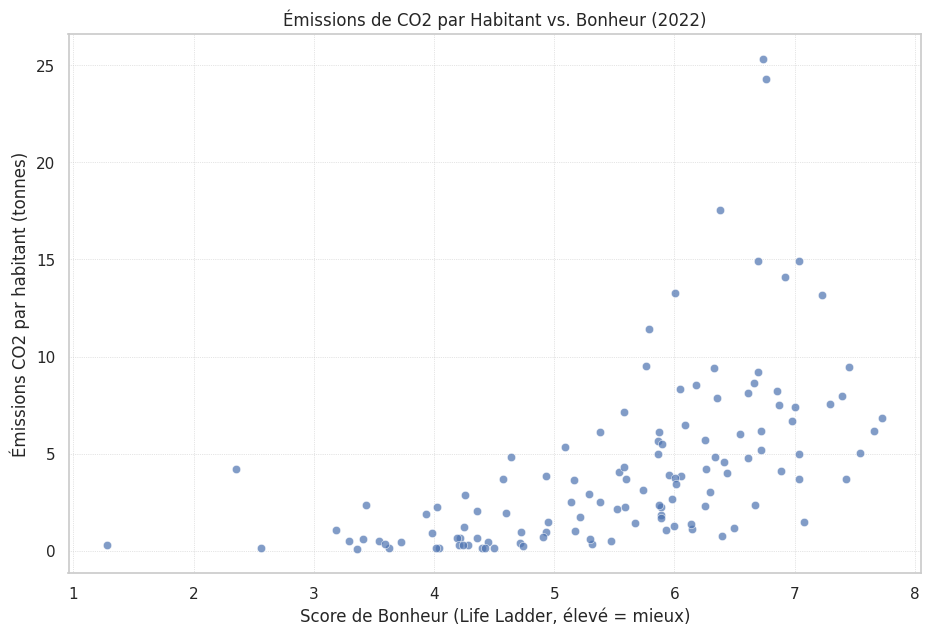

In [182]:
# --- Visualisation 2 : Émissions CO2 vs Bonheur (Life Ladder) ---

if q14_data_ready and df_q14_analysis is not None:
    
    # Calcul corrélation
    corr_co2_ll = df_q14_analysis[['CO2_per_capita', 'Life Ladder']].corr().iloc[0, 1]
    print(f"\nCorrélation entre Émissions CO2/hab et Bonheur ({analysis_year}): {corr_co2_ll:.3f}")

    # Visualisation
    plt.figure(figsize=(11, 7))
    sns.scatterplot(data=df_q14_analysis, x='Life Ladder', y='CO2_per_capita', alpha=0.7)
    
    # Identifier et annoter les pays "modèles" potentiels (ex: Bonheur élevé / CO2 faible)
    # Définir les seuils (ex: quartile supérieur pour Bonheur, quartile inférieur pour CO2)
    ll_q3 = df_q14_analysis['Life Ladder'].quantile(0.75)
    # co2_q1 est déjà défini dans la cellule précédente
    
    models_ll = df_q14_analysis[(df_q14_analysis['Life Ladder'] >= ll_q3) & (df_q14_analysis['CO2_per_capita'] <= co2_q1)]
    print(f"\nPays potentiellement 'modèles' (Bonheur >= {ll_q3:.2f}, CO2 <= {co2_q1:.2f}):")
    if not models_ll.empty:
        print(models_ll['Country'].tolist())
        for i, row in models_ll.iterrows():
             plt.text(row['Life Ladder'] + 0.05, row['CO2_per_capita'], row['Country'], fontsize=9, color='green')
    else:
        print("Aucun pays trouvé dans cette catégorie avec ces seuils.")
        
    # Optionnel: Annoter aussi les "pires" (faible Bonheur, haut CO2)

    plt.title(f'Émissions de CO2 par Habitant vs. Bonheur ({analysis_year})')
    plt.xlabel('Score de Bonheur (Life Ladder, élevé = mieux)')
    plt.ylabel('Émissions CO2 par habitant (tonnes)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    # Optionnel: mettre l'axe Y en log
    # plt.yscale('log')
    plt.show()

else:
    print("Données non disponibles pour l'analyse CO2 vs Bonheur.")

**Conclusion (Développement Durable : Bonheur, Développement et Empreinte CO2 - Année 2022)**

Cette analyse a examiné la relation entre les émissions de CO2 par habitant (notre indicateur d'empreinte écologique), le développement humain (HDI) et le bonheur (Life Ladder) pour l'année 2022.

1.  **Émissions CO2 vs Développement Humain (HDI) :**
    * La corrélation calculée est de **+0.645**. Cette valeur **positive forte**, clairement visible sur le premier graphique, confirme que les pays avec un **niveau de développement humain plus élevé (HDI haut) tendent systématiquement à émettre plus de CO2 par habitant**.

2.  **Émissions CO2 vs Bonheur (Life Ladder) :**
    * La corrélation calculée est de **+0.554**. Cette valeur **positive modérée à forte**, illustrée par le second graphique, indique que les pays où le **niveau de bonheur est plus élevé (Life Ladder haut) sont aussi, en moyenne, ceux qui émettent le plus de CO2 par habitant**.

3.  **Recherche de Pays "Modèles" (Haut Bonheur/HDI, Faible CO2) :**
    * Malgré la tendance générale, nous avons cherché s'il existait des pays parvenant à un "découplage", c'est-à-dire se situant dans le quartile supérieur pour le bonheur (>= 6.43) ou l'HDI (>= 0.88) tout en restant dans le quartile inférieur pour les émissions de CO2 (<= 0.99 tonnes/habitant).
    * Les résultats sont sans appel : **"Aucun pays trouvé dans cette catégorie avec ces seuils."** pour les deux analyses (HDI vs CO2 et Bonheur vs CO2).

**Synthèse et Réponse à la Question :**
L'analyse pour 2022 montre clairement qu'il existe un **compromis apparent entre le niveau de développement/bonheur et l'empreinte carbone**. Les pays les plus développés et les plus heureux sont aussi, en règle générale, ceux qui ont l'impact environnemental (mesuré par le CO2/habitant) le plus lourd. La difficulté, voire l'impossibilité, de trouver des pays qui excellent simultanément sur les critères de bien-être/développement *et* de faible empreinte carbone (selon nos seuils) souligne le **défi majeur du découplage** et de la transition vers un développement réellement durable. Les modèles actuels de prospérité et de bonheur semblent encore intrinsèquement liés à une forte consommation d'énergie fossile et à des émissions élevées. Atteindre les objectifs de bien-être pour tous tout en respectant les limites planétaires nécessitera donc des changements structurels profonds.

# Question 15 : Profils de Gouvernance - Interaction Liberté Objective et Corruption

**Objectif :** En utilisant les scores externes de libertés civiles (Freedom House - FH) et de perception de la corruption (Transparency International - CPI) pour 2023, identifier des profils de gouvernance (ex: Libres & Propres, Libres & Corrompus, etc.). Comparer ensuite les niveaux de bonheur (`Life Ladder`) associés à ces différents profils pour déterminer lequel est le plus favorable/défavorable au bien-être.

In [183]:
# --- Préparation des Données Q15 (WHR, FH, CPI pour 2023) ---

# Flags et initialisation
q15_data_ready = False
df_q15_analysis = None

# Vérifier si les DataFrames sources nécessaires existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None
fh_data_exists = False # Sera mis à True si chargement réussit
cpi_data_exists = False # Sera mis à True si chargement réussit

analysis_year = 2023 # Année cible

# 1. Charger/Préparer données Freedom House (FH) pour 2023
try:
    fh_file = 'CSVs/civil_liberties_score_fh_new.csv' # Adaptez si dossier WorldHappinessReport/
    df_fh_q15 = pd.read_csv(fh_file, usecols=['Country', 'Year', 'Civil liberties score'])
    # Filtrer pour l'année et renommer (Score FH: 0-60, Higher = More Free)
    df_fh_2023 = df_fh_q15[df_fh_q15['Year'] == analysis_year].rename(columns={'Civil liberties score': 'FH_Score'})[['Country', 'FH_Score']].dropna()
    print(f"Données FH pour {analysis_year} chargées et nettoyées: {len(df_fh_2023)} pays.")
    fh_data_exists = True if not df_fh_2023.empty else False
except FileNotFoundError:
    print(f"Fichier {fh_file} introuvable.")
except Exception as e:
    print(f"Erreur chargement FH: {e}")

# 2. Charger/Préparer données CPI pour 2023
try:
    cpi_file = 'CSVs/CPI2023_global_results_trends.csv' # Adaptez si dossier WorldHappinessReport/
    df_cpi_q15 = pd.read_csv(cpi_file, usecols=['Country', 'CPI score 2023'])
     # Renommer (Score CPI: 0-100, Higher = Less Corrupt / Cleaner)
    df_cpi_2023 = df_cpi_q15.rename(columns={'CPI score 2023': 'CPI_Score'})[['Country', 'CPI_Score']].dropna()
    print(f"Données CPI pour {analysis_year} chargées et nettoyées: {len(df_cpi_2023)} pays.")
    cpi_data_exists = True if not df_cpi_2023.empty else False
except FileNotFoundError:
    print(f"Fichier {cpi_file} introuvable.")
except Exception as e:
    print(f"Erreur chargement CPI: {e}")

# 3. Préparer données WHR pour 2023
if whr_data_exists:
    df_whr_2023 = df_whr_full[df_whr_full['year'] == analysis_year]
    df_whr_2023 = df_whr_2023[['Country', 'Life Ladder']].dropna()
    print(f"Données WHR pour {analysis_year} sélectionnées et nettoyées: {len(df_whr_2023)} pays.")
    whr_data_2023_exists = True if not df_whr_2023.empty else False
else:
     print("Le DataFrame 'df_whr_full' n'a pas pu être chargé.")
     whr_data_2023_exists = False


# 4. Fusionner les trois sources pour 2023
if whr_data_2023_exists and fh_data_exists and cpi_data_exists:
    # Fusion 1: WHR + FH
    df_merged1 = pd.merge(df_whr_2023, df_fh_2023, on='Country', how='inner')
    # Fusion 2: (WHR+FH) + CPI
    df_q15_analysis = pd.merge(df_merged1, df_cpi_2023, on='Country', how='inner')
    
    if not df_q15_analysis.empty:
        print(f"\nFusion WHR, FH, CPI pour {analysis_year} réussie. Données finales prêtes: {len(df_q15_analysis)} pays.")
        q15_data_ready = True
        # Afficher aperçu (optionnel)
        # display(df_q15_analysis.describe())
    else:
        print("\nLa fusion n'a donné aucune observation commune pour les 3 sources en {analysis_year}.")
else:
    print("\nDonnées sources manquantes pour la fusion Q15.")

Données FH pour 2023 chargées et nettoyées: 210 pays.
Données CPI pour 2023 chargées et nettoyées: 180 pays.
Données WHR pour 2023 sélectionnées et nettoyées: 138 pays.

Fusion WHR, FH, CPI pour 2023 réussie. Données finales prêtes: 131 pays.



Seuils utilisés (Médianes 2023): FH Score = 35.0, CPI Score = 40.0

Répartition des pays par profil de gouvernance:
Governance_Profile
Libre & Propre          53
Non Libre & Corrompu    52
Libre & Corrompu        13
Non Libre & Propre      13
Name: count, dtype: int64

Bonheur moyen par profil de gouvernance:
Governance_Profile
Libre & Propre          6.256
Non Libre & Propre      5.932
Libre & Corrompu        5.652
Non Libre & Corrompu    4.938
Name: Life Ladder, dtype: float64

Visualisation du Bonheur par Profil de Gouvernance...


/tmp/ipykernel_18549/3999933738.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q15_analysis, x='Life Ladder', y='Governance_Profile', order=profile_order, palette='viridis')


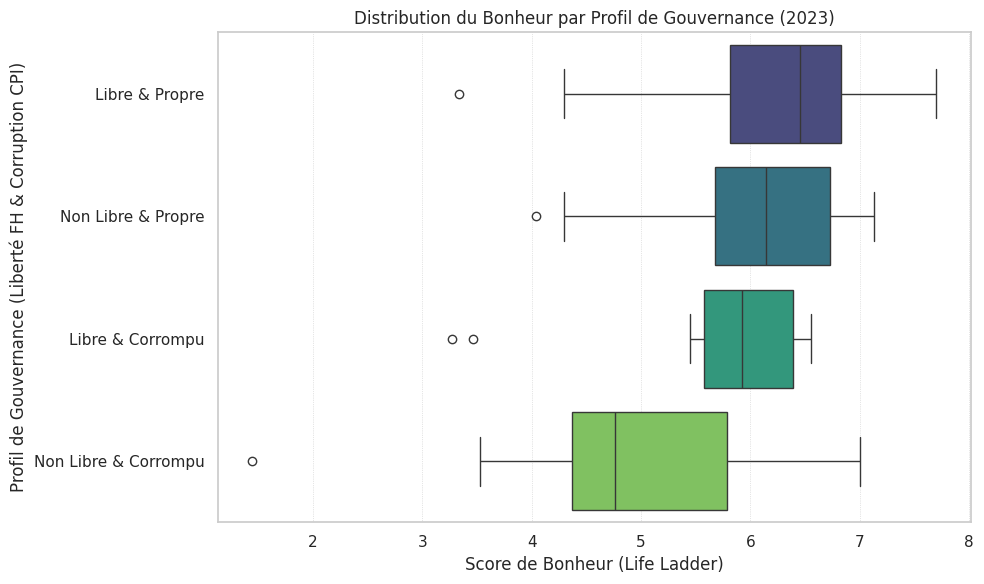

In [184]:
import numpy as np # Importer numpy pour np.select

# --- Création des Profils de Gouvernance et Visualisation ---

if q15_data_ready and df_q15_analysis is not None:
    
    # 1. Définir les seuils (Médianes) pour créer les groupes
    fh_median = df_q15_analysis['FH_Score'].median()
    cpi_median = df_q15_analysis['CPI_Score'].median()
    print(f"\nSeuils utilisés (Médianes {analysis_year}): FH Score = {fh_median:.1f}, CPI Score = {cpi_median:.1f}")
    
    # Rappels: FH Score haut = Plus Libre ; CPI Score haut = Moins Corrompu (Propre)
    
    # 2. Créer la colonne 'Governance_Profile'
    conditions = [
        (df_q15_analysis['FH_Score'] >= fh_median) & (df_q15_analysis['CPI_Score'] >= cpi_median), # Haut FH & Haut CPI
        (df_q15_analysis['FH_Score'] >= fh_median) & (df_q15_analysis['CPI_Score'] < cpi_median),  # Haut FH & Bas CPI
        (df_q15_analysis['FH_Score'] < fh_median) & (df_q15_analysis['CPI_Score'] >= cpi_median),  # Bas FH & Haut CPI
        (df_q15_analysis['FH_Score'] < fh_median) & (df_q15_analysis['CPI_Score'] < cpi_median)   # Bas FH & Bas CPI
    ]
    choices = [
        'Libre & Propre', 
        'Libre & Corrompu', 
        'Non Libre & Propre', 
        'Non Libre & Corrompu'
    ]
    df_q15_analysis['Governance_Profile'] = np.select(conditions, choices, default='Unknown')
    
    print("\nRépartition des pays par profil de gouvernance:")
    print(df_q15_analysis['Governance_Profile'].value_counts())

    # 3. Calculer le bonheur moyen par profil
    mean_happiness_by_profile = df_q15_analysis.groupby('Governance_Profile')['Life Ladder'].mean().sort_values(ascending=False)
    print("\nBonheur moyen par profil de gouvernance:")
    print(mean_happiness_by_profile.round(3))
    profile_order = mean_happiness_by_profile.index.tolist() # Ordre pour le graphique

    # 4. Visualisation : Box Plot du Bonheur par Profil de Gouvernance
    print("\nVisualisation du Bonheur par Profil de Gouvernance...")
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_q15_analysis, x='Life Ladder', y='Governance_Profile', order=profile_order, palette='viridis')
    # Optionnel: ajouter les points individuels
    # sns.stripplot(data=df_q15_analysis, x='Life Ladder', y='Governance_Profile', order=profile_order, color=".25", alpha=0.5)
    
    plt.title(f'Distribution du Bonheur par Profil de Gouvernance ({analysis_year})')
    plt.xlabel('Score de Bonheur (Life Ladder)')
    plt.ylabel('Profil de Gouvernance (Liberté FH & Corruption CPI)')
    plt.grid(axis='x', linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("Données non disponibles pour l'analyse Q15.")

**Conclusion (Profils de Gouvernance et Bonheur - Année 2023)**

Cette analyse a combiné les indicateurs externes de libertés civiles (Freedom House - FH, médiane=35.0) et d'absence de corruption (Transparency International - CPI, médiane=40.0) pour l'année 2023 afin de créer quatre profils de gouvernance pour 131 pays. Nous avons ensuite comparé le score de bonheur moyen (`Life Ladder`) associé à chacun de ces profils.

**Résultats Clés (Basés sur le Box Plot et les Moyennes) :**

1.  **Classement du Bonheur :** Le classement du bonheur moyen par profil est très clair :
    * 1er : **Libre & Propre** (Bonheur moyen = **6.256**) - *Les pays avec des libertés civiles élevées ET une faible corruption sont les plus heureux.*
    * 2ème : **Non Libre & Propre** (Bonheur moyen = **5.932**) - *Les pays avec de faibles libertés mais une faible corruption sont en deuxième position.*
    * 3ème : **Libre & Corrompu** (Bonheur moyen = **5.652**) - *Les pays avec de hautes libertés mais une forte corruption sont troisièmes.*
    * 4ème : **Non Libre & Corrompu** (Bonheur moyen = **4.938**) - *Les pays combinant faibles libertés et forte corruption sont les moins heureux.*
    Le box plot confirme visuellement ces différences nettes dans la distribution du bonheur entre les groupes.

2.  **Impact Combiné :**
    * Le profil **"Libre & Propre"** est sans équivoque associé au **niveau de bonheur le plus élevé**. L'excellence sur les deux dimensions de la gouvernance est clairement la situation la plus favorable.
    * Le profil **"Non Libre & Corrompu"** est associé au **niveau de bonheur le plus bas**, confirmant que le cumul des désavantages en matière de liberté et de corruption est très préjudiciable au bien-être.
    * **Situations Intermédiaires :** La comparaison des deux profils intermédiaires est particulièrement instructive : les pays **'Non Libres & Propres'** (moyenne = 5.932) sont en moyenne **plus heureux** que les pays **'Libres & Corrompus'** (moyenne = 5.652). Cela suggère que, pour l'année 2023 et selon ces indicateurs, **un faible niveau de corruption pourrait être légèrement plus bénéfique pour le bonheur moyen qu'un haut niveau de libertés civiles, lorsqu'un pays ne possède pas les deux qualités simultanément.**

**Réponse à la Question :** Oui, il est possible d'identifier des profils de gouvernance distincts en combinant liberté objective et absence de corruption, et ces profils sont associés à des niveaux de bonheur significativement différents. Le profil le plus favorable combine haute liberté et faible corruption ("Libre & Propre"), et le plus défavorable combine faible liberté et forte corruption ("Non Libre & Corrompu"). Fait intéressant, un environnement "Non Libre mais Propre" semble associé à un bonheur moyen supérieur à celui d'un environnement "Libre mais Corrompu".

**Synthèse :** Pour maximiser le bonheur national, une bonne gouvernance nécessite idéalement à la fois de garantir des libertés civiles étendues ET de maintenir un faible niveau de corruption. Cependant, si un choix devait être fait ou si une dimension est plus difficile à atteindre que l'autre, cette analyse suggère que la lutte contre la corruption ("Propre") pourrait avoir un léger avantage sur la promotion des libertés civiles ("Libre") en termes d'association avec un bonheur moyen plus élevé, bien que les deux restent cruciales et que la combinaison des deux soit de loin la meilleure.

# Conclusion Générale : Carte du Bonheur et "Meilleur Pays Où Vivre"

In [188]:
# --- Carte Mondiale du Bonheur (Life Ladder) avec Plotly ---

# Importations nécessaires
import plotly.graph_objects as go
import pandas as pd # Normalement déjà importé

# Vérifier si les données WHR existent
whr_data_exists = 'df_whr_full' in locals() and df_whr_full is not None

# Flag pour la suite
map_data_ready_plotly = False
df_latest_map = None # S'assurer qu'il est défini

if whr_data_exists:
    
    # 1. Préparer les données de bonheur les plus récentes par pays (identique à avant)
    cols_map = ['Country', 'year', 'Life Ladder']
    df_latest_map_raw = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    # Nettoyer les NaN pour Life Ladder pour la carte
    df_latest_map = df_latest_map_raw[cols_map].dropna(subset=['Life Ladder'])
    print(f"Préparation pour la carte Plotly: {len(df_latest_map)} pays avec données de bonheur récentes.")
    
    if not df_latest_map.empty:
        map_data_ready_plotly = True
        
    else:
         print("Aucune donnée de bonheur récente trouvée après nettoyage.")

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Impossible de créer la carte.")


# 2. Générer la carte Choropleth avec Plotly (si les données sont prêtes)
if map_data_ready_plotly and df_latest_map is not None:
    print("\nGénération de la carte mondiale du bonheur avec Plotly...")
    
    # Définir les données pour la carte
    map_trace = go.Choropleth(
        locations = df_latest_map['Country'],    # Noms des pays
        locationmode = 'country names',         # Mode de localisation
        z = df_latest_map['Life Ladder'],       # Données pour l'échelle de couleur
        text = df_latest_map['Country'],        # Texte affiché au survol
        colorscale = 'Viridis',                 # Palette de couleurs
        autocolorscale=False,                   
        reversescale=False,                     # Inverser l'échelle de couleur si besoin
        marker_line_color='darkgray',           # Couleur des bordures
        marker_line_width=0.5,                  
        colorbar_title = 'Score Bonheur<br>(Life Ladder)' # Titre de la barre de couleur
    )

    # Définir le layout (titre, options géo)
    layout = go.Layout(
        title_text = 'Répartition Mondiale du Bonheur (Score "Life Ladder" le plus récent)',
        geo=dict(
            showframe=False,                  # Cacher le cadre autour de la carte
            showcoastlines=True,             # Afficher les côtes
            projection_type='natural earth' # Type de projection
        )
    )

    # Créer la figure et l'afficher
    fig = go.Figure(data=[map_trace], layout=layout)
    fig.show() # S'affiche directement dans le notebook ou une nouvelle fenêtre

else:
     print("Les données nécessaires ne sont pas prêtes pour générer la carte Plotly.")

Préparation pour la carte Plotly: 165 pays avec données de bonheur récentes.

Génération de la carte mondiale du bonheur avec Plotly...


**Conclusion Générale : Le Paysage Mondial du Bonheur**

Notre exploration à travers différentes questions et datasets nous a permis de mieux comprendre les facteurs associés au bien-être subjectif à travers le monde.

**La Carte Mondiale du Bonheur :**
La carte choroplèthe ci-dessus visualise la répartition du score de bonheur (`Life Ladder`) basé sur les données les plus récentes. On observe distinctement :
* Des **zones de haut bonheur** concentrées en **Europe du Nord (pays Nordiques), Europe de l'Ouest, Amérique du Nord, Australie/Nouvelle-Zélande**. Ces régions correspondent souvent aux couleurs les plus chaudes/claires sur la carte (selon la palette `viridis`).
* Des **zones de bonheur intermédiaire** en **Amérique Latine, Europe de l'Est/Asie Centrale, et certaines parties de l'Asie de l'Est/Sud-Est**.
* Des **zones de faible bonheur** particulièrement visibles en **Afrique Subsaharienne** et dans certains pays d'**Asie du Sud** ou du **Moyen-Orient** affectés par des conflits ou des difficultés économiques majeures (souvent en couleurs froides/sombres).
Ces observations géographiques sont cohérentes avec nos analyses régionales précédentes (Q3, Q10).

**Quel est le "Meilleur Pays Où Vivre" pour être Heureux ?**

Il n'y a pas de réponse unique, car le "meilleur" pays dépend fortement des **priorités individuelles**. Cependant, nos analyses nous donnent des pistes :

1.  **Pour un Bonheur Général Élevé (basé sur la moyenne `Life Ladder`) :**
    * Les pays qui se classent constamment en tête du World Happiness Report sont souvent les **pays nordiques (Finlande, Danemark, Islande...) ainsi que la Suisse, les Pays-Bas, etc.** (visibles en haut à droite sur beaucoup de nos graphiques et en couleurs chaudes sur la carte).
    * **Pourquoi ?** Nos analyses (Q1, Q5, Q12, Q15) confirment qu'ils combinent de nombreux facteurs favorables : un **PIB par habitant élevé**, un **très fort soutien social**, une **bonne espérance de vie en bonne santé**, une **grande liberté** perçue et objective, une **faible corruption** perçue et mesurée, et une **relative égalité de genre**. C'est ce **cocktail complet** qui semble le plus propice à un haut niveau de bonheur *moyen*.

2.  **Selon les Priorités Individuelles :**
    * **Priorité à l'Économie / Carrière ?** Les pays à très haut PIB (`Log GDP per capita`) pourraient être privilégiés, même si leur score de bonheur n'est pas le plus élevé absolu (ex: certains pays du Golfe, Singapour, USA - voir Q1/Q14).
    * **Priorité aux Liens Sociaux / Chaleur Humaine ?** Les pays d'Amérique Latine (`AME`) ont montré un fort `Social support` et un `Positive affect` très élevé (Q11), et certains "surperforment" leur PIB en termes de bonheur (Q2), suggérant une forte importance des relations sociales, même si le `Life Ladder` global n'est pas au niveau des pays nordiques.
    * **Priorité à la Liberté et Faible Corruption ?** Les pays du groupe "Libre & Propre" (Q15), majoritairement en Europe de l'Ouest/Nord, mais aussi potentiellement ailleurs (ex: Nouvelle-Zélande, Canada, Uruguay...), sont les plus indiqués.
    * **Priorité à l'Expérience Émotionnelle Positive ?** L'Amérique Latine (AME) se distinguait par le plus haut `Positive affect` moyen (Q11).
    * **Priorité à l'Absence d'Émotions Négatives ?** L'Europe de l'Ouest/UE (WE/EU) et l'Europe de l'Est/Asie Centrale (ECA) montraient les plus bas niveaux moyens de `Negative affect` (Q11).
    * **Priorité à l'Égalité de Genre ?** Les pays avec un faible GII (souvent corrélés à haut HDI et haut bonheur, Q12), comme les pays scandinaves, seraient un choix logique.
    * **Priorité à l'Environnement ?** Trouver un pays combinant haut bonheur ET faible empreinte carbone est difficile (Q14). Certains pays comme le Costa Rica sont parfois cités, mais notre analyse basée sur les quartiles n'en a pas trouvé facilement. Il faudrait regarder les données au cas par cas.

**En Conclusion Finale :** Bien que les pays nordiques et certains pays d'Europe de l'Ouest dominent régulièrement les classements de bonheur grâce à une combinaison réussie de facteurs économiques, sociaux et institutionnels, le "meilleur" pays reste subjectif. L'exploration que nous avons menée à travers ces différentes questions fournit des clés pour comprendre *pourquoi* certains pays sont plus heureux et permet à chacun d'identifier les endroits qui correspondent le mieux à ses propres valeurs et priorités pour une vie épanouie.